In [ ]:
!unzip regression_load.zip

[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib

  Korean Election Forensics — 21st General Election (2020)

--- Loading Election Result Data (21st_election_result.csv, type=general) ---

--- Forensics Suite ---

  ── Variable Definitions ──
  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total
                 The Democratic candidate's vote share among all valid ballots
                 cast at in-precinct early-voting stations (관내사전투표소).
  sameday_pct  = same_day_dem ÷ same_day_total
                 The Democratic share among voters who showed up on election day
                 (당일투표), the conventional voting mode.
  gap          = early_pct − sameday_pct
  vote_share   = (in_precinct_early_dem + same_day_dem + allocated_out_precinct_dem) ÷
                 (in_precinct_early_total + same_day_total + allocated_out_precinct_total)
                 Combined Democratic share across all voting modes (Dong level).
                 Out-of-precinct ea

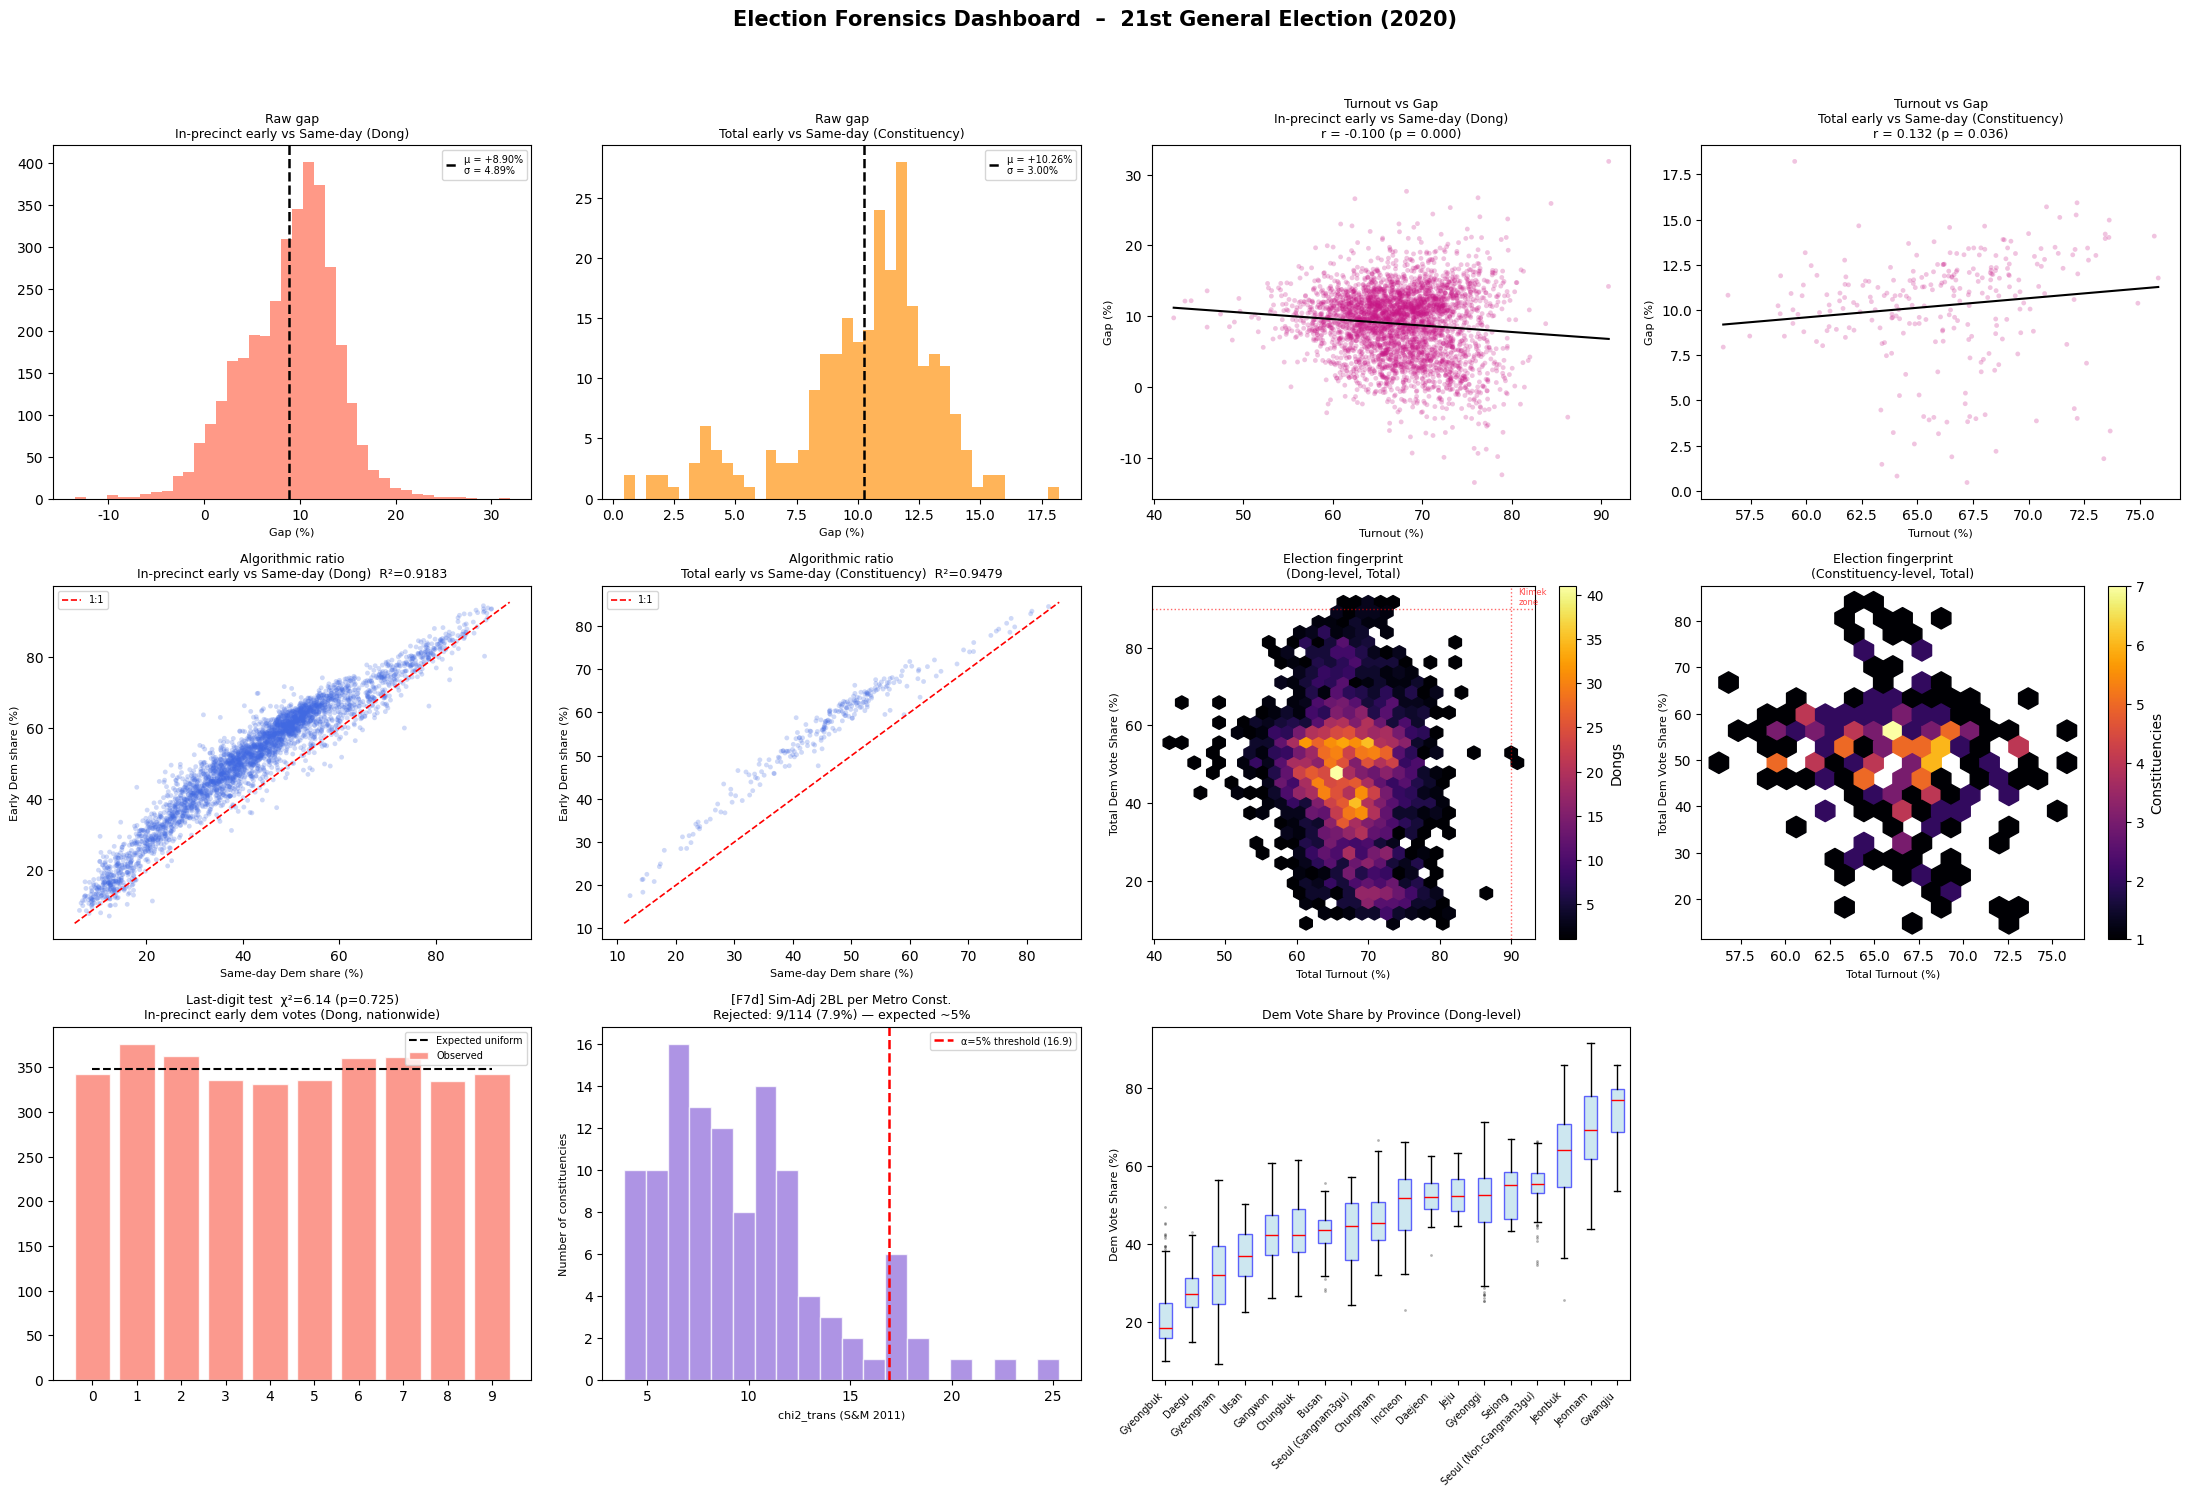

In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.transforms import Bbox
import os
import re
from scipy.stats import chisquare, pearsonr, norm, gaussian_kde, multivariate_t
from sklearn.mixture import GaussianMixture

try:
    import koreanize_matplotlib
except ImportError:
    print("[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib")

# ==========================================
# FONT SETUP
# ==========================================

def setup_font():
    """Configure matplotlib to render text properly."""
    matplotlib.rcParams['axes.unicode_minus'] = False

# ==========================================
# CONFIGURATION
# ==========================================

ELECTION_NUM = 21   # options: 21, 22, 'pres20', 'pres21'
EXCLUDE_HONAM_YEONGNAM = False

ELECTION_CONFIGS = {
    21: {
        'election_type':  'general',
        'result_csv':     '21st_election_result.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'미래통합당|자유한국당',
        'third_pattern':  None,
        'label':          '21st General Election (2020)',
        'year':           2020,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_21st.png',
    },
    22: {
        'election_type':  'general',
        'result_csv':     '22nd_election_result.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'국민의힘',
        'third_pattern':  None,
        'label':          '22nd General Election (2024)',
        'year':           2024,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_22nd.png',
    },
    'pres20': {
        'election_type':         'presidential',
        'result_csv':            '20th_presidential_election_result.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         None,
        'label':                 '20th Presidential Election (2022)',
        'year':                  2022,
        'election_month':        3,
        'dashboard_out':         'mega_forensics_dashboard_pres20.png',
        'fallback_election_num': 21,
    },
    'pres21': {
        'election_type':         'presidential',
        'result_csv':            '21st_presidential_election_result.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         r'이준석|개혁신당',
        'label':                 '21st Presidential Election (2025)',
        'year':                  2025,
        'election_month':        6,
        'dashboard_out':         'mega_forensics_dashboard_pres21.png',
        'fallback_election_num': 22,
    },
}

CFG = ELECTION_CONFIGS[ELECTION_NUM]

SPECIAL_DONG_NAMES_GENERAL = {
    '거소·선상투표', '관외사전투표', '국외부재자투표',
    '국외부재자투표(공관)', '잘못 투입·구분된 투표지',
}
SPECIAL_DONG_NAMES_PRESIDENTIAL = {
    '거소·선상투표', '관외사전투표', '재외투표',
    '잘못 투입·구분된 투표지',
}
GWANNAESA_LABEL = '관내사전투표'
META_CANDIDATES = {'선거인수', '투표수', '무효 투표수', '기권자수'}

PROV_FULL_TO_SHORT = {
    '서울특별시': 'Seoul',  '부산광역시': 'Busan',   '대구광역시': 'Daegu',
    '인천광역시': 'Incheon','광주광역시': 'Gwangju', '대전광역시': 'Daejeon',
    '울산광역시': 'Ulsan',  '세종특별자치시': 'Sejong',
    '경기도': 'Gyeonggi',  '강원도': 'Gangwon',     '강원특별자치도': 'Gangwon',
    '충청북도': 'Chungbuk', '충청남도': 'Chungnam',
    '전라북도': 'Jeonbuk',  '전북특별자치도': 'Jeonbuk', '전라남도': 'Jeonnam',
    '경상북도': 'Gyeongbuk','경상남도': 'Gyeongnam', '제주특별자치도': 'Jeju',
}

PARTISAN_REGION_PROVINCES = {
    'Honam':   {'Jeonnam', 'Jeonbuk', 'Gwangju', '전남', '전북', '광주'},
    'Yeongnam':{'Gyeongbuk', 'Gyeongnam', 'Daegu', 'Busan', 'Ulsan',
                '경북', '경남', '대구', '부산', '울산'},
}

# ==========================================
# SHARED NORMALISATION & IO UTILITIES
# ==========================================

def _read_csv_auto(path: str, **kwargs) -> pd.DataFrame:
    try:
        return pd.read_csv(path, encoding='utf-8', **kwargs)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='cp949', **kwargs)

def normalize_dong_name(name: str) -> str:
    if not isinstance(name, str): return ""
    name = re.sub(r'\(.*?\)', '', name).strip().replace('.', '·')
    name = re.sub(r'제(\d)', r'\1', name)
    name = re.sub(r'·\d+', '', name)
    name = re.sub(r'(\d+)(동|읍|면)$', r'\2', name)
    return re.sub(r'\s+', ' ', name)

def split_admin_tokens(name: str) -> list:
    tokens, buf = [], []
    for ch in name:
        buf.append(ch)
        if ch in '시군구' and len(buf) >= 2:
            tokens.append(''.join(buf))
            buf = []
    if buf: tokens.append(''.join(buf))
    return [t for t in tokens if t]

def normalize_sigungu(name: str) -> list:
    if not isinstance(name, str): return []
    name = re.sub(r'\(.*?\)', '', name).strip()
    if not name: return []
    tokens = split_admin_tokens(name)
    if not tokens:
        stripped = re.sub(r'[시군구갑을병정무]$', '', name).strip()
        return [stripped] if stripped else []
    si_gun_count = sum(1 for t in tokens if t[-1] in '시군' and len(t) >= 2)
    gu_count     = sum(1 for t in tokens if t[-1] == '구'  and len(t) >= 2)
    ordered = tokens if (si_gun_count >= 2 or (si_gun_count == 0 and gu_count >= 2)) else list(reversed(tokens))
    candidates = []
    for t in ordered:
        key = re.sub(r'[시군구]$', '', t).strip()
        if key and key not in candidates: candidates.append(key)
    return candidates


# ==========================================
# 1. ELECTION CSV LOADER
# ==========================================

def load_election_csv(csv_path: str, dem_pattern: str, con_pattern: str,
                      third_pattern: str = None, election_type: str = 'general'):
    print(f"\n--- Loading Election Result Data ({csv_path}, type={election_type}) ---")
    try:
        df = _read_csv_auto(csv_path, low_memory=False)
    except Exception as e:
        print(f"[!] Failed to read election CSV: {e}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    if election_type == 'presidential':
        df = df.rename(columns={'구시군명': '선거구명', '읍면동명': '법정읍면동명'})
        special_dong_names = SPECIAL_DONG_NAMES_PRESIDENTIAL
    else:
        special_dong_names = SPECIAL_DONG_NAMES_GENERAL

    df['득표수']    = pd.to_numeric(df['득표수'], errors='coerce').fillna(0).astype(int)
    df['is_dem']   = df['후보자'].str.contains(dem_pattern,   case=False, na=False)
    df['is_con']   = df['후보자'].str.contains(con_pattern,   case=False, na=False)
    df['is_third'] = df['후보자'].str.contains(third_pattern, case=False, na=False) if third_pattern else False
    df['is_meta']  = df['후보자'].isin(META_CANDIDATES)
    df['is_early'] = df['투표구명'] == GWANNAESA_LABEL

    dong_key  = ['시도명','선거구명','법정읍면동명']
    const_key = ['시도명','선거구명']

    def sgg_cands_from_constituency(name):
        if not isinstance(name, str): return []
        if '_' in name: return normalize_sigungu(name.split('_', 1)[1])
        return normalize_sigungu(re.sub(r'[갑을병정무]$', '', name).strip())

    df_geo   = df[~df['법정읍면동명'].isin(special_dong_names)].copy()
    df_votes = df_geo[~df_geo['is_meta']].copy()

    gn_dem = df_votes[df_votes['is_dem']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot = df_votes[df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    sd_dem = df_votes[df_votes['is_dem']  & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot = df_votes[~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_total')
    gn_th  = df_votes[df_votes['is_third'] & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_third')
    sd_th  = df_votes[df_votes['is_third'] & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_third')

    sum_people_dong = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_people'))
    sum_vote_geo    = (df_geo[df_geo['후보자'] == '투표수']
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_vote_geo'))

    df_dong = gn_dem.copy()
    for frame in (gn_tot, gn_con, gn_th, sd_dem, sd_tot, sd_th,
                  sum_people_dong, sum_vote_geo):
        df_dong = df_dong.merge(frame, on=dong_key, how='outer')
    df_dong = df_dong.fillna(0)

    gn_ppl_dong = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                   .groupby(dong_key)['득표수'].sum().reset_index(name='_gn_ppl'))
    df_dong = df_dong.merge(gn_ppl_dong, on=dong_key, how='left')
    df_dong['sum_people'] = df_dong['sum_people'] + df_dong['_gn_ppl'].fillna(0)
    df_dong.drop(columns=['_gn_ppl'], inplace=True)

    df_dong['sgg_candidates'] = df_dong['선거구명'].apply(sgg_cands_from_constituency)
    df_dong['primary_sgg']    = df_dong['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_dong['dong_norm']      = df_dong['법정읍면동명'].apply(normalize_dong_name)
    df_dong['province_tag']   = df_dong['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_dong['시도명'])
    df_dong['area2_name']     = df_dong['선거구명']
    df_dong['name']           = df_dong['법정읍면동명']

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul = df_dong['province_tag'] == 'Seoul'
    mask_g3 = df_dong['primary_sgg'].isin(['강남', '서초', '송파'])
    df_dong.loc[mask_seoul & mask_g3, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_dong.loc[mask_seoul & ~mask_g3, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    # ── Constituency-level aggregates ──
    gn_dem_c  = df_votes[df_votes['is_dem'] & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot_c  = df_votes[df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con_c  = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    gn_turn_c = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_turnout'))

    # Collect ALL non-precinct absentee voting (Overseas, Shipboard, Missing boxes, Out-of-precinct)
    df_gw   = df[df['법정읍면동명'].isin(special_dong_names)]
    df_gw_v = df_gw[~df_gw['is_meta']]

    go_dem_c  = df_gw_v[df_gw_v['is_dem']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_dem')
    go_tot_c  = df_gw_v.groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_total')
    go_th_c   = df_gw_v[df_gw_v['is_third']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_third')
    go_turn_c = (df_gw[df_gw['후보자'] == '투표수']
                 .groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_turnout'))

    sd_dem_c  = df_votes[df_votes['is_dem'] & ~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot_c  = df_votes[~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_total')
    sd_turn_c = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='same_day_turnout'))

    reg_c = df_dong.groupby(const_key)['sum_people'].sum().reset_index(name='sum_people')
    df_const = reg_c.copy()
    for frame in (gn_dem_c, gn_tot_c, gn_con_c, gn_turn_c,
                  go_dem_c, go_tot_c, go_turn_c, go_th_c,
                  sd_dem_c, sd_tot_c, sd_turn_c):
        df_const = df_const.merge(frame, on=const_key, how='left')
    df_const = df_const.fillna(0)

    df_const['early_total_dem']     = df_const['in_precinct_early_dem']     + df_const['out_precinct_early_dem']
    df_const['early_total_total']   = df_const['in_precinct_early_total']   + df_const['out_precinct_early_total']
    df_const['early_total_turnout'] = df_const['in_precinct_early_turnout'] + df_const['out_precinct_early_turnout']
    df_const['total_turnout']       = df_const['early_total_turnout'] + df_const['same_day_turnout']

    go_ppl_c = (df_gw[df_gw['후보자'] == '선거인수']
                .groupby(const_key)['득표수'].sum().reset_index(name='_go_ppl'))
    df_const = df_const.merge(go_ppl_c, on=const_key, how='left')
    df_const['sum_people'] = df_const['sum_people'] + df_const['_go_ppl'].fillna(0)
    df_const.drop(columns=['_go_ppl'], inplace=True)

    df_const['sgg_candidates'] = df_const['선거구명'].apply(sgg_cands_from_constituency)
    df_const['primary_sgg']    = df_const['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_const['province_tag']   = df_const['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_const['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_c = df_const['province_tag'] == 'Seoul'
    mask_g3_c = df_const['primary_sgg'].isin(['강남', '서초', '송파'])
    df_const.loc[mask_seoul_c & mask_g3_c, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_const.loc[mask_seoul_c & ~mask_g3_c, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    sk = ['시도명','선거구명','법정읍면동명','투표구명']
    st_r = df[df['후보자'] == '선거인수'].groupby(sk)['득표수'].sum().reset_index(name='sum_people')
    st_v = df[df['후보자'] == '투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_vote')
    st_i = df[df['후보자'] == '무효 투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_invalid')
    st_d = df[df['is_dem']].groupby(sk)['득표수'].sum().reset_index(name='dem_votes')
    st_c = df[df['is_con']].groupby(sk)['득표수'].sum().reset_index(name='con_votes')

    df_station = st_r.copy()
    for frame in (st_v, st_i, st_d, st_c):
        df_station = df_station.merge(frame, on=sk, how='outer')
    df_station = df_station.fillna(0)

    df_station['is_early_flag'] = df_station['투표구명'] == GWANNAESA_LABEL
    df_station['province_tag']  = df_station['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_station['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_s = df_station['province_tag'] == 'Seoul'
    mask_g3_s = df_station['선거구명'].apply(lambda x: any(g in str(x) for g in ['강남', '서초', '송파']))
    df_station.loc[mask_seoul_s & mask_g3_s, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_station.loc[mask_seoul_s & ~mask_g3_s, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    df_station['region']        = df_station['province_tag'] + ' ' + df_station['선거구명']
    df_station['invalid_rate']  = df_station['sum_invalid'] / df_station['sum_vote'].replace(0, np.nan)

    return df_dong, df_const, df_station

# ==========================================
# 2. FORENSICS ENGINE
# ==========================================

def categorize_metro(region: str) -> str:
    if not isinstance(region, str): return "Other"
    if 'Incheon' in region or 'Gyeyang' in region or 'Yeonsu' in region: return "Incheon"
    if any(c in region for c in ('Suwon','Goyang','Seongnam','Yongin','Gyeonggi')): return "Gyeonggi"
    if 'Seoul (Gangnam3gu)' in region: return "Seoul (Gangnam3gu)"
    if 'Seoul' in region: return "Seoul (Non-Gangnam3gu)"
    return "Other"

def compute_benford_2bl(vote_series: pd.Series) -> tuple:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2_2bl, p_2bl = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return obs_2bl, exp_2bl, chi2_2bl, p_2bl, n

def compute_benford_2bl_statistic(vote_series: pd.Series) -> float:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    if len(valid) == 0: return np.nan
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2, _ = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return chi2

def simulate_2bl_critical_value(df_constituency: pd.DataFrame,
                                 dem_col:   str = 'in_precinct_early_dem',
                                 con_col:   str = 'in_precinct_early_con',
                                 total_col: str = 'in_precinct_early_total',
                                 n_simulations: int = 500,
                                 df_t:      int = 5) -> dict:
    df_sub = df_constituency[df_constituency[total_col] > 0].copy()
    if len(df_sub) < 5:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    eps = 1e-5
    v_dem   = np.maximum(df_sub[dem_col]   / df_sub[total_col], eps)
    v_con   = np.maximum(df_sub[con_col]   / df_sub[total_col], eps)
    v_other = np.maximum(1.0 - v_dem - v_con, eps)
    denom   = v_dem + v_con + v_other
    v_dem, v_con, v_other = v_dem/denom, v_con/denom, v_other/denom
    y_dem = np.log(v_dem / v_other)
    y_con = np.log(v_con / v_other)
    Y = np.column_stack([y_dem, y_con])
    mu = np.mean(Y, axis=0)
    S  = np.cov(Y, rowvar=False)
    shape_matrix = S * (df_t - 2) / df_t if df_t > 2 else S
    shape_matrix = np.atleast_2d(shape_matrix)
    try:
        rv = multivariate_t(loc=mu, shape=shape_matrix, df=df_t)
    except Exception:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    actual_voters = df_sub[total_col].values
    simulated_chi2_stats = []
    for _ in range(n_simulations):
        Y_sim = rv.rvs(size=len(df_sub))
        if len(df_sub) == 1: Y_sim = Y_sim.reshape(1, -1)
        exp_y_dem = np.exp(Y_sim[:, 0])
        exp_y_con = np.exp(Y_sim[:, 1])
        denom_sim = 1.0 + exp_y_dem + exp_y_con
        v_dem_sim = exp_y_dem / denom_sim
        sim_counts = np.round(v_dem_sim * actual_voters)
        sim_chi2 = compute_benford_2bl_statistic(pd.Series(sim_counts))
        if not np.isnan(sim_chi2): simulated_chi2_stats.append(sim_chi2)
    if not simulated_chi2_stats:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    empirical_chi2 = compute_benford_2bl_statistic(df_sub[dem_col])
    chi2_sim95     = np.percentile(simulated_chi2_stats, 95)
    chi2_trans     = (empirical_chi2 * 16.9 / chi2_sim95) if chi2_sim95 > 0 else np.nan
    return {'empirical_chi2': empirical_chi2, 'chi2_sim95': chi2_sim95, 'chi2_trans': chi2_trans}

def _classify_gmm_cluster(t_center: float, v_center: float,
                           province_tag_series: pd.Series) -> str:
    KLIMEK_TURNOUT_THRESHOLD = 0.90
    KLIMEK_SHARE_THRESHOLD   = 0.90
    joint_extreme = (t_center > KLIMEK_TURNOUT_THRESHOLD and
                     (v_center > KLIMEK_SHARE_THRESHOLD or v_center < (1 - KLIMEK_SHARE_THRESHOLD)))
    if joint_extreme:
        return "Klimek Anomaly — extreme turnout + vote share (fraud signal)"
    if province_tag_series is not None and len(province_tag_series) > 0:
        top_prov = province_tag_series.value_counts().index[0]
        for region_name, region_provs in PARTISAN_REGION_PROVINCES.items():
            if top_prov in region_provs:
                return f"Geographic/Partisan — {region_name} region ({top_prov} dominant)"
    return "Geographic/Partisan — swing or mixed region"


def run_forensics(df_dong_raw: pd.DataFrame, df_const_raw: pd.DataFrame,
                  df_station:  pd.DataFrame) -> dict:
    logs = []
    def log(msg): print(msg); logs.append(msg)

    log(f"\n--- Forensics Suite ---")
    MIN_VOTES = 50

    dm = df_dong_raw.copy()
    dm = dm[(dm['in_precinct_early_total'] > MIN_VOTES) & (dm['same_day_total'] > MIN_VOTES)].copy()
    no_cand = (dm['in_precinct_early_dem'] == 0) & (dm['same_day_dem'] == 0)
    dm = dm[~no_cand].copy()

    # --- PROPORTIONALLY ALLOCATE OUT-OF-PRECINCT VOTES TO DONG LEVEL ---
    const_sums = dm.groupby(['시도명', '선거구명'])[['in_precinct_early_total', 'same_day_total']].transform('sum')
    dm['dong_weight'] = (dm['in_precinct_early_total'] + dm['same_day_total']) / (const_sums['in_precinct_early_total'] + const_sums['same_day_total']).replace(0, np.nan)

    cols_to_merge = ['시도명', '선거구명', 'out_precinct_early_dem', 'out_precinct_early_total', 'out_precinct_early_turnout']
    if 'out_precinct_early_third' in df_const_raw.columns:
        cols_to_merge.append('out_precinct_early_third')

    df_const_sub = df_const_raw[cols_to_merge].drop_duplicates()
    dm = dm.merge(df_const_sub, on=['시도명', '선거구명'], how='left')

    dm['out_precinct_alloc_dem']     = dm['out_precinct_early_dem'].fillna(0) * dm['dong_weight'].fillna(0)
    dm['out_precinct_alloc_tot']     = dm['out_precinct_early_total'].fillna(0) * dm['dong_weight'].fillna(0)
    dm['out_precinct_alloc_turnout'] = dm['out_precinct_early_turnout'].fillna(0) * dm['dong_weight'].fillna(0)

    if 'out_precinct_early_third' in dm.columns:
        dm['out_precinct_alloc_third'] = dm['out_precinct_early_third'].fillna(0) * dm['dong_weight'].fillna(0)

    log("\n  ── Variable Definitions ──")
    log("  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total")
    log("                 The Democratic candidate's vote share among all valid ballots")
    log("                 cast at in-precinct early-voting stations (관내사전투표소).")
    log("  sameday_pct  = same_day_dem ÷ same_day_total")
    log("                 The Democratic share among voters who showed up on election day")
    log("                 (당일투표), the conventional voting mode.")
    log("  gap          = early_pct − sameday_pct")
    log("  vote_share   = (in_precinct_early_dem + same_day_dem + allocated_out_precinct_dem) ÷")
    log("                 (in_precinct_early_total + same_day_total + allocated_out_precinct_total)")
    log("                 Combined Democratic share across all voting modes (Dong level).")
    log("                 Out-of-precinct early votes are proportionally allocated to dongs.")
    log("  turnout      = (sum_vote_geo + allocated_out_precinct_turnout) ÷")
    log("                 (sum_people + allocated_out_precinct_turnout)")
    log("                 Official turnout rate. Out-of-precinct ballots and electors")
    log("                 are proportionally allocated to accurately reflect Dong turnout.")

    dm['early_pct']   = dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
    dm['sameday_pct'] = dm['same_day_dem'] / dm['same_day_total']
    dm['gap']         = dm['early_pct'] - dm['sameday_pct']
    dm['w_gap']       = dm['gap']

    dm['vote_share'] = ((dm['in_precinct_early_dem'] + dm['same_day_dem'] + dm['out_precinct_alloc_dem']) /
                        (dm['in_precinct_early_total'] + dm['same_day_total'] + dm['out_precinct_alloc_tot'])).fillna(0)

    # Corrected Dong-level turnout including absentee ballots and electors
    dm['turnout'] = (dm['sum_vote_geo'] + dm['out_precinct_alloc_turnout']) / \
                    (dm['sum_people'] + dm['out_precinct_alloc_turnout']).replace(0, np.nan)

    # ------------------------------------------------------------------
    # [F1] SECOND-DIGIT BENFORD'S LAW — nationwide naive test
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F1] Second-Digit Benford's Law (2BL) — Nationwide Naive Test")
    log("  NOTE: Uses conventional χ²(9). See [F7d] for simulation-adjusted metro result.")
    log("="*60)
    obs_2bl, exp_2bl, chi2_2bl, p_2bl, n_2bl = compute_benford_2bl(dm['in_precinct_early_dem'])
    log(f"  N (votes >= 10)      : {n_2bl:,}")
    log(f"  Chi-Square Statistic : {chi2_2bl:.4f}")
    log(f"  p-value              : {p_2bl:.4f}  (df=9)")
    log("  Result: " + ("PASS" if p_2bl > 0.05 else "FAIL"))
    log("\n  Observed vs Expected (digits 0–9):")
    for d in range(10):
        log(f"    digit {d}: obs={obs_2bl[d]:5d}  exp={exp_2bl[d]:7.1f}")

    # ------------------------------------------------------------------
    # [F2] LAST-DIGIT UNIFORMITY TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F2] Last-Digit Uniformity Test (Three-Series Comparative)")
    log("="*60)

    def _last_digit_test(series: pd.Series, label: str) -> tuple:
        v  = series.astype(int).astype(str)
        v  = v[v.str.len() >= 2]
        ld = v.str[-1].astype(int)
        n  = len(ld)
        obs = ld.value_counts().reindex(range(10), fill_value=0).sort_index()
        exp = [n / 10.0] * 10
        chi2, p = chisquare(obs.values, f_exp=exp)
        cramer_v = np.sqrt(chi2 / (n * 9)) if n > 0 else np.nan
        log(f"  [{label}]  N={n:,}  χ²={chi2:.2f}  p={p:.4f}  "
            f"Cramér's V={cramer_v:.4f}  {'FAIL ★' if p < 0.05 else 'PASS'}")
        return obs, exp, chi2, p

    obs_ld, exp_ld, chi2_ld, p_ld = _last_digit_test(
        dm['in_precinct_early_dem'], 'in_precinct_early_dem  (early, DEM)')
    obs_ld_con = pd.Series(dtype=int)
    chi2_ld_con, p_ld_con = np.nan, np.nan
    if 'in_precinct_early_con' in dm.columns and dm['in_precinct_early_con'].sum() > 0:
        obs_ld_con, _, chi2_ld_con, p_ld_con = _last_digit_test(
            dm['in_precinct_early_con'], 'in_precinct_early_con  (early, CON)')
    _last_digit_test(dm['same_day_dem'], 'same_day_dem   (sameday, DEM)')

    ld_dem_fails  = p_ld < 0.05
    ld_con_passes = np.isnan(p_ld_con) or p_ld_con >= 0.05
    if ld_dem_fails and ld_con_passes:
        log("  [!] ASYMMETRIC FAILURE: in_precinct_early_dem fails while in_precinct_early_con and")
        log("      same_day_dem pass. This cannot be explained by a counting machine artifact")
        log("      (which would affect all candidates equally). It is candidate-specific.")
    elif ld_dem_fails:
        log("  NOTE: Failure appears in multiple series — likely a structural counting artifact.")

    log(f"\n  Binomial simulation null (using actual in_precinct_early_total & p_dem per dong):")
    gn_tot_col = dm['in_precinct_early_total'].astype(int).values
    p_dem_col  = (dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
                  .replace(0, np.nan)).fillna(0).values
    np.random.seed(42)
    sim_counts = np.array([np.random.binomial(int(N), float(p))
                           for N, p in zip(gn_tot_col, p_dem_col)])
    ld_sim = sim_counts % 10
    obs_sim = np.bincount(ld_sim, minlength=10)
    chi2_sim, p_sim = chisquare(obs_sim, f_exp=[len(ld_sim)/10]*10)
    log(f"  Simulated χ²={chi2_sim:.2f} (p={p_sim:.4f}) vs Actual χ²={chi2_ld:.2f} (p={p_ld:.4f})")
    if p_ld < 0.05 and p_sim >= 0.05:
        log("  The actual deviation exceeds what pure binomial sampling predicts.")

    # ------------------------------------------------------------------
    # [F3] VOTE-SHARE VARIANCE
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F3] Vote-Share Variance (Inter-Neighbourhood Dispersion)")
    log("="*60)
    variances = dm.groupby(['province_tag','primary_sgg'])['vote_share'].std().dropna() * 100
    mean_sd   = variances.mean()
    log(f"  Mean within-city std of dem vote share: {mean_sd:.2f}%")

    # ------------------------------------------------------------------
    # [F4] ALGORITHMIC RATIO CHECK
    # ------------------------------------------------------------------
    corr_a, _ = pearsonr(dm['sameday_pct'], dm['early_pct'])

    # ------------------------------------------------------------------
    # [F5] INVALID VOTE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F5] Invalid Vote Analysis")
    log("="*60)
    valid_st = df_station[df_station['sum_vote'] > 0].copy()
    valid_st['dem_share'] = valid_st['dem_votes'] / valid_st['sum_vote']
    valid_inv = valid_st.dropna(subset=['invalid_rate','dem_share'])
    valid_inv = valid_inv[(valid_inv['invalid_rate'] < 1) & (valid_inv['dem_share'] > 0)]
    if len(valid_inv) >= 10:
        corr_inv, p_inv = pearsonr(valid_inv['invalid_rate'], valid_inv['dem_share'])
        log(f"  N stations        : {len(valid_inv):,}")
        log(f"  Pearson r (invalid rate ↔ dem share): {corr_inv:.4f}  (p={p_inv:.4f})")
        log("  Result: " + (
            "Near-zero — no weaponized invalid ballot signal." if abs(corr_inv) < 0.10
            else f"Non-trivial r={corr_inv:.4f}. Warrants further investigation."))
    else:
        corr_inv, p_inv = np.nan, np.nan
        log("  [!] Insufficient data for invalid vote correlation.")

    # ------------------------------------------------------------------
    # [F6] REGIONAL AGGREGATE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F6] Regional Aggregate Analysis (Metropolitan Two-Party Ratio)")
    log("="*60)
    df_station['metro_zone'] = df_station['region'].apply(categorize_metro)
    valid_tp = df_station[(df_station['dem_votes'] + df_station['con_votes']) > 0].copy()
    valid_tp['two_party_dem'] = valid_tp['dem_votes'] / (valid_tp['dem_votes'] + valid_tp['con_votes'])

    metro_agg = valid_tp.groupby('metro_zone').agg(
        dem_total=('dem_votes','sum'),
        con_total=('con_votes','sum'),
        station_count=('dem_votes','count'),
    ).reset_index()
    metro_agg['dem_ratio'] = metro_agg['dem_total'] / (metro_agg['dem_total'] + metro_agg['con_total'])
    metro_agg['con_ratio'] = 1.0 - metro_agg['dem_ratio']

    for _, row in metro_agg[metro_agg['metro_zone'] != 'Other'].iterrows():
        log(f"    {row['metro_zone']:12s}: {row['dem_ratio']*100:.2f}% vs {row['con_ratio']*100:.2f}%"
            f"  (n={row['station_count']:,} stations)")
    metro_stations = valid_tp[valid_tp['metro_zone'] != 'Other']
    metro_std = metro_stations['two_party_dem'].std() * 100
    log(f"  Micro std of two-party dem share across metro stations: {metro_std:.2f}%")

    # ------------------------------------------------------------------
    # [F7] METRO EARLY-VOTING DIGIT TESTS & 63:37 RATIO HYPOTHESIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F7] Metro Early-Voting Digit Tests & 63:37 Ratio Hypothesis")
    log("  (Seoul / Incheon / Gyeonggi – in-precinct early votes only)")
    log("="*60)

    METRO_PROVINCES = {'Seoul (Non-Gangnam3gu)', 'Seoul (Gangnam3gu)', 'Incheon', 'Gyeonggi'}
    dm_metro = dm[dm['province_tag'].isin(METRO_PROVINCES)].copy()

    obs_2bl_metro  = pd.Series(dtype=int);  exp_2bl_metro  = np.zeros(10)
    chi2_2bl_metro = np.nan;                p_2bl_metro    = np.nan;  n_2bl_metro = 0
    obs_ld_metro   = pd.Series(dtype=int);  exp_ld_metro   = []
    chi2_ld_metro  = np.nan;                p_ld_metro     = np.nan
    metro_early_agg  = pd.DataFrame()
    metro_early_std  = np.nan
    sm_const_results = pd.DataFrame()

    if len(dm_metro) < 10:
        log("  [!] Insufficient metro data.")
    else:
        # F7a – Naive 2BL
        log(f"\n  [F7a] Naive 2BL – Metro in_precinct_early_dem (N={len(dm_metro):,} precincts)")
        log(f"  NOTE: Naive χ²(9) test only. See [F7d] for simulation-adjusted result.")
        obs_2bl_metro, exp_2bl_metro, chi2_2bl_metro, p_2bl_metro, n_2bl_metro = (
            compute_benford_2bl(dm_metro['in_precinct_early_dem']))
        log(f"  N (votes >= 10)      : {n_2bl_metro:,}")
        log(f"  Chi-Square Statistic : {chi2_2bl_metro:.4f}")
        log(f"  p-value              : {p_2bl_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_2bl_metro > 0.05 else "FAIL"))

        votes_metro_sm  = dm_metro['in_precinct_early_dem'][dm_metro['in_precinct_early_dem'] >= 10].values.astype(float)
        votes_nation_sm = dm['in_precinct_early_dem'][dm['in_precinct_early_dem'] >= 10].values.astype(float)
        metro_min_sr    = int(votes_metro_sm.min())  if len(votes_metro_sm)  > 0 else 0
        metro_max_sr    = int(votes_metro_sm.max())  if len(votes_metro_sm)  > 0 else 0
        nation_min_sr   = int(votes_nation_sm.min()) if len(votes_nation_sm) > 0 else 0
        nation_max_sr   = int(votes_nation_sm.max()) if len(votes_nation_sm) > 0 else 0
        metro_orders    = np.log10(metro_max_sr  / metro_min_sr)  if metro_min_sr  > 0 else 0.0
        nation_orders   = np.log10(nation_max_sr / nation_min_sr) if nation_min_sr > 0 else 0.0
        log(f"\n  Scale-Range Comparison (Fewster 2009):")
        log(f"    Nationwide [F1] range : {nation_min_sr:,} – {nation_max_sr:,} ({nation_orders:.2f} orders of magnitude)")
        log(f"    Metro [F7a] range      : {metro_min_sr:,} – {metro_max_sr:,} ({metro_orders:.2f} orders of magnitude)")

        try:
            hist_counts_sm, hist_edges_sm = np.histogram(
                votes_metro_sm, bins=min(50, max(10, len(votes_metro_sm)//10)))
            bin_width_sm = hist_edges_sm[1] - hist_edges_sm[0]
            mode_approx  = float(hist_edges_sm[np.argmax(hist_counts_sm)] + bin_width_sm / 2.0)
            kde_obj      = gaussian_kde(votes_metro_sm)
            kde_x        = np.linspace(votes_metro_sm.min(),
                                       min(float(votes_metro_sm.max()), 2000.0), 1000)
            kde_max      = float(kde_obj(kde_x).max())
        except Exception as e:
            mode_approx, kde_max = np.nan, np.nan
            log(f"  [!] Homogeneity diagnostic error: {e}")

        log(f"\n  Shikano & Mack (2011) Homogeneity Diagnostic:")
        log(f"  NOTE: S&M thresholds calibrated for station-level counts (~50–500 votes).")
        log(f"  This analysis uses Dong-level aggregates (mode ~{mode_approx:.0f} votes).")
        log(f"    Approx. mode of metro vote-count distribution : {mode_approx:.0f} votes")
        log(f"    KDE max density (homogeneity proxy)            : {kde_max:.5f}")
        log(f"    S&M station-level conditions (for reference):")
        log(f"      (1) mode ∈ [80, 190]  → {'YES' if not np.isnan(mode_approx) and 80 <= mode_approx <= 190 else 'NO'}")
        log(f"      (2) KDE max > 0.01    → {'YES' if not np.isnan(kde_max) and kde_max > 0.01 else 'NO'}")
        mode_in_range   = not np.isnan(mode_approx) and (80 <= mode_approx <= 190)
        kde_homogeneous = not np.isnan(kde_max) and (kde_max > 0.01)
        if mode_in_range and kde_homogeneous:
            log(f"  Both S&M station-level conditions met (unexpected at Dong level).")
        else:
            log(f"  Neither S&M station-level condition met (expected at Dong aggregation).")
            log(f"  Simulation-adjusted result [F7d] is the primary forensic indicator.")

        # F7b – Last-digit metro
        log(f"\n  [F7b] Last-Digit – Metro in_precinct_early_dem")
        v_ld_m = dm_metro['in_precinct_early_dem'].astype(int).astype(str)
        v_ld_m = v_ld_m[v_ld_m.str.len() >= 2]
        obs_ld_metro  = v_ld_m.str[-1].astype(int).value_counts().reindex(range(10), fill_value=0).sort_index()
        exp_ld_metro  = [len(v_ld_m) / 10.0] * 10
        chi2_ld_metro, p_ld_metro = chisquare(obs_ld_metro.values, f_exp=exp_ld_metro)
        log(f"  N (votes, len >= 2)  : {len(v_ld_m):,}")
        log(f"  Chi-Square Statistic : {chi2_ld_metro:.4f}")
        log(f"  p-value              : {p_ld_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_ld_metro > 0.05 else "FAIL"))

        # F7c – Early-only two-party ratio
        log(f"\n  [F7c] Early-Only Two-Party Ratio (in-precinct early, 63:37 hypothesis)")
        early_st = df_station[
            df_station['is_early_flag'] &
            (df_station['metro_zone'] != 'Other') &
            ((df_station['dem_votes'] + df_station['con_votes']) > 0)
        ].copy()
        early_st['two_party_dem_early'] = (
            early_st['dem_votes'] / (early_st['dem_votes'] + early_st['con_votes']))
        metro_early_agg = early_st.groupby('metro_zone').agg(
            early_dem_total=('dem_votes','sum'),
            early_con_total=('con_votes','sum'),
            station_count=('dem_votes','count'),
        ).reset_index()
        metro_early_agg['early_dem_ratio'] = (
            metro_early_agg['early_dem_total'] /
            (metro_early_agg['early_dem_total'] + metro_early_agg['early_con_total']))
        metro_early_agg['early_con_ratio'] = 1.0 - metro_early_agg['early_dem_ratio']

        log(f"  Macro early-voting two-party ratios (Dem vs Con):")
        for _, row in metro_early_agg.iterrows():
            log(f"    {row['metro_zone']:22s}: {row['early_dem_ratio']*100:.2f}% vs {row['early_con_ratio']*100:.2f}%"
                f"  (n={row['station_count']:,} early stations)")

        # --- Calculate Total Seoul ---
        seoul_rows = metro_early_agg[metro_early_agg['metro_zone'].str.contains('Seoul', na=False)]
        if not seoul_rows.empty:
            s_dem_tot = seoul_rows['early_dem_total'].sum()
            s_con_tot = seoul_rows['early_con_total'].sum()
            s_n_stat  = seoul_rows['station_count'].sum()
            if s_dem_tot + s_con_tot > 0:
                s_dem_ratio = s_dem_tot / (s_dem_tot + s_con_tot)
                s_con_ratio = 1.0 - s_dem_ratio
                log(f"    {'-'*55}")
                log(f"    {'Seoul (Combined Total)':22s}: {s_dem_ratio*100:.2f}% vs {s_con_ratio*100:.2f}%"
                    f"  (n={s_n_stat:,} early stations)")
        # ----------------------------------

        metro_early_std = early_st['two_party_dem_early'].std() * 100
        log(f"\n  Micro std of early two-party dem share across metro stations: {metro_early_std:.2f}%")
        log(f"  HIGH micro std alongside any macro convergence → LLN, not top-down fixing.")
        log(f"  LOW micro std (<2%) with near-63:37 macro → supports fixed-ratio hypothesis.")

        # F7d – Simulation-adjusted 2BL per metro constituency
        log(f"\n  [F7d] Simulation-Adjusted 2BL Per Metro Constituency (S&M 2011)")
        log(f"  Unit: dongs within each constituency  |  Simulations: 500  |  df_t=5")
        if 'in_precinct_early_con' not in df_dong_raw.columns:
            log("  [!] in_precinct_early_con not found in dong data. Skipping simulation-based test.")
        else:
            metro_dong_raw = df_dong_raw[
                df_dong_raw['province_tag'].isin(METRO_PROVINCES) &
                (df_dong_raw['in_precinct_early_total'] > MIN_VOTES)
            ].copy()
            sm_rows = []
            for (sido, const_name), grp in metro_dong_raw.groupby(['province_tag','선거구명']):
                if len(grp) < 5: continue
                res = simulate_2bl_critical_value(grp, n_simulations=500, df_t=5)
                res['Province']     = sido
                res['Constituency'] = const_name
                res['n_dongs']      = len(grp)
                sm_rows.append(res)
            if sm_rows:
                sm_const_results = pd.DataFrame(sm_rows)
                valid_mask = sm_const_results['chi2_trans'].notna()
                n_valid    = valid_mask.sum()
                n_reject   = (sm_const_results.loc[valid_mask,'chi2_trans'] > 16.9).sum()
                pct_reject = n_reject / n_valid * 100 if n_valid > 0 else 0.0
                log(f"  Metro constituencies analysed    : {len(sm_const_results)}")
                log(f"  With valid simulation results    : {n_valid}")
                log(f"  Exceeding sim-adjusted threshold : {n_reject} ({pct_reject:.1f}%)  (expected ~5%)")
                log("  Result: " + (
                    "PASS — rejection rate within chance expectation." if pct_reject <= 7.5
                    else "FAIL — more rejections than chance predicts. Warrants review."))
                log(f"\n  Top 10 constituencies by chi2_trans:")
                log(f"  {'Province':<22} {'Constituency':<20} {'emp_χ²':>8} {'sim95':>7} {'trans_χ²':>9} {'n_dongs':>7}")
                top_sm = (sm_const_results.dropna(subset=['chi2_trans'])
                          .sort_values('chi2_trans', ascending=False).head(10))
                for _, r in top_sm.iterrows():
                    flag = " ★" if r['chi2_trans'] > 16.9 else ""
                    log(f"  {str(r['Province'])[:22]:<22} {str(r['Constituency']):<20} "
                        f"{r['empirical_chi2']:8.2f} {r['chi2_sim95']:7.2f} "
                        f"{r['chi2_trans']:9.2f}{flag}  (n={int(r['n_dongs'])})")
            else:
                log("  [!] No valid simulation results produced.")

    # ------------------------------------------------------------------
    # [F8] BEBER & SCACCO "0s AND 5s" TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F8] Beber & Scacco '0s and 5s' Test (Human Fabrication Signature)")
    log("="*60)
    v_ld_all    = dm['in_precinct_early_dem'].astype(int).astype(str)
    v_ld_all    = v_ld_all[v_ld_all.str.len() >= 2]
    last_digits = v_ld_all.str[-1].astype(int)
    count_05    = last_digits.isin([0, 5]).sum()
    n_ld        = len(last_digits)
    p_hat_05    = count_05 / n_ld if n_ld > 0 else 0.0
    p_0         = 0.20
    if n_ld > 0:
        se_p      = np.sqrt(p_0 * (1 - p_0) / n_ld)
        z_05      = (p_hat_05 - p_0) / se_p
        p_val_05  = 2 * (1 - norm.cdf(abs(z_05)))
        log(f"  Observed 0s/5s frequency : {p_hat_05*100:.2f}%  (Expected: 20.00%)")
        log(f"  Z-Statistic              : {z_05:.4f}")
        log(f"  p-value                  : {p_val_05:.4e}")
        log("  Result: " + (
            "PASS – No significant human preference for 0s and 5s." if p_val_05 > 0.05
            else "FAIL – Unnatural frequency of 0s and 5s detected."))

    # ------------------------------------------------------------------
    # [F9] BEBER & SCACCO MEAN & VARIANCE OF LAST DIGITS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F9] Beber & Scacco Mean & Variance of Last Digits")
    log("="*60)
    if n_ld > 0:
        mean_ld = last_digits.mean()
        var_ld  = last_digits.var()
        se_mean = np.sqrt(8.25 / n_ld)
        z_mean  = (mean_ld - 4.5) / se_mean
        p_val_mean = 2 * (1 - norm.cdf(abs(z_mean)))
        log(f"  Observed Mean     : {mean_ld:.4f}  (Expected: 4.5)")
        log(f"  Observed Variance : {var_ld:.4f}   (Expected: 8.25)")
        log(f"  Mean Z-Statistic  : {z_mean:.4f}  (p={p_val_mean:.4e})")
        log("  Result: " + (
            "PASS – Last digit mean conforms to uniform distribution." if p_val_mean > 0.05
            else "FAIL – Last digit mean deviates from uniform expectation."))

    # ------------------------------------------------------------------
    # [F10] KLIMEK ET AL. MIXTURE MODELING (Election Fingerprint)
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F10] Klimek et al. Mixture Modeling (Election Fingerprint)")
    log("  NOTE: Fraud signal = HIGH TURNOUT + HIGH VOTE SHARE simultaneously.")
    log("  A cluster extreme only in vote share at normal turnout is geographic.")
    log("="*60)
    fp_data_raw = dm[['turnout','vote_share','province_tag']].dropna()
    fp_data     = fp_data_raw[['turnout','vote_share']].copy()
    if len(fp_data) > 50:
        best_gmm, best_bic, best_n = None, np.inf, 2
        for n_comp in range(2, 7):
            g   = GaussianMixture(n_components=n_comp, random_state=42, n_init=3)
            g.fit(fp_data)
            bic = g.bic(fp_data)
            if bic < best_bic: best_bic, best_gmm, best_n = bic, g, n_comp
        log(f"  BIC-selected n_components: {best_n}  (BIC={best_bic:.1f})")
        labels  = best_gmm.predict(fp_data)
        weights = best_gmm.weights_
        centers = best_gmm.means_
        sorted_indices = np.argsort(weights)[::-1]
        log(f"  Identified Clusters (Turnout %, Dem Vote Share %):")
        klimek_anomaly_found = False
        for i, idx in enumerate(sorted_indices):
            w        = weights[idx] * 100
            t_center = centers[idx][0]
            v_center = centers[idx][1]
            cluster_provs = fp_data_raw.loc[fp_data.index[labels == idx], 'province_tag']
            c_type   = _classify_gmm_cluster(t_center, v_center, cluster_provs)
            if "Anomaly" in c_type: klimek_anomaly_found = True
            log(f"    Cluster {i+1}: Weight={w:.1f}%  "
                f"Turnout={t_center*100:.1f}%  VoteShare={v_center*100:.1f}%")
            log(f"             → {c_type}")
        if klimek_anomaly_found:
            log("  [!] KLIMEK FLAG: At least one cluster meets the fraud criterion.")
        else:
            log("  Result: No cluster meets the Klimek joint fraud criterion.")
            log("          Cluster separation is explained by regional partisanship.")
    else:
        log("  [!] Insufficient data for Klimek GMM modeling.")

    # ------------------------------------------------------------------
    # Constituency-level frame
    # ------------------------------------------------------------------
    cm = df_const_raw.copy()
    cm = cm[(cm['early_total_total'] > MIN_VOTES) & (cm['same_day_total'] > MIN_VOTES)].copy()
    no_cand_c = (cm['early_total_dem'] == 0) & (cm['same_day_dem'] == 0)
    cm = cm[~no_cand_c].copy()

    cm['early_pct']              = cm['early_total_dem']  / cm['early_total_total']
    cm['sameday_pct']            = cm['same_day_dem']     / cm['same_day_total']
    cm['gap']                    = cm['early_pct'] - cm['sameday_pct']
    cm['w_gap']                  = cm['gap']

    # Constituency vote_share natively captures in-precinct + out-precinct in `early_total_dem`
    cm['vote_share']             = ((cm['early_total_dem'] + cm['same_day_dem']) /
                                    (cm['early_total_total'] + cm['same_day_total']))
    cm['turnout']                = cm['total_turnout'] / cm['sum_people'].replace(0, np.nan)

    corr_b, _ = pearsonr(cm['sameday_pct'], cm['early_pct'])

    return {
        'dong': {
            'df': dm,
            'obs_2bl': obs_2bl, 'exp_2bl': exp_2bl, 'chi2_2bl': chi2_2bl, 'p_2bl': p_2bl, 'n_2bl': n_2bl,
            'obs_ld':  obs_ld,  'exp_ld':  exp_ld,  'chi2_ld':  chi2_ld,  'p_ld':  p_ld,
            'variances': variances, 'mean_sd': mean_sd,
            'corr_inv': corr_inv, 'p_inv': p_inv,
            'metro_agg': metro_agg, 'metro_std': metro_std,
            'obs_2bl_metro': obs_2bl_metro, 'exp_2bl_metro': exp_2bl_metro,
            'chi2_2bl_metro': chi2_2bl_metro, 'p_2bl_metro': p_2bl_metro, 'n_2bl_metro': n_2bl_metro,
            'obs_ld_metro': obs_ld_metro, 'exp_ld_metro': exp_ld_metro,
            'chi2_ld_metro': chi2_ld_metro, 'p_ld_metro': p_ld_metro,
            'metro_early_agg': metro_early_agg, 'metro_early_std': metro_early_std,
            'sm_const_results': sm_const_results,
            'r2': corr_a**2,
        },
        'const': {'df': cm, 'r2': corr_b**2},
        'forensics_logs': logs,
    }

# ==========================================
# 3. DASHBOARDS & REPORTS
# ==========================================

def save_all_subplots_from_fig(fig, base_filename, out_dir):
    """Extracts and saves every individual subplot from a composite figure."""
    os.makedirs(out_dir, exist_ok=True)
    # Draw the canvas to compute bounding boxes correctly
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    saved_count = 0
    for i, ax in enumerate(fig.axes):
        # Skip empty axes
        if not ax.axison and not ax.has_data() and not ax.texts and not ax.patches:
            continue

        bbox = ax.get_tightbbox(renderer)
        if bbox is None:
            continue

        extent = bbox.transformed(fig.dpi_scale_trans.inverted())

        # Add padding to ensure titles/ticks are not clipped
        padded_extent = Bbox.from_extents(
            extent.x0 - 0.15,
            extent.y0 - 0.15,
            extent.x1 + 0.15,
            extent.y1 + 0.15
        )

        if padded_extent.width > 0 and padded_extent.height > 0:
            out_name = os.path.join(out_dir, f"{base_filename}_subfig_{saved_count:02d}.png")
            try:
                fig.savefig(out_name, bbox_inches=padded_extent, dpi=200)
                saved_count += 1
            except Exception:
                pass


def _draw_naive_2bl(ax, obs_2bl, exp_2bl, results):
    """Fallback panel: naive nationwide 2BL bar chart."""
    digits = np.arange(10)
    w = 0.4
    chi2_2bl = results['dong']['chi2_2bl']
    p_2bl    = results['dong']['p_2bl']
    ax.bar(digits - w/2, obs_2bl, w, color='mediumpurple', alpha=0.8,
           edgecolor='white', label='Observed')
    ax.bar(digits + w/2, exp_2bl, w, color='slategray',    alpha=0.6,
           edgecolor='white', label='Expected (Benford)')
    ax.set_title(f'2nd-digit Benford (2BL, naive)  χ²={chi2_2bl:.2f} (p={p_2bl:.3f})\n'
                 f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    ax.set_xticks(digits)
    ax.legend(fontsize=7)


def plot_dashboard(results: dict, out_path: str, title: str):
    setup_font()
    print(f"\nGenerating visual dashboard → {out_path}")
    dm       = results['dong']['df']
    cm       = results['const']['df']
    obs_ld   = results['dong']['obs_ld']
    exp_ld   = results['dong']['exp_ld']
    obs_2bl  = results['dong']['obs_2bl']
    exp_2bl  = results['dong']['exp_2bl']
    r2_dong  = results['dong']['r2']
    r2_const = results['const']['r2']
    sm_const_results = results['dong'].get('sm_const_results', pd.DataFrame())

    fig, axes = plt.subplots(3, 4, figsize=(22, 15))
    fig.suptitle(f"Election Forensics Dashboard  –  {title}",
                 fontsize=15, fontweight='bold', y=0.995)

    LEVEL_A = 'In-precinct early vs Same-day (Dong)'
    LEVEL_B = 'Total early vs Same-day (Constituency)'

    def hist_gap(ax, data, label, color):
        data = data.replace([np.inf, -np.inf], np.nan).dropna()
        if len(data) == 0: return
        ax.hist(data * 100, bins=40, color=color, alpha=0.65, edgecolor='none')
        ax.axvline(data.mean() * 100, color='black', lw=1.8, ls='--',
                   label=f'μ = {data.mean()*100:+.2f}%\nσ = {data.std()*100:.2f}%')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Gap (%)', fontsize=8)
        ax.legend(fontsize=7, handlelength=1)

    def scatter_ratio(ax, x, y, r2, label):
        if len(x) == 0 or len(y) == 0: return
        mn = min(x.min(), y.min()) * 100 - 1
        mx = max(x.max(), y.max()) * 100 + 1
        ax.scatter(x * 100, y * 100, alpha=0.25, s=12, color='royalblue', edgecolors='none')
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.2, label='1:1')
        ax.set_title(f'{label}  R²={r2:.4f}', fontsize=9)
        ax.set_xlabel('Same-day Dem share (%)', fontsize=8)
        ax.set_ylabel('Early Dem share (%)', fontsize=8)
        ax.legend(fontsize=7)

    def scatter_turnout_gap(ax, turnout, gap, label):
        valid = pd.DataFrame({'t': turnout, 'g': gap}).replace([np.inf, -np.inf], np.nan).dropna()
        if len(valid) == 0: return
        ax.scatter(valid['t']*100, valid['g']*100, alpha=0.25, s=12, color='mediumvioletred', edgecolors='none')
        if len(valid) > 5:
            z = np.polyfit(valid['t']*100, valid['g']*100, 1)
            p = np.poly1d(z)
            xl = np.linspace(valid['t'].min()*100, valid['t'].max()*100, 100)
            ax.plot(xl, p(xl), 'k-', lw=1.5)
            r, p_val = pearsonr(valid['t'], valid['g'])
            subtitle = f'r = {r:.3f} (p = {p_val:.3f})'
        else:
            subtitle = ''
        ax.set_title(f'{label}\n{subtitle}', fontsize=9)
        ax.set_xlabel('Turnout (%)', fontsize=8)
        ax.set_ylabel('Gap (%)', fontsize=8)

    def boxplot_prov_share(ax, df):
        valid = df.dropna(subset=['province_tag', 'vote_share']).copy()
        if len(valid) == 0:
            ax.axis('off')
            return
        medians = valid.groupby('province_tag')['vote_share'].median().sort_values()
        data = [valid[valid['province_tag'] == p]['vote_share'].values * 100 for p in medians.index]
        ax.boxplot(data, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue', alpha=0.6),
                   medianprops=dict(color='red'),
                   flierprops=dict(marker='o', markerfacecolor='black', markeredgecolor='none', markersize=2, alpha=0.3))
        ax.set_title('Dem Vote Share by Province (Dong-level)', fontsize=9)
        ax.set_xticks(range(1, len(medians) + 1))
        ax.set_xticklabels(medians.index, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Dem Vote Share (%)', fontsize=8)

    # Row 0: Raw gaps and Turnout scatter
    hist_gap(axes[0,0], dm['gap'],  f'Raw gap\n{LEVEL_A}',      'tomato')
    hist_gap(axes[0,1], cm['gap'],  f'Raw gap\n{LEVEL_B}',      'darkorange')
    scatter_turnout_gap(axes[0,2], dm['turnout'], dm['gap'], f'Turnout vs Gap\n{LEVEL_A}')
    scatter_turnout_gap(axes[0,3], cm['turnout'], cm['gap'], f'Turnout vs Gap\n{LEVEL_B}')

    # Row 1: Ratios and Fingerprints
    scatter_ratio(axes[1,0], dm['sameday_pct'], dm['early_pct'], r2_dong,  f'Algorithmic ratio\n{LEVEL_A}')
    scatter_ratio(axes[1,1], cm['sameday_pct'], cm['early_pct'], r2_const, f'Algorithmic ratio\n{LEVEL_B}')

    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = axes[1,2].hexbin(fp['turnout']*100, fp['vote_share']*100,
                           gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=axes[1,2], label='Dongs')
    axes[1,2].set_title(f'Election fingerprint\n(Dong-level, Total)', fontsize=9)
    axes[1,2].set_xlabel('Total Turnout (%)', fontsize=8)
    axes[1,2].set_ylabel('Total Dem Vote Share (%)', fontsize=8)
    axes[1,2].axvline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].axhline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].text(91, 91, 'Klimek\nzone', fontsize=6, color='red', alpha=0.7)

    fpc = cm[(cm['turnout'] > 0) & (cm['turnout'] <= 1.0)]
    hb2 = axes[1,3].hexbin(fpc['turnout']*100, fpc['vote_share']*100,
                            gridsize=18, cmap='inferno', mincnt=1)
    fig.colorbar(hb2, ax=axes[1,3], label='Constituencies')
    axes[1,3].set_title(f'Election fingerprint\n(Constituency-level, Total)', fontsize=9)
    axes[1,3].set_xlabel('Total Turnout (%)', fontsize=8)
    axes[1,3].set_ylabel('Total Dem Vote Share (%)', fontsize=8)

    # Row 2: Forensics checks & Boxplots
    axes[2,0].bar(range(10), obs_ld, color='salmon',   alpha=0.8, edgecolor='white', label='Observed')
    axes[2,0].plot(range(10), exp_ld, 'k--', lw=1.5, label='Expected uniform')
    chi2_ld = results['dong']['chi2_ld']; p_ld = results['dong']['p_ld']
    axes[2,0].set_title(f'Last-digit test  χ²={chi2_ld:.2f} (p={p_ld:.3f})\n'
                        f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    axes[2,0].set_xticks(range(10))
    axes[2,0].legend(fontsize=7)

    ax21 = axes[2,1]
    if not sm_const_results.empty and 'chi2_trans' in sm_const_results.columns:
        trans_vals = sm_const_results['chi2_trans'].dropna()
        if len(trans_vals) > 0:
            ax21.hist(trans_vals, bins=20, color='mediumpurple', alpha=0.75, edgecolor='white')
            ax21.axvline(16.9, color='red', lw=1.8, ls='--', label='α=5% threshold (16.9)')
            n_reject = (trans_vals > 16.9).sum()
            pct_rej  = n_reject / len(trans_vals) * 100
            ax21.set_title(f'[F7d] Sim-Adj 2BL per Metro Const.\n'
                           f'Rejected: {n_reject}/{len(trans_vals)} ({pct_rej:.1f}%) — expected ~5%',
                           fontsize=9)
            ax21.set_xlabel('chi2_trans (S&M 2011)', fontsize=8)
            ax21.set_ylabel('Number of constituencies', fontsize=8)
            ax21.legend(fontsize=7)
        else:
            _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)
    else:
        _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)

    boxplot_prov_share(axes[2,2], dm)
    axes[2,3].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    out_dir = out_path.replace('.png', '_subfigures')
    base_name = os.path.basename(out_path).replace('.png', '')
    save_all_subplots_from_fig(fig, base_name, out_dir)

    plt.savefig(out_path, dpi=200)
    print(f"Saved visual dashboard → '{out_path}'")


def save_individual_plots(results: dict, prefix: str):
    """Saves key diagnostic plots individually for manuscript inclusion."""
    dm = results['dong']['df']
    setup_font()

    fig, ax = plt.subplots(figsize=(6, 4))
    data = dm['gap'].replace([np.inf,-np.inf], np.nan).dropna() * 100
    ax.hist(data, bins=40, color='tomato', alpha=0.65, edgecolor='none')
    ax.axvline(data.mean(), color='black', lw=1.8, ls='--', label=f'μ = {data.mean():+.2f}%')
    ax.set_title('Raw Gap (In-precinct early vs Same-day)')
    ax.set_xlabel('Gap (%)')
    ax.legend()
    fig.savefig(f"{prefix}_fig1_gap_hist.png", dpi=200, bbox_inches='tight')
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6, 4))
    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = ax.hexbin(fp['turnout']*100, fp['vote_share']*100, gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=ax, label='Dongs')
    ax.set_title('Election Fingerprint')
    ax.set_xlabel('Turnout (%)')
    ax.set_ylabel('Dem Vote Share (%)')
    fig.savefig(f"{prefix}_fig2_fingerprint.png", dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved individual plots to {prefix}_fig*.png")


def save_text_report(results: dict, out_path: str, title: str):
    print(f"Saving text report → {out_path}")
    lines = [
        f"{'='*70}",
        f"  ELECTION FORENSICS REPORT: {title}",
        f"{'='*70}", "",
        "[ SECTION 1: FORENSICS SUITE  (F1–F10) ]", "",
    ]
    lines.extend(results['forensics_logs'])
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))
    print(f"Saved text report → '{out_path}'")

# ==========================================
# 4. EXECUTION
# ==========================================

if __name__ == "__main__":
    print(f"\n{'='*60}")
    print(f"  Korean Election Forensics — {CFG['label']}")
    print(f"{'='*60}")

    election_type = CFG.get('election_type', 'general')

    df_dong, df_const, df_station = load_election_csv(
        CFG['result_csv'],
        dem_pattern=CFG['dem_pattern'],
        con_pattern=CFG['con_pattern'],
        third_pattern=CFG.get('third_pattern'),
        election_type=election_type,
    )

    if EXCLUDE_HONAM_YEONGNAM:
        exclude_provs = PARTISAN_REGION_PROVINCES['Honam'] | PARTISAN_REGION_PROVINCES['Yeongnam']
        short_exclude = set()
        for p in exclude_provs:
            short_exclude.add(PROV_FULL_TO_SHORT.get(p, p))
            short_exclude.add(p)
        df_dong    = df_dong[~df_dong['province_tag'].isin(short_exclude)]
        df_const   = df_const[~df_const['province_tag'].isin(short_exclude)]
        df_station = df_station[~df_station['province_tag'].isin(short_exclude)]
        print(f"\n[!] EXCLUDE_HONAM_YEONGNAM=True — Honam/Yeongnam filtered out.")

    if not df_dong.empty and not df_const.empty:
        results = run_forensics(df_dong, df_const, df_station)

        plot_dashboard(results, out_path=CFG['dashboard_out'], title=CFG['label'])

        save_individual_plots(results,
                              prefix=CFG['label'].replace(" ", "_").lower()[:10])

        text_report_out = CFG['dashboard_out'].replace('.png', '_report.txt')
        save_text_report(results, out_path=text_report_out, title=CFG['label'])

    else:
        print("[!] Election data could not be loaded. Aborting.")

[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib

  Korean Election Forensics — 20th Presidential Election (2022)

--- Loading Election Result Data (20th_presidential_election_result.csv, type=presidential) ---

--- Forensics Suite ---

  ── Variable Definitions ──
  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total
                 The Democratic candidate's vote share among all valid ballots
                 cast at in-precinct early-voting stations (관내사전투표소).
  sameday_pct  = same_day_dem ÷ same_day_total
                 The Democratic share among voters who showed up on election day
                 (당일투표), the conventional voting mode.
  gap          = early_pct − sameday_pct
  vote_share   = (in_precinct_early_dem + same_day_dem + allocated_out_precinct_dem) ÷
                 (in_precinct_early_total + same_day_total + allocated_out_precinct_total)
                 Combined Democratic share across all voting modes (Dong level).
            

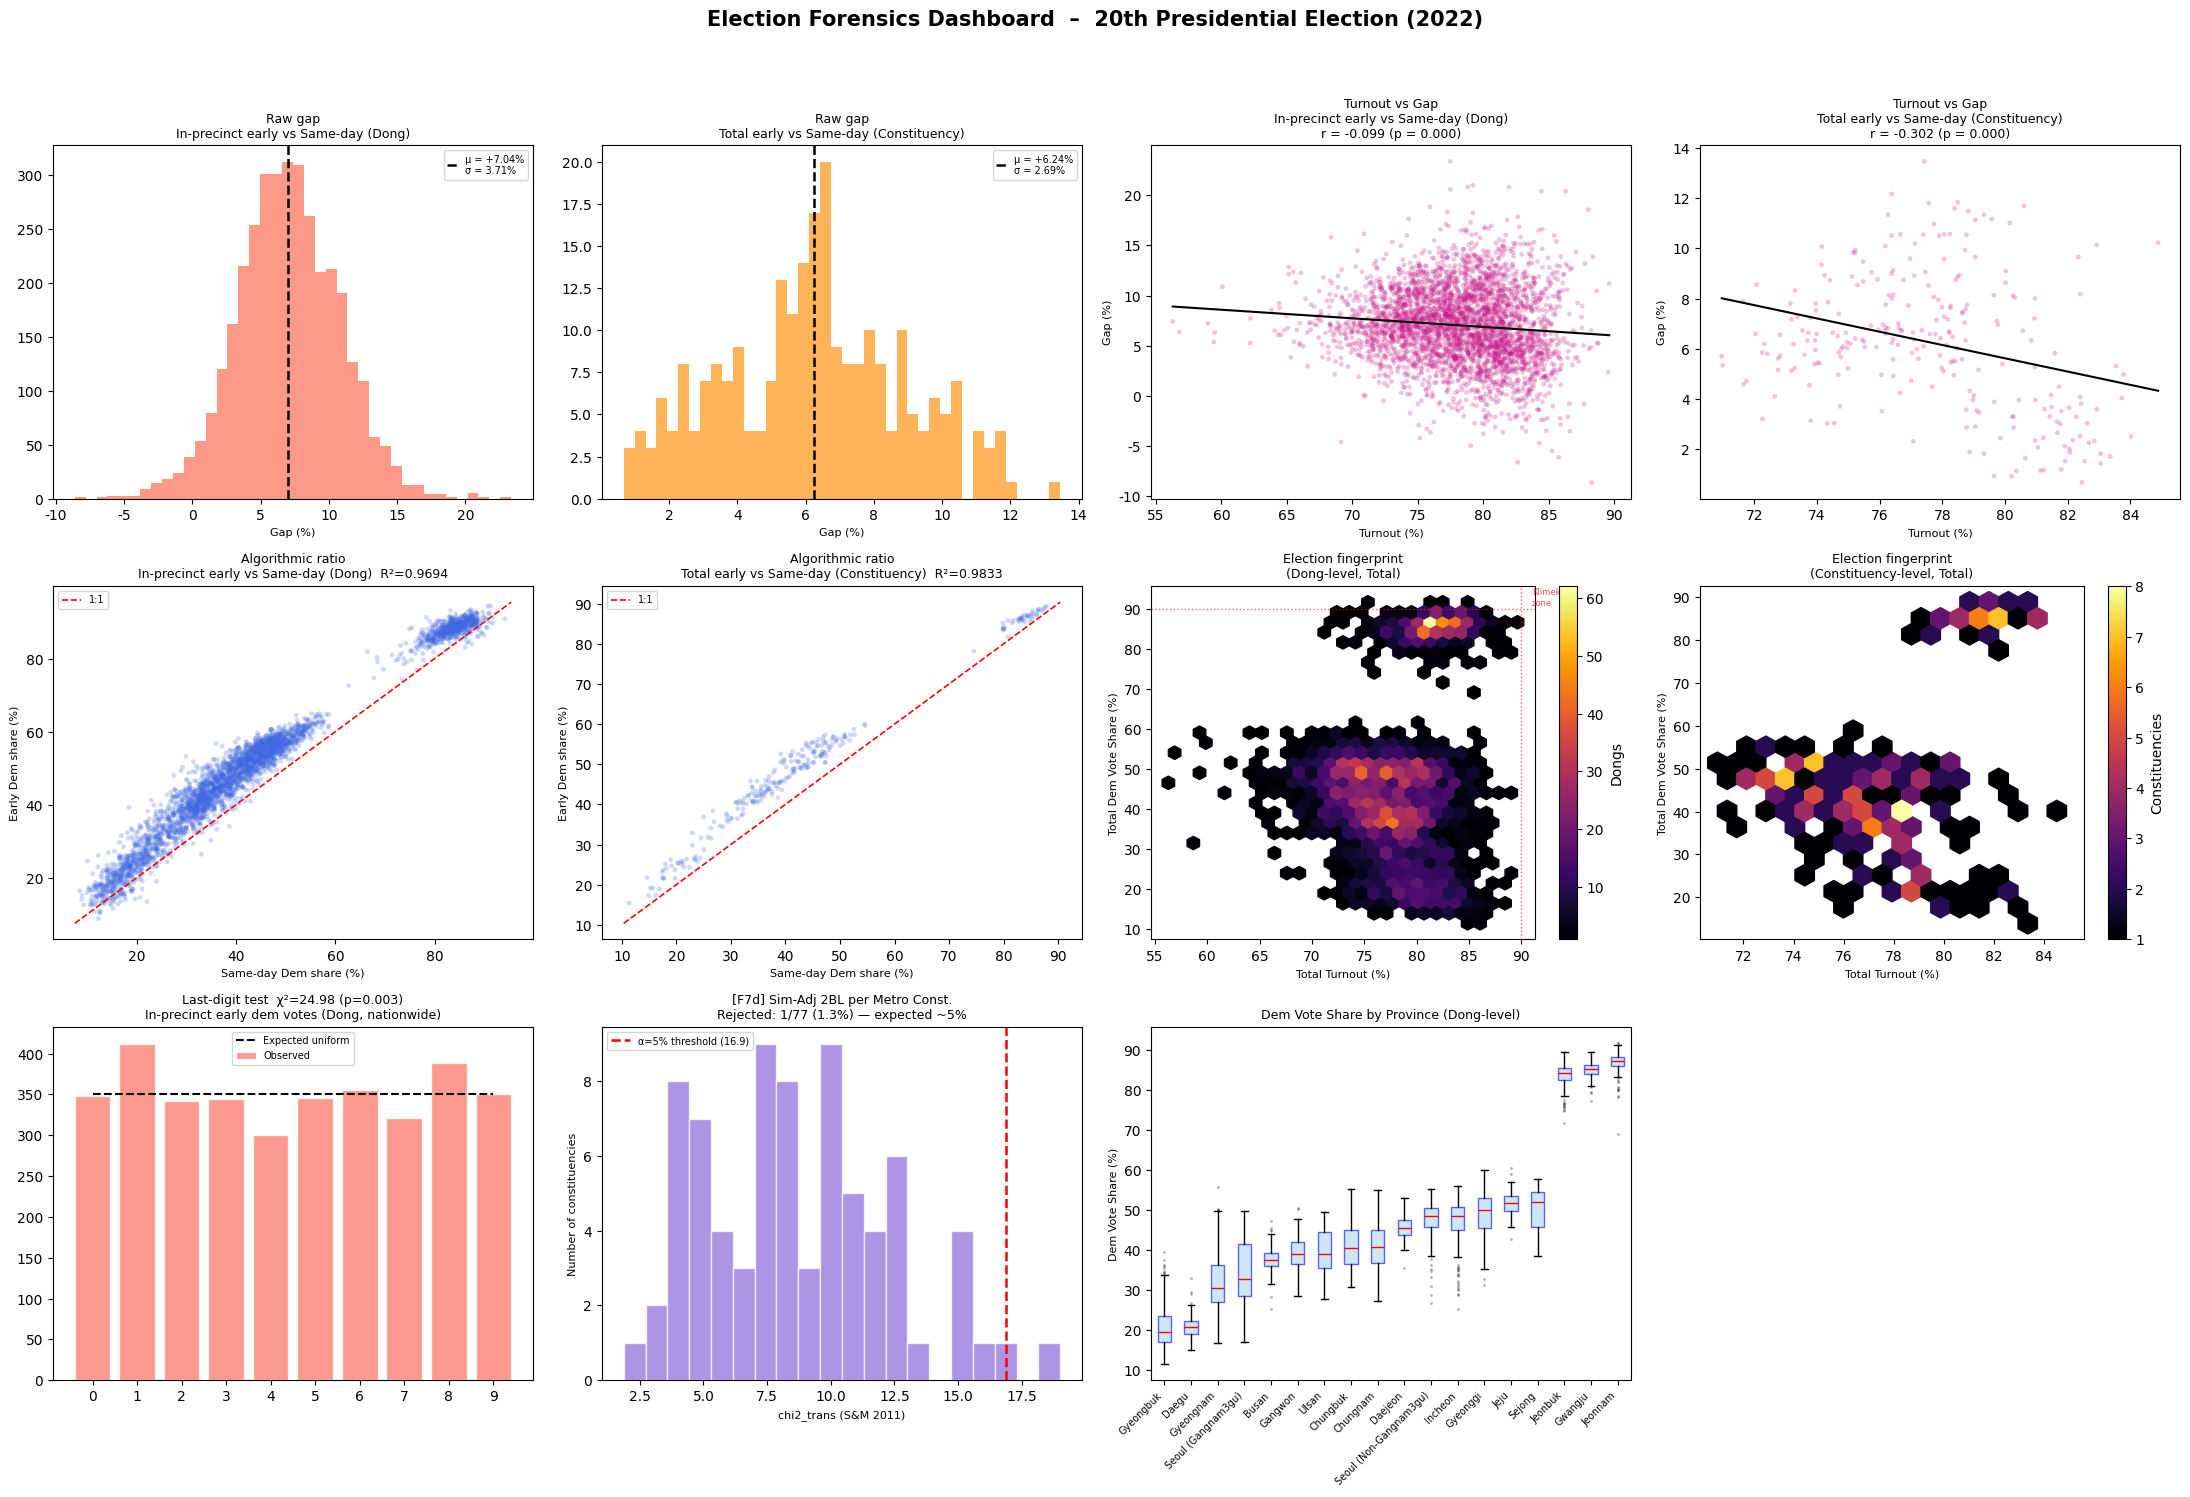

In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.transforms import Bbox
import os
import re
from scipy.stats import chisquare, pearsonr, norm, gaussian_kde, multivariate_t
from sklearn.mixture import GaussianMixture

try:
    import koreanize_matplotlib
except ImportError:
    print("[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib")

# ==========================================
# FONT SETUP
# ==========================================

def setup_font():
    """Configure matplotlib to render text properly."""
    matplotlib.rcParams['axes.unicode_minus'] = False

# ==========================================
# CONFIGURATION
# ==========================================

ELECTION_NUM = 'pres20'   # options: 21, 22, 'pres20', 'pres21'
EXCLUDE_HONAM_YEONGNAM = False

ELECTION_CONFIGS = {
    21: {
        'election_type':  'general',
        'result_csv':     '21st_election_result.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'미래통합당|자유한국당',
        'third_pattern':  None,
        'label':          '21st General Election (2020)',
        'year':           2020,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_21st.png',
    },
    22: {
        'election_type':  'general',
        'result_csv':     '22nd_election_result.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'국민의힘',
        'third_pattern':  None,
        'label':          '22nd General Election (2024)',
        'year':           2024,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_22nd.png',
    },
    'pres20': {
        'election_type':         'presidential',
        'result_csv':            '20th_presidential_election_result.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         None,
        'label':                 '20th Presidential Election (2022)',
        'year':                  2022,
        'election_month':        3,
        'dashboard_out':         'mega_forensics_dashboard_pres20.png',
        'fallback_election_num': 21,
    },
    'pres21': {
        'election_type':         'presidential',
        'result_csv':            '21st_presidential_election_result.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         r'이준석|개혁신당',
        'label':                 '21st Presidential Election (2025)',
        'year':                  2025,
        'election_month':        6,
        'dashboard_out':         'mega_forensics_dashboard_pres21.png',
        'fallback_election_num': 22,
    },
}

CFG = ELECTION_CONFIGS[ELECTION_NUM]

SPECIAL_DONG_NAMES_GENERAL = {
    '거소·선상투표', '관외사전투표', '국외부재자투표',
    '국외부재자투표(공관)', '잘못 투입·구분된 투표지',
}
SPECIAL_DONG_NAMES_PRESIDENTIAL = {
    '거소·선상투표', '관외사전투표', '재외투표',
    '잘못 투입·구분된 투표지',
}
GWANNAESA_LABEL = '관내사전투표'
META_CANDIDATES = {'선거인수', '투표수', '무효 투표수', '기권자수'}

PROV_FULL_TO_SHORT = {
    '서울특별시': 'Seoul',  '부산광역시': 'Busan',   '대구광역시': 'Daegu',
    '인천광역시': 'Incheon','광주광역시': 'Gwangju', '대전광역시': 'Daejeon',
    '울산광역시': 'Ulsan',  '세종특별자치시': 'Sejong',
    '경기도': 'Gyeonggi',  '강원도': 'Gangwon',     '강원특별자치도': 'Gangwon',
    '충청북도': 'Chungbuk', '충청남도': 'Chungnam',
    '전라북도': 'Jeonbuk',  '전북특별자치도': 'Jeonbuk', '전라남도': 'Jeonnam',
    '경상북도': 'Gyeongbuk','경상남도': 'Gyeongnam', '제주특별자치도': 'Jeju',
}

PARTISAN_REGION_PROVINCES = {
    'Honam':   {'Jeonnam', 'Jeonbuk', 'Gwangju', '전남', '전북', '광주'},
    'Yeongnam':{'Gyeongbuk', 'Gyeongnam', 'Daegu', 'Busan', 'Ulsan',
                '경북', '경남', '대구', '부산', '울산'},
}

# ==========================================
# SHARED NORMALISATION & IO UTILITIES
# ==========================================

def _read_csv_auto(path: str, **kwargs) -> pd.DataFrame:
    try:
        return pd.read_csv(path, encoding='utf-8', **kwargs)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='cp949', **kwargs)

def normalize_dong_name(name: str) -> str:
    if not isinstance(name, str): return ""
    name = re.sub(r'\(.*?\)', '', name).strip().replace('.', '·')
    name = re.sub(r'제(\d)', r'\1', name)
    name = re.sub(r'·\d+', '', name)
    name = re.sub(r'(\d+)(동|읍|면)$', r'\2', name)
    return re.sub(r'\s+', ' ', name)

def split_admin_tokens(name: str) -> list:
    tokens, buf = [], []
    for ch in name:
        buf.append(ch)
        if ch in '시군구' and len(buf) >= 2:
            tokens.append(''.join(buf))
            buf = []
    if buf: tokens.append(''.join(buf))
    return [t for t in tokens if t]

def normalize_sigungu(name: str) -> list:
    if not isinstance(name, str): return []
    name = re.sub(r'\(.*?\)', '', name).strip()
    if not name: return []
    tokens = split_admin_tokens(name)
    if not tokens:
        stripped = re.sub(r'[시군구갑을병정무]$', '', name).strip()
        return [stripped] if stripped else []
    si_gun_count = sum(1 for t in tokens if t[-1] in '시군' and len(t) >= 2)
    gu_count     = sum(1 for t in tokens if t[-1] == '구'  and len(t) >= 2)
    ordered = tokens if (si_gun_count >= 2 or (si_gun_count == 0 and gu_count >= 2)) else list(reversed(tokens))
    candidates = []
    for t in ordered:
        key = re.sub(r'[시군구]$', '', t).strip()
        if key and key not in candidates: candidates.append(key)
    return candidates


# ==========================================
# 1. ELECTION CSV LOADER
# ==========================================

def load_election_csv(csv_path: str, dem_pattern: str, con_pattern: str,
                      third_pattern: str = None, election_type: str = 'general'):
    print(f"\n--- Loading Election Result Data ({csv_path}, type={election_type}) ---")
    try:
        df = _read_csv_auto(csv_path, low_memory=False)
    except Exception as e:
        print(f"[!] Failed to read election CSV: {e}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    if election_type == 'presidential':
        df = df.rename(columns={'구시군명': '선거구명', '읍면동명': '법정읍면동명'})
        special_dong_names = SPECIAL_DONG_NAMES_PRESIDENTIAL
    else:
        special_dong_names = SPECIAL_DONG_NAMES_GENERAL

    df['득표수']    = pd.to_numeric(df['득표수'], errors='coerce').fillna(0).astype(int)
    df['is_dem']   = df['후보자'].str.contains(dem_pattern,   case=False, na=False)
    df['is_con']   = df['후보자'].str.contains(con_pattern,   case=False, na=False)
    df['is_third'] = df['후보자'].str.contains(third_pattern, case=False, na=False) if third_pattern else False
    df['is_meta']  = df['후보자'].isin(META_CANDIDATES)
    df['is_early'] = df['투표구명'] == GWANNAESA_LABEL

    dong_key  = ['시도명','선거구명','법정읍면동명']
    const_key = ['시도명','선거구명']

    def sgg_cands_from_constituency(name):
        if not isinstance(name, str): return []
        if '_' in name: return normalize_sigungu(name.split('_', 1)[1])
        return normalize_sigungu(re.sub(r'[갑을병정무]$', '', name).strip())

    df_geo   = df[~df['법정읍면동명'].isin(special_dong_names)].copy()
    df_votes = df_geo[~df_geo['is_meta']].copy()

    gn_dem = df_votes[df_votes['is_dem']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot = df_votes[df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    sd_dem = df_votes[df_votes['is_dem']  & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot = df_votes[~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_total')
    gn_th  = df_votes[df_votes['is_third'] & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_third')
    sd_th  = df_votes[df_votes['is_third'] & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_third')

    sum_people_dong = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_people'))
    sum_vote_geo    = (df_geo[df_geo['후보자'] == '투표수']
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_vote_geo'))

    df_dong = gn_dem.copy()
    for frame in (gn_tot, gn_con, gn_th, sd_dem, sd_tot, sd_th,
                  sum_people_dong, sum_vote_geo):
        df_dong = df_dong.merge(frame, on=dong_key, how='outer')
    df_dong = df_dong.fillna(0)

    gn_ppl_dong = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                   .groupby(dong_key)['득표수'].sum().reset_index(name='_gn_ppl'))
    df_dong = df_dong.merge(gn_ppl_dong, on=dong_key, how='left')
    df_dong['sum_people'] = df_dong['sum_people'] + df_dong['_gn_ppl'].fillna(0)
    df_dong.drop(columns=['_gn_ppl'], inplace=True)

    df_dong['sgg_candidates'] = df_dong['선거구명'].apply(sgg_cands_from_constituency)
    df_dong['primary_sgg']    = df_dong['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_dong['dong_norm']      = df_dong['법정읍면동명'].apply(normalize_dong_name)
    df_dong['province_tag']   = df_dong['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_dong['시도명'])
    df_dong['area2_name']     = df_dong['선거구명']
    df_dong['name']           = df_dong['법정읍면동명']

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul = df_dong['province_tag'] == 'Seoul'
    mask_g3 = df_dong['primary_sgg'].isin(['강남', '서초', '송파'])
    df_dong.loc[mask_seoul & mask_g3, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_dong.loc[mask_seoul & ~mask_g3, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    # ── Constituency-level aggregates ──
    gn_dem_c  = df_votes[df_votes['is_dem'] & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot_c  = df_votes[df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con_c  = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    gn_turn_c = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_turnout'))

    # Collect ALL non-precinct absentee voting (Overseas, Shipboard, Missing boxes, Out-of-precinct)
    df_gw   = df[df['법정읍면동명'].isin(special_dong_names)]
    df_gw_v = df_gw[~df_gw['is_meta']]

    go_dem_c  = df_gw_v[df_gw_v['is_dem']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_dem')
    go_tot_c  = df_gw_v.groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_total')
    go_th_c   = df_gw_v[df_gw_v['is_third']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_third')
    go_turn_c = (df_gw[df_gw['후보자'] == '투표수']
                 .groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_turnout'))

    sd_dem_c  = df_votes[df_votes['is_dem'] & ~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot_c  = df_votes[~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_total')
    sd_turn_c = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='same_day_turnout'))

    reg_c = df_dong.groupby(const_key)['sum_people'].sum().reset_index(name='sum_people')
    df_const = reg_c.copy()
    for frame in (gn_dem_c, gn_tot_c, gn_con_c, gn_turn_c,
                  go_dem_c, go_tot_c, go_turn_c, go_th_c,
                  sd_dem_c, sd_tot_c, sd_turn_c):
        df_const = df_const.merge(frame, on=const_key, how='left')
    df_const = df_const.fillna(0)

    df_const['early_total_dem']     = df_const['in_precinct_early_dem']     + df_const['out_precinct_early_dem']
    df_const['early_total_total']   = df_const['in_precinct_early_total']   + df_const['out_precinct_early_total']
    df_const['early_total_turnout'] = df_const['in_precinct_early_turnout'] + df_const['out_precinct_early_turnout']
    df_const['total_turnout']       = df_const['early_total_turnout'] + df_const['same_day_turnout']

    go_ppl_c = (df_gw[df_gw['후보자'] == '선거인수']
                .groupby(const_key)['득표수'].sum().reset_index(name='_go_ppl'))
    df_const = df_const.merge(go_ppl_c, on=const_key, how='left')
    df_const['sum_people'] = df_const['sum_people'] + df_const['_go_ppl'].fillna(0)
    df_const.drop(columns=['_go_ppl'], inplace=True)

    df_const['sgg_candidates'] = df_const['선거구명'].apply(sgg_cands_from_constituency)
    df_const['primary_sgg']    = df_const['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_const['province_tag']   = df_const['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_const['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_c = df_const['province_tag'] == 'Seoul'
    mask_g3_c = df_const['primary_sgg'].isin(['강남', '서초', '송파'])
    df_const.loc[mask_seoul_c & mask_g3_c, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_const.loc[mask_seoul_c & ~mask_g3_c, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    sk = ['시도명','선거구명','법정읍면동명','투표구명']
    st_r = df[df['후보자'] == '선거인수'].groupby(sk)['득표수'].sum().reset_index(name='sum_people')
    st_v = df[df['후보자'] == '투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_vote')
    st_i = df[df['후보자'] == '무효 투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_invalid')
    st_d = df[df['is_dem']].groupby(sk)['득표수'].sum().reset_index(name='dem_votes')
    st_c = df[df['is_con']].groupby(sk)['득표수'].sum().reset_index(name='con_votes')

    df_station = st_r.copy()
    for frame in (st_v, st_i, st_d, st_c):
        df_station = df_station.merge(frame, on=sk, how='outer')
    df_station = df_station.fillna(0)

    df_station['is_early_flag'] = df_station['투표구명'] == GWANNAESA_LABEL
    df_station['province_tag']  = df_station['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_station['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_s = df_station['province_tag'] == 'Seoul'
    mask_g3_s = df_station['선거구명'].apply(lambda x: any(g in str(x) for g in ['강남', '서초', '송파']))
    df_station.loc[mask_seoul_s & mask_g3_s, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_station.loc[mask_seoul_s & ~mask_g3_s, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    df_station['region']        = df_station['province_tag'] + ' ' + df_station['선거구명']
    df_station['invalid_rate']  = df_station['sum_invalid'] / df_station['sum_vote'].replace(0, np.nan)

    return df_dong, df_const, df_station

# ==========================================
# 2. FORENSICS ENGINE
# ==========================================

def categorize_metro(region: str) -> str:
    if not isinstance(region, str): return "Other"
    if 'Incheon' in region or 'Gyeyang' in region or 'Yeonsu' in region: return "Incheon"
    if any(c in region for c in ('Suwon','Goyang','Seongnam','Yongin','Gyeonggi')): return "Gyeonggi"
    if 'Seoul (Gangnam3gu)' in region: return "Seoul (Gangnam3gu)"
    if 'Seoul' in region: return "Seoul (Non-Gangnam3gu)"
    return "Other"

def compute_benford_2bl(vote_series: pd.Series) -> tuple:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2_2bl, p_2bl = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return obs_2bl, exp_2bl, chi2_2bl, p_2bl, n

def compute_benford_2bl_statistic(vote_series: pd.Series) -> float:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    if len(valid) == 0: return np.nan
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2, _ = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return chi2

def simulate_2bl_critical_value(df_constituency: pd.DataFrame,
                                 dem_col:   str = 'in_precinct_early_dem',
                                 con_col:   str = 'in_precinct_early_con',
                                 total_col: str = 'in_precinct_early_total',
                                 n_simulations: int = 500,
                                 df_t:      int = 5) -> dict:
    df_sub = df_constituency[df_constituency[total_col] > 0].copy()
    if len(df_sub) < 5:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    eps = 1e-5
    v_dem   = np.maximum(df_sub[dem_col]   / df_sub[total_col], eps)
    v_con   = np.maximum(df_sub[con_col]   / df_sub[total_col], eps)
    v_other = np.maximum(1.0 - v_dem - v_con, eps)
    denom   = v_dem + v_con + v_other
    v_dem, v_con, v_other = v_dem/denom, v_con/denom, v_other/denom
    y_dem = np.log(v_dem / v_other)
    y_con = np.log(v_con / v_other)
    Y = np.column_stack([y_dem, y_con])
    mu = np.mean(Y, axis=0)
    S  = np.cov(Y, rowvar=False)
    shape_matrix = S * (df_t - 2) / df_t if df_t > 2 else S
    shape_matrix = np.atleast_2d(shape_matrix)
    try:
        rv = multivariate_t(loc=mu, shape=shape_matrix, df=df_t)
    except Exception:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    actual_voters = df_sub[total_col].values
    simulated_chi2_stats = []
    for _ in range(n_simulations):
        Y_sim = rv.rvs(size=len(df_sub))
        if len(df_sub) == 1: Y_sim = Y_sim.reshape(1, -1)
        exp_y_dem = np.exp(Y_sim[:, 0])
        exp_y_con = np.exp(Y_sim[:, 1])
        denom_sim = 1.0 + exp_y_dem + exp_y_con
        v_dem_sim = exp_y_dem / denom_sim
        sim_counts = np.round(v_dem_sim * actual_voters)
        sim_chi2 = compute_benford_2bl_statistic(pd.Series(sim_counts))
        if not np.isnan(sim_chi2): simulated_chi2_stats.append(sim_chi2)
    if not simulated_chi2_stats:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    empirical_chi2 = compute_benford_2bl_statistic(df_sub[dem_col])
    chi2_sim95     = np.percentile(simulated_chi2_stats, 95)
    chi2_trans     = (empirical_chi2 * 16.9 / chi2_sim95) if chi2_sim95 > 0 else np.nan
    return {'empirical_chi2': empirical_chi2, 'chi2_sim95': chi2_sim95, 'chi2_trans': chi2_trans}

def _classify_gmm_cluster(t_center: float, v_center: float,
                           province_tag_series: pd.Series) -> str:
    KLIMEK_TURNOUT_THRESHOLD = 0.90
    KLIMEK_SHARE_THRESHOLD   = 0.90
    joint_extreme = (t_center > KLIMEK_TURNOUT_THRESHOLD and
                     (v_center > KLIMEK_SHARE_THRESHOLD or v_center < (1 - KLIMEK_SHARE_THRESHOLD)))
    if joint_extreme:
        return "Klimek Anomaly — extreme turnout + vote share (fraud signal)"
    if province_tag_series is not None and len(province_tag_series) > 0:
        top_prov = province_tag_series.value_counts().index[0]
        for region_name, region_provs in PARTISAN_REGION_PROVINCES.items():
            if top_prov in region_provs:
                return f"Geographic/Partisan — {region_name} region ({top_prov} dominant)"
    return "Geographic/Partisan — swing or mixed region"


def run_forensics(df_dong_raw: pd.DataFrame, df_const_raw: pd.DataFrame,
                  df_station:  pd.DataFrame) -> dict:
    logs = []
    def log(msg): print(msg); logs.append(msg)

    log(f"\n--- Forensics Suite ---")
    MIN_VOTES = 50

    dm = df_dong_raw.copy()
    dm = dm[(dm['in_precinct_early_total'] > MIN_VOTES) & (dm['same_day_total'] > MIN_VOTES)].copy()
    no_cand = (dm['in_precinct_early_dem'] == 0) & (dm['same_day_dem'] == 0)
    dm = dm[~no_cand].copy()

    # --- PROPORTIONALLY ALLOCATE OUT-OF-PRECINCT VOTES TO DONG LEVEL ---
    const_sums = dm.groupby(['시도명', '선거구명'])[['in_precinct_early_total', 'same_day_total']].transform('sum')
    dm['dong_weight'] = (dm['in_precinct_early_total'] + dm['same_day_total']) / (const_sums['in_precinct_early_total'] + const_sums['same_day_total']).replace(0, np.nan)

    cols_to_merge = ['시도명', '선거구명', 'out_precinct_early_dem', 'out_precinct_early_total', 'out_precinct_early_turnout']
    if 'out_precinct_early_third' in df_const_raw.columns:
        cols_to_merge.append('out_precinct_early_third')

    df_const_sub = df_const_raw[cols_to_merge].drop_duplicates()
    dm = dm.merge(df_const_sub, on=['시도명', '선거구명'], how='left')

    dm['out_precinct_alloc_dem']     = dm['out_precinct_early_dem'].fillna(0) * dm['dong_weight'].fillna(0)
    dm['out_precinct_alloc_tot']     = dm['out_precinct_early_total'].fillna(0) * dm['dong_weight'].fillna(0)
    dm['out_precinct_alloc_turnout'] = dm['out_precinct_early_turnout'].fillna(0) * dm['dong_weight'].fillna(0)

    if 'out_precinct_early_third' in dm.columns:
        dm['out_precinct_alloc_third'] = dm['out_precinct_early_third'].fillna(0) * dm['dong_weight'].fillna(0)

    log("\n  ── Variable Definitions ──")
    log("  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total")
    log("                 The Democratic candidate's vote share among all valid ballots")
    log("                 cast at in-precinct early-voting stations (관내사전투표소).")
    log("  sameday_pct  = same_day_dem ÷ same_day_total")
    log("                 The Democratic share among voters who showed up on election day")
    log("                 (당일투표), the conventional voting mode.")
    log("  gap          = early_pct − sameday_pct")
    log("  vote_share   = (in_precinct_early_dem + same_day_dem + allocated_out_precinct_dem) ÷")
    log("                 (in_precinct_early_total + same_day_total + allocated_out_precinct_total)")
    log("                 Combined Democratic share across all voting modes (Dong level).")
    log("                 Out-of-precinct early votes are proportionally allocated to dongs.")
    log("  turnout      = (sum_vote_geo + allocated_out_precinct_turnout) ÷")
    log("                 (sum_people + allocated_out_precinct_turnout)")
    log("                 Official turnout rate. Out-of-precinct ballots and electors")
    log("                 are proportionally allocated to accurately reflect Dong turnout.")

    dm['early_pct']   = dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
    dm['sameday_pct'] = dm['same_day_dem'] / dm['same_day_total']
    dm['gap']         = dm['early_pct'] - dm['sameday_pct']
    dm['w_gap']       = dm['gap']

    dm['vote_share'] = ((dm['in_precinct_early_dem'] + dm['same_day_dem'] + dm['out_precinct_alloc_dem']) /
                        (dm['in_precinct_early_total'] + dm['same_day_total'] + dm['out_precinct_alloc_tot'])).fillna(0)

    # Corrected Dong-level turnout including absentee ballots and electors
    dm['turnout'] = (dm['sum_vote_geo'] + dm['out_precinct_alloc_turnout']) / \
                    (dm['sum_people'] + dm['out_precinct_alloc_turnout']).replace(0, np.nan)

    # ------------------------------------------------------------------
    # [F1] SECOND-DIGIT BENFORD'S LAW — nationwide naive test
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F1] Second-Digit Benford's Law (2BL) — Nationwide Naive Test")
    log("  NOTE: Uses conventional χ²(9). See [F7d] for simulation-adjusted metro result.")
    log("="*60)
    obs_2bl, exp_2bl, chi2_2bl, p_2bl, n_2bl = compute_benford_2bl(dm['in_precinct_early_dem'])
    log(f"  N (votes >= 10)      : {n_2bl:,}")
    log(f"  Chi-Square Statistic : {chi2_2bl:.4f}")
    log(f"  p-value              : {p_2bl:.4f}  (df=9)")
    log("  Result: " + ("PASS" if p_2bl > 0.05 else "FAIL"))
    log("\n  Observed vs Expected (digits 0–9):")
    for d in range(10):
        log(f"    digit {d}: obs={obs_2bl[d]:5d}  exp={exp_2bl[d]:7.1f}")

    # ------------------------------------------------------------------
    # [F2] LAST-DIGIT UNIFORMITY TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F2] Last-Digit Uniformity Test (Three-Series Comparative)")
    log("="*60)

    def _last_digit_test(series: pd.Series, label: str) -> tuple:
        v  = series.astype(int).astype(str)
        v  = v[v.str.len() >= 2]
        ld = v.str[-1].astype(int)
        n  = len(ld)
        obs = ld.value_counts().reindex(range(10), fill_value=0).sort_index()
        exp = [n / 10.0] * 10
        chi2, p = chisquare(obs.values, f_exp=exp)
        cramer_v = np.sqrt(chi2 / (n * 9)) if n > 0 else np.nan
        log(f"  [{label}]  N={n:,}  χ²={chi2:.2f}  p={p:.4f}  "
            f"Cramér's V={cramer_v:.4f}  {'FAIL ★' if p < 0.05 else 'PASS'}")
        return obs, exp, chi2, p

    obs_ld, exp_ld, chi2_ld, p_ld = _last_digit_test(
        dm['in_precinct_early_dem'], 'in_precinct_early_dem  (early, DEM)')
    obs_ld_con = pd.Series(dtype=int)
    chi2_ld_con, p_ld_con = np.nan, np.nan
    if 'in_precinct_early_con' in dm.columns and dm['in_precinct_early_con'].sum() > 0:
        obs_ld_con, _, chi2_ld_con, p_ld_con = _last_digit_test(
            dm['in_precinct_early_con'], 'in_precinct_early_con  (early, CON)')
    _last_digit_test(dm['same_day_dem'], 'same_day_dem   (sameday, DEM)')

    ld_dem_fails  = p_ld < 0.05
    ld_con_passes = np.isnan(p_ld_con) or p_ld_con >= 0.05
    if ld_dem_fails and ld_con_passes:
        log("  [!] ASYMMETRIC FAILURE: in_precinct_early_dem fails while in_precinct_early_con and")
        log("      same_day_dem pass. This cannot be explained by a counting machine artifact")
        log("      (which would affect all candidates equally). It is candidate-specific.")
    elif ld_dem_fails:
        log("  NOTE: Failure appears in multiple series — likely a structural counting artifact.")

    log(f"\n  Binomial simulation null (using actual in_precinct_early_total & p_dem per dong):")
    gn_tot_col = dm['in_precinct_early_total'].astype(int).values
    p_dem_col  = (dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
                  .replace(0, np.nan)).fillna(0).values
    np.random.seed(42)
    sim_counts = np.array([np.random.binomial(int(N), float(p))
                           for N, p in zip(gn_tot_col, p_dem_col)])
    ld_sim = sim_counts % 10
    obs_sim = np.bincount(ld_sim, minlength=10)
    chi2_sim, p_sim = chisquare(obs_sim, f_exp=[len(ld_sim)/10]*10)
    log(f"  Simulated χ²={chi2_sim:.2f} (p={p_sim:.4f}) vs Actual χ²={chi2_ld:.2f} (p={p_ld:.4f})")
    if p_ld < 0.05 and p_sim >= 0.05:
        log("  The actual deviation exceeds what pure binomial sampling predicts.")

    # ------------------------------------------------------------------
    # [F3] VOTE-SHARE VARIANCE
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F3] Vote-Share Variance (Inter-Neighbourhood Dispersion)")
    log("="*60)
    variances = dm.groupby(['province_tag','primary_sgg'])['vote_share'].std().dropna() * 100
    mean_sd   = variances.mean()
    log(f"  Mean within-city std of dem vote share: {mean_sd:.2f}%")

    # ------------------------------------------------------------------
    # [F4] ALGORITHMIC RATIO CHECK
    # ------------------------------------------------------------------
    corr_a, _ = pearsonr(dm['sameday_pct'], dm['early_pct'])

    # ------------------------------------------------------------------
    # [F5] INVALID VOTE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F5] Invalid Vote Analysis")
    log("="*60)
    valid_st = df_station[df_station['sum_vote'] > 0].copy()
    valid_st['dem_share'] = valid_st['dem_votes'] / valid_st['sum_vote']
    valid_inv = valid_st.dropna(subset=['invalid_rate','dem_share'])
    valid_inv = valid_inv[(valid_inv['invalid_rate'] < 1) & (valid_inv['dem_share'] > 0)]
    if len(valid_inv) >= 10:
        corr_inv, p_inv = pearsonr(valid_inv['invalid_rate'], valid_inv['dem_share'])
        log(f"  N stations        : {len(valid_inv):,}")
        log(f"  Pearson r (invalid rate ↔ dem share): {corr_inv:.4f}  (p={p_inv:.4f})")
        log("  Result: " + (
            "Near-zero — no weaponized invalid ballot signal." if abs(corr_inv) < 0.10
            else f"Non-trivial r={corr_inv:.4f}. Warrants further investigation."))
    else:
        corr_inv, p_inv = np.nan, np.nan
        log("  [!] Insufficient data for invalid vote correlation.")

    # ------------------------------------------------------------------
    # [F6] REGIONAL AGGREGATE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F6] Regional Aggregate Analysis (Metropolitan Two-Party Ratio)")
    log("="*60)
    df_station['metro_zone'] = df_station['region'].apply(categorize_metro)
    valid_tp = df_station[(df_station['dem_votes'] + df_station['con_votes']) > 0].copy()
    valid_tp['two_party_dem'] = valid_tp['dem_votes'] / (valid_tp['dem_votes'] + valid_tp['con_votes'])

    metro_agg = valid_tp.groupby('metro_zone').agg(
        dem_total=('dem_votes','sum'),
        con_total=('con_votes','sum'),
        station_count=('dem_votes','count'),
    ).reset_index()
    metro_agg['dem_ratio'] = metro_agg['dem_total'] / (metro_agg['dem_total'] + metro_agg['con_total'])
    metro_agg['con_ratio'] = 1.0 - metro_agg['dem_ratio']

    for _, row in metro_agg[metro_agg['metro_zone'] != 'Other'].iterrows():
        log(f"    {row['metro_zone']:12s}: {row['dem_ratio']*100:.2f}% vs {row['con_ratio']*100:.2f}%"
            f"  (n={row['station_count']:,} stations)")
    metro_stations = valid_tp[valid_tp['metro_zone'] != 'Other']
    metro_std = metro_stations['two_party_dem'].std() * 100
    log(f"  Micro std of two-party dem share across metro stations: {metro_std:.2f}%")

    # ------------------------------------------------------------------
    # [F7] METRO EARLY-VOTING DIGIT TESTS & 63:37 RATIO HYPOTHESIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F7] Metro Early-Voting Digit Tests & 63:37 Ratio Hypothesis")
    log("  (Seoul / Incheon / Gyeonggi – in-precinct early votes only)")
    log("="*60)

    METRO_PROVINCES = {'Seoul (Non-Gangnam3gu)', 'Seoul (Gangnam3gu)', 'Incheon', 'Gyeonggi'}
    dm_metro = dm[dm['province_tag'].isin(METRO_PROVINCES)].copy()

    obs_2bl_metro  = pd.Series(dtype=int);  exp_2bl_metro  = np.zeros(10)
    chi2_2bl_metro = np.nan;                p_2bl_metro    = np.nan;  n_2bl_metro = 0
    obs_ld_metro   = pd.Series(dtype=int);  exp_ld_metro   = []
    chi2_ld_metro  = np.nan;                p_ld_metro     = np.nan
    metro_early_agg  = pd.DataFrame()
    metro_early_std  = np.nan
    sm_const_results = pd.DataFrame()

    if len(dm_metro) < 10:
        log("  [!] Insufficient metro data.")
    else:
        # F7a – Naive 2BL
        log(f"\n  [F7a] Naive 2BL – Metro in_precinct_early_dem (N={len(dm_metro):,} precincts)")
        log(f"  NOTE: Naive χ²(9) test only. See [F7d] for simulation-adjusted result.")
        obs_2bl_metro, exp_2bl_metro, chi2_2bl_metro, p_2bl_metro, n_2bl_metro = (
            compute_benford_2bl(dm_metro['in_precinct_early_dem']))
        log(f"  N (votes >= 10)      : {n_2bl_metro:,}")
        log(f"  Chi-Square Statistic : {chi2_2bl_metro:.4f}")
        log(f"  p-value              : {p_2bl_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_2bl_metro > 0.05 else "FAIL"))

        votes_metro_sm  = dm_metro['in_precinct_early_dem'][dm_metro['in_precinct_early_dem'] >= 10].values.astype(float)
        votes_nation_sm = dm['in_precinct_early_dem'][dm['in_precinct_early_dem'] >= 10].values.astype(float)
        metro_min_sr    = int(votes_metro_sm.min())  if len(votes_metro_sm)  > 0 else 0
        metro_max_sr    = int(votes_metro_sm.max())  if len(votes_metro_sm)  > 0 else 0
        nation_min_sr   = int(votes_nation_sm.min()) if len(votes_nation_sm) > 0 else 0
        nation_max_sr   = int(votes_nation_sm.max()) if len(votes_nation_sm) > 0 else 0
        metro_orders    = np.log10(metro_max_sr  / metro_min_sr)  if metro_min_sr  > 0 else 0.0
        nation_orders   = np.log10(nation_max_sr / nation_min_sr) if nation_min_sr > 0 else 0.0
        log(f"\n  Scale-Range Comparison (Fewster 2009):")
        log(f"    Nationwide [F1] range : {nation_min_sr:,} – {nation_max_sr:,} ({nation_orders:.2f} orders of magnitude)")
        log(f"    Metro [F7a] range      : {metro_min_sr:,} – {metro_max_sr:,} ({metro_orders:.2f} orders of magnitude)")

        try:
            hist_counts_sm, hist_edges_sm = np.histogram(
                votes_metro_sm, bins=min(50, max(10, len(votes_metro_sm)//10)))
            bin_width_sm = hist_edges_sm[1] - hist_edges_sm[0]
            mode_approx  = float(hist_edges_sm[np.argmax(hist_counts_sm)] + bin_width_sm / 2.0)
            kde_obj      = gaussian_kde(votes_metro_sm)
            kde_x        = np.linspace(votes_metro_sm.min(),
                                       min(float(votes_metro_sm.max()), 2000.0), 1000)
            kde_max      = float(kde_obj(kde_x).max())
        except Exception as e:
            mode_approx, kde_max = np.nan, np.nan
            log(f"  [!] Homogeneity diagnostic error: {e}")

        log(f"\n  Shikano & Mack (2011) Homogeneity Diagnostic:")
        log(f"  NOTE: S&M thresholds calibrated for station-level counts (~50–500 votes).")
        log(f"  This analysis uses Dong-level aggregates (mode ~{mode_approx:.0f} votes).")
        log(f"    Approx. mode of metro vote-count distribution : {mode_approx:.0f} votes")
        log(f"    KDE max density (homogeneity proxy)            : {kde_max:.5f}")
        log(f"    S&M station-level conditions (for reference):")
        log(f"      (1) mode ∈ [80, 190]  → {'YES' if not np.isnan(mode_approx) and 80 <= mode_approx <= 190 else 'NO'}")
        log(f"      (2) KDE max > 0.01    → {'YES' if not np.isnan(kde_max) and kde_max > 0.01 else 'NO'}")
        mode_in_range   = not np.isnan(mode_approx) and (80 <= mode_approx <= 190)
        kde_homogeneous = not np.isnan(kde_max) and (kde_max > 0.01)
        if mode_in_range and kde_homogeneous:
            log(f"  Both S&M station-level conditions met (unexpected at Dong level).")
        else:
            log(f"  Neither S&M station-level condition met (expected at Dong aggregation).")
            log(f"  Simulation-adjusted result [F7d] is the primary forensic indicator.")

        # F7b – Last-digit metro
        log(f"\n  [F7b] Last-Digit – Metro in_precinct_early_dem")
        v_ld_m = dm_metro['in_precinct_early_dem'].astype(int).astype(str)
        v_ld_m = v_ld_m[v_ld_m.str.len() >= 2]
        obs_ld_metro  = v_ld_m.str[-1].astype(int).value_counts().reindex(range(10), fill_value=0).sort_index()
        exp_ld_metro  = [len(v_ld_m) / 10.0] * 10
        chi2_ld_metro, p_ld_metro = chisquare(obs_ld_metro.values, f_exp=exp_ld_metro)
        log(f"  N (votes, len >= 2)  : {len(v_ld_m):,}")
        log(f"  Chi-Square Statistic : {chi2_ld_metro:.4f}")
        log(f"  p-value              : {p_ld_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_ld_metro > 0.05 else "FAIL"))

        # F7c – Early-only two-party ratio
        log(f"\n  [F7c] Early-Only Two-Party Ratio (in-precinct early, 63:37 hypothesis)")
        early_st = df_station[
            df_station['is_early_flag'] &
            (df_station['metro_zone'] != 'Other') &
            ((df_station['dem_votes'] + df_station['con_votes']) > 0)
        ].copy()
        early_st['two_party_dem_early'] = (
            early_st['dem_votes'] / (early_st['dem_votes'] + early_st['con_votes']))
        metro_early_agg = early_st.groupby('metro_zone').agg(
            early_dem_total=('dem_votes','sum'),
            early_con_total=('con_votes','sum'),
            station_count=('dem_votes','count'),
        ).reset_index()
        metro_early_agg['early_dem_ratio'] = (
            metro_early_agg['early_dem_total'] /
            (metro_early_agg['early_dem_total'] + metro_early_agg['early_con_total']))
        metro_early_agg['early_con_ratio'] = 1.0 - metro_early_agg['early_dem_ratio']

        log(f"  Macro early-voting two-party ratios (Dem vs Con):")
        for _, row in metro_early_agg.iterrows():
            log(f"    {row['metro_zone']:22s}: {row['early_dem_ratio']*100:.2f}% vs {row['early_con_ratio']*100:.2f}%"
                f"  (n={row['station_count']:,} early stations)")

        # --- Calculate Total Seoul ---
        seoul_rows = metro_early_agg[metro_early_agg['metro_zone'].str.contains('Seoul', na=False)]
        if not seoul_rows.empty:
            s_dem_tot = seoul_rows['early_dem_total'].sum()
            s_con_tot = seoul_rows['early_con_total'].sum()
            s_n_stat  = seoul_rows['station_count'].sum()
            if s_dem_tot + s_con_tot > 0:
                s_dem_ratio = s_dem_tot / (s_dem_tot + s_con_tot)
                s_con_ratio = 1.0 - s_dem_ratio
                log(f"    {'-'*55}")
                log(f"    {'Seoul (Combined Total)':22s}: {s_dem_ratio*100:.2f}% vs {s_con_ratio*100:.2f}%"
                    f"  (n={s_n_stat:,} early stations)")
        # ----------------------------------

        metro_early_std = early_st['two_party_dem_early'].std() * 100
        log(f"\n  Micro std of early two-party dem share across metro stations: {metro_early_std:.2f}%")
        log(f"  HIGH micro std alongside any macro convergence → LLN, not top-down fixing.")
        log(f"  LOW micro std (<2%) with near-63:37 macro → supports fixed-ratio hypothesis.")

        # F7d – Simulation-adjusted 2BL per metro constituency
        log(f"\n  [F7d] Simulation-Adjusted 2BL Per Metro Constituency (S&M 2011)")
        log(f"  Unit: dongs within each constituency  |  Simulations: 500  |  df_t=5")
        if 'in_precinct_early_con' not in df_dong_raw.columns:
            log("  [!] in_precinct_early_con not found in dong data. Skipping simulation-based test.")
        else:
            metro_dong_raw = df_dong_raw[
                df_dong_raw['province_tag'].isin(METRO_PROVINCES) &
                (df_dong_raw['in_precinct_early_total'] > MIN_VOTES)
            ].copy()
            sm_rows = []
            for (sido, const_name), grp in metro_dong_raw.groupby(['province_tag','선거구명']):
                if len(grp) < 5: continue
                res = simulate_2bl_critical_value(grp, n_simulations=500, df_t=5)
                res['Province']     = sido
                res['Constituency'] = const_name
                res['n_dongs']      = len(grp)
                sm_rows.append(res)
            if sm_rows:
                sm_const_results = pd.DataFrame(sm_rows)
                valid_mask = sm_const_results['chi2_trans'].notna()
                n_valid    = valid_mask.sum()
                n_reject   = (sm_const_results.loc[valid_mask,'chi2_trans'] > 16.9).sum()
                pct_reject = n_reject / n_valid * 100 if n_valid > 0 else 0.0
                log(f"  Metro constituencies analysed    : {len(sm_const_results)}")
                log(f"  With valid simulation results    : {n_valid}")
                log(f"  Exceeding sim-adjusted threshold : {n_reject} ({pct_reject:.1f}%)  (expected ~5%)")
                log("  Result: " + (
                    "PASS — rejection rate within chance expectation." if pct_reject <= 7.5
                    else "FAIL — more rejections than chance predicts. Warrants review."))
                log(f"\n  Top 10 constituencies by chi2_trans:")
                log(f"  {'Province':<22} {'Constituency':<20} {'emp_χ²':>8} {'sim95':>7} {'trans_χ²':>9} {'n_dongs':>7}")
                top_sm = (sm_const_results.dropna(subset=['chi2_trans'])
                          .sort_values('chi2_trans', ascending=False).head(10))
                for _, r in top_sm.iterrows():
                    flag = " ★" if r['chi2_trans'] > 16.9 else ""
                    log(f"  {str(r['Province'])[:22]:<22} {str(r['Constituency']):<20} "
                        f"{r['empirical_chi2']:8.2f} {r['chi2_sim95']:7.2f} "
                        f"{r['chi2_trans']:9.2f}{flag}  (n={int(r['n_dongs'])})")
            else:
                log("  [!] No valid simulation results produced.")

    # ------------------------------------------------------------------
    # [F8] BEBER & SCACCO "0s AND 5s" TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F8] Beber & Scacco '0s and 5s' Test (Human Fabrication Signature)")
    log("="*60)
    v_ld_all    = dm['in_precinct_early_dem'].astype(int).astype(str)
    v_ld_all    = v_ld_all[v_ld_all.str.len() >= 2]
    last_digits = v_ld_all.str[-1].astype(int)
    count_05    = last_digits.isin([0, 5]).sum()
    n_ld        = len(last_digits)
    p_hat_05    = count_05 / n_ld if n_ld > 0 else 0.0
    p_0         = 0.20
    if n_ld > 0:
        se_p      = np.sqrt(p_0 * (1 - p_0) / n_ld)
        z_05      = (p_hat_05 - p_0) / se_p
        p_val_05  = 2 * (1 - norm.cdf(abs(z_05)))
        log(f"  Observed 0s/5s frequency : {p_hat_05*100:.2f}%  (Expected: 20.00%)")
        log(f"  Z-Statistic              : {z_05:.4f}")
        log(f"  p-value                  : {p_val_05:.4e}")
        log("  Result: " + (
            "PASS – No significant human preference for 0s and 5s." if p_val_05 > 0.05
            else "FAIL – Unnatural frequency of 0s and 5s detected."))

    # ------------------------------------------------------------------
    # [F9] BEBER & SCACCO MEAN & VARIANCE OF LAST DIGITS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F9] Beber & Scacco Mean & Variance of Last Digits")
    log("="*60)
    if n_ld > 0:
        mean_ld = last_digits.mean()
        var_ld  = last_digits.var()
        se_mean = np.sqrt(8.25 / n_ld)
        z_mean  = (mean_ld - 4.5) / se_mean
        p_val_mean = 2 * (1 - norm.cdf(abs(z_mean)))
        log(f"  Observed Mean     : {mean_ld:.4f}  (Expected: 4.5)")
        log(f"  Observed Variance : {var_ld:.4f}   (Expected: 8.25)")
        log(f"  Mean Z-Statistic  : {z_mean:.4f}  (p={p_val_mean:.4e})")
        log("  Result: " + (
            "PASS – Last digit mean conforms to uniform distribution." if p_val_mean > 0.05
            else "FAIL – Last digit mean deviates from uniform expectation."))

    # ------------------------------------------------------------------
    # [F10] KLIMEK ET AL. MIXTURE MODELING (Election Fingerprint)
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F10] Klimek et al. Mixture Modeling (Election Fingerprint)")
    log("  NOTE: Fraud signal = HIGH TURNOUT + HIGH VOTE SHARE simultaneously.")
    log("  A cluster extreme only in vote share at normal turnout is geographic.")
    log("="*60)
    fp_data_raw = dm[['turnout','vote_share','province_tag']].dropna()
    fp_data     = fp_data_raw[['turnout','vote_share']].copy()
    if len(fp_data) > 50:
        best_gmm, best_bic, best_n = None, np.inf, 2
        for n_comp in range(2, 7):
            g   = GaussianMixture(n_components=n_comp, random_state=42, n_init=3)
            g.fit(fp_data)
            bic = g.bic(fp_data)
            if bic < best_bic: best_bic, best_gmm, best_n = bic, g, n_comp
        log(f"  BIC-selected n_components: {best_n}  (BIC={best_bic:.1f})")
        labels  = best_gmm.predict(fp_data)
        weights = best_gmm.weights_
        centers = best_gmm.means_
        sorted_indices = np.argsort(weights)[::-1]
        log(f"  Identified Clusters (Turnout %, Dem Vote Share %):")
        klimek_anomaly_found = False
        for i, idx in enumerate(sorted_indices):
            w        = weights[idx] * 100
            t_center = centers[idx][0]
            v_center = centers[idx][1]
            cluster_provs = fp_data_raw.loc[fp_data.index[labels == idx], 'province_tag']
            c_type   = _classify_gmm_cluster(t_center, v_center, cluster_provs)
            if "Anomaly" in c_type: klimek_anomaly_found = True
            log(f"    Cluster {i+1}: Weight={w:.1f}%  "
                f"Turnout={t_center*100:.1f}%  VoteShare={v_center*100:.1f}%")
            log(f"             → {c_type}")
        if klimek_anomaly_found:
            log("  [!] KLIMEK FLAG: At least one cluster meets the fraud criterion.")
        else:
            log("  Result: No cluster meets the Klimek joint fraud criterion.")
            log("          Cluster separation is explained by regional partisanship.")
    else:
        log("  [!] Insufficient data for Klimek GMM modeling.")

    # ------------------------------------------------------------------
    # Constituency-level frame
    # ------------------------------------------------------------------
    cm = df_const_raw.copy()
    cm = cm[(cm['early_total_total'] > MIN_VOTES) & (cm['same_day_total'] > MIN_VOTES)].copy()
    no_cand_c = (cm['early_total_dem'] == 0) & (cm['same_day_dem'] == 0)
    cm = cm[~no_cand_c].copy()

    cm['early_pct']              = cm['early_total_dem']  / cm['early_total_total']
    cm['sameday_pct']            = cm['same_day_dem']     / cm['same_day_total']
    cm['gap']                    = cm['early_pct'] - cm['sameday_pct']
    cm['w_gap']                  = cm['gap']

    # Constituency vote_share natively captures in-precinct + out-precinct in `early_total_dem`
    cm['vote_share']             = ((cm['early_total_dem'] + cm['same_day_dem']) /
                                    (cm['early_total_total'] + cm['same_day_total']))
    cm['turnout']                = cm['total_turnout'] / cm['sum_people'].replace(0, np.nan)

    corr_b, _ = pearsonr(cm['sameday_pct'], cm['early_pct'])

    return {
        'dong': {
            'df': dm,
            'obs_2bl': obs_2bl, 'exp_2bl': exp_2bl, 'chi2_2bl': chi2_2bl, 'p_2bl': p_2bl, 'n_2bl': n_2bl,
            'obs_ld':  obs_ld,  'exp_ld':  exp_ld,  'chi2_ld':  chi2_ld,  'p_ld':  p_ld,
            'variances': variances, 'mean_sd': mean_sd,
            'corr_inv': corr_inv, 'p_inv': p_inv,
            'metro_agg': metro_agg, 'metro_std': metro_std,
            'obs_2bl_metro': obs_2bl_metro, 'exp_2bl_metro': exp_2bl_metro,
            'chi2_2bl_metro': chi2_2bl_metro, 'p_2bl_metro': p_2bl_metro, 'n_2bl_metro': n_2bl_metro,
            'obs_ld_metro': obs_ld_metro, 'exp_ld_metro': exp_ld_metro,
            'chi2_ld_metro': chi2_ld_metro, 'p_ld_metro': p_ld_metro,
            'metro_early_agg': metro_early_agg, 'metro_early_std': metro_early_std,
            'sm_const_results': sm_const_results,
            'r2': corr_a**2,
        },
        'const': {'df': cm, 'r2': corr_b**2},
        'forensics_logs': logs,
    }

# ==========================================
# 3. DASHBOARDS & REPORTS
# ==========================================

def save_all_subplots_from_fig(fig, base_filename, out_dir):
    """Extracts and saves every individual subplot from a composite figure."""
    os.makedirs(out_dir, exist_ok=True)
    # Draw the canvas to compute bounding boxes correctly
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    saved_count = 0
    for i, ax in enumerate(fig.axes):
        # Skip empty axes
        if not ax.axison and not ax.has_data() and not ax.texts and not ax.patches:
            continue

        bbox = ax.get_tightbbox(renderer)
        if bbox is None:
            continue

        extent = bbox.transformed(fig.dpi_scale_trans.inverted())

        # Add padding to ensure titles/ticks are not clipped
        padded_extent = Bbox.from_extents(
            extent.x0 - 0.15,
            extent.y0 - 0.15,
            extent.x1 + 0.15,
            extent.y1 + 0.15
        )

        if padded_extent.width > 0 and padded_extent.height > 0:
            out_name = os.path.join(out_dir, f"{base_filename}_subfig_{saved_count:02d}.png")
            try:
                fig.savefig(out_name, bbox_inches=padded_extent, dpi=200)
                saved_count += 1
            except Exception:
                pass


def _draw_naive_2bl(ax, obs_2bl, exp_2bl, results):
    """Fallback panel: naive nationwide 2BL bar chart."""
    digits = np.arange(10)
    w = 0.4
    chi2_2bl = results['dong']['chi2_2bl']
    p_2bl    = results['dong']['p_2bl']
    ax.bar(digits - w/2, obs_2bl, w, color='mediumpurple', alpha=0.8,
           edgecolor='white', label='Observed')
    ax.bar(digits + w/2, exp_2bl, w, color='slategray',    alpha=0.6,
           edgecolor='white', label='Expected (Benford)')
    ax.set_title(f'2nd-digit Benford (2BL, naive)  χ²={chi2_2bl:.2f} (p={p_2bl:.3f})\n'
                 f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    ax.set_xticks(digits)
    ax.legend(fontsize=7)


def plot_dashboard(results: dict, out_path: str, title: str):
    setup_font()
    print(f"\nGenerating visual dashboard → {out_path}")
    dm       = results['dong']['df']
    cm       = results['const']['df']
    obs_ld   = results['dong']['obs_ld']
    exp_ld   = results['dong']['exp_ld']
    obs_2bl  = results['dong']['obs_2bl']
    exp_2bl  = results['dong']['exp_2bl']
    r2_dong  = results['dong']['r2']
    r2_const = results['const']['r2']
    sm_const_results = results['dong'].get('sm_const_results', pd.DataFrame())

    fig, axes = plt.subplots(3, 4, figsize=(22, 15))
    fig.suptitle(f"Election Forensics Dashboard  –  {title}",
                 fontsize=15, fontweight='bold', y=0.995)

    LEVEL_A = 'In-precinct early vs Same-day (Dong)'
    LEVEL_B = 'Total early vs Same-day (Constituency)'

    def hist_gap(ax, data, label, color):
        data = data.replace([np.inf, -np.inf], np.nan).dropna()
        if len(data) == 0: return
        ax.hist(data * 100, bins=40, color=color, alpha=0.65, edgecolor='none')
        ax.axvline(data.mean() * 100, color='black', lw=1.8, ls='--',
                   label=f'μ = {data.mean()*100:+.2f}%\nσ = {data.std()*100:.2f}%')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Gap (%)', fontsize=8)
        ax.legend(fontsize=7, handlelength=1)

    def scatter_ratio(ax, x, y, r2, label):
        if len(x) == 0 or len(y) == 0: return
        mn = min(x.min(), y.min()) * 100 - 1
        mx = max(x.max(), y.max()) * 100 + 1
        ax.scatter(x * 100, y * 100, alpha=0.25, s=12, color='royalblue', edgecolors='none')
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.2, label='1:1')
        ax.set_title(f'{label}  R²={r2:.4f}', fontsize=9)
        ax.set_xlabel('Same-day Dem share (%)', fontsize=8)
        ax.set_ylabel('Early Dem share (%)', fontsize=8)
        ax.legend(fontsize=7)

    def scatter_turnout_gap(ax, turnout, gap, label):
        valid = pd.DataFrame({'t': turnout, 'g': gap}).replace([np.inf, -np.inf], np.nan).dropna()
        if len(valid) == 0: return
        ax.scatter(valid['t']*100, valid['g']*100, alpha=0.25, s=12, color='mediumvioletred', edgecolors='none')
        if len(valid) > 5:
            z = np.polyfit(valid['t']*100, valid['g']*100, 1)
            p = np.poly1d(z)
            xl = np.linspace(valid['t'].min()*100, valid['t'].max()*100, 100)
            ax.plot(xl, p(xl), 'k-', lw=1.5)
            r, p_val = pearsonr(valid['t'], valid['g'])
            subtitle = f'r = {r:.3f} (p = {p_val:.3f})'
        else:
            subtitle = ''
        ax.set_title(f'{label}\n{subtitle}', fontsize=9)
        ax.set_xlabel('Turnout (%)', fontsize=8)
        ax.set_ylabel('Gap (%)', fontsize=8)

    def boxplot_prov_share(ax, df):
        valid = df.dropna(subset=['province_tag', 'vote_share']).copy()
        if len(valid) == 0:
            ax.axis('off')
            return
        medians = valid.groupby('province_tag')['vote_share'].median().sort_values()
        data = [valid[valid['province_tag'] == p]['vote_share'].values * 100 for p in medians.index]
        ax.boxplot(data, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue', alpha=0.6),
                   medianprops=dict(color='red'),
                   flierprops=dict(marker='o', markerfacecolor='black', markeredgecolor='none', markersize=2, alpha=0.3))
        ax.set_title('Dem Vote Share by Province (Dong-level)', fontsize=9)
        ax.set_xticks(range(1, len(medians) + 1))
        ax.set_xticklabels(medians.index, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Dem Vote Share (%)', fontsize=8)

    # Row 0: Raw gaps and Turnout scatter
    hist_gap(axes[0,0], dm['gap'],  f'Raw gap\n{LEVEL_A}',      'tomato')
    hist_gap(axes[0,1], cm['gap'],  f'Raw gap\n{LEVEL_B}',      'darkorange')
    scatter_turnout_gap(axes[0,2], dm['turnout'], dm['gap'], f'Turnout vs Gap\n{LEVEL_A}')
    scatter_turnout_gap(axes[0,3], cm['turnout'], cm['gap'], f'Turnout vs Gap\n{LEVEL_B}')

    # Row 1: Ratios and Fingerprints
    scatter_ratio(axes[1,0], dm['sameday_pct'], dm['early_pct'], r2_dong,  f'Algorithmic ratio\n{LEVEL_A}')
    scatter_ratio(axes[1,1], cm['sameday_pct'], cm['early_pct'], r2_const, f'Algorithmic ratio\n{LEVEL_B}')

    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = axes[1,2].hexbin(fp['turnout']*100, fp['vote_share']*100,
                           gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=axes[1,2], label='Dongs')
    axes[1,2].set_title(f'Election fingerprint\n(Dong-level, Total)', fontsize=9)
    axes[1,2].set_xlabel('Total Turnout (%)', fontsize=8)
    axes[1,2].set_ylabel('Total Dem Vote Share (%)', fontsize=8)
    axes[1,2].axvline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].axhline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].text(91, 91, 'Klimek\nzone', fontsize=6, color='red', alpha=0.7)

    fpc = cm[(cm['turnout'] > 0) & (cm['turnout'] <= 1.0)]
    hb2 = axes[1,3].hexbin(fpc['turnout']*100, fpc['vote_share']*100,
                            gridsize=18, cmap='inferno', mincnt=1)
    fig.colorbar(hb2, ax=axes[1,3], label='Constituencies')
    axes[1,3].set_title(f'Election fingerprint\n(Constituency-level, Total)', fontsize=9)
    axes[1,3].set_xlabel('Total Turnout (%)', fontsize=8)
    axes[1,3].set_ylabel('Total Dem Vote Share (%)', fontsize=8)

    # Row 2: Forensics checks & Boxplots
    axes[2,0].bar(range(10), obs_ld, color='salmon',   alpha=0.8, edgecolor='white', label='Observed')
    axes[2,0].plot(range(10), exp_ld, 'k--', lw=1.5, label='Expected uniform')
    chi2_ld = results['dong']['chi2_ld']; p_ld = results['dong']['p_ld']
    axes[2,0].set_title(f'Last-digit test  χ²={chi2_ld:.2f} (p={p_ld:.3f})\n'
                        f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    axes[2,0].set_xticks(range(10))
    axes[2,0].legend(fontsize=7)

    ax21 = axes[2,1]
    if not sm_const_results.empty and 'chi2_trans' in sm_const_results.columns:
        trans_vals = sm_const_results['chi2_trans'].dropna()
        if len(trans_vals) > 0:
            ax21.hist(trans_vals, bins=20, color='mediumpurple', alpha=0.75, edgecolor='white')
            ax21.axvline(16.9, color='red', lw=1.8, ls='--', label='α=5% threshold (16.9)')
            n_reject = (trans_vals > 16.9).sum()
            pct_rej  = n_reject / len(trans_vals) * 100
            ax21.set_title(f'[F7d] Sim-Adj 2BL per Metro Const.\n'
                           f'Rejected: {n_reject}/{len(trans_vals)} ({pct_rej:.1f}%) — expected ~5%',
                           fontsize=9)
            ax21.set_xlabel('chi2_trans (S&M 2011)', fontsize=8)
            ax21.set_ylabel('Number of constituencies', fontsize=8)
            ax21.legend(fontsize=7)
        else:
            _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)
    else:
        _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)

    boxplot_prov_share(axes[2,2], dm)
    axes[2,3].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    out_dir = out_path.replace('.png', '_subfigures')
    base_name = os.path.basename(out_path).replace('.png', '')
    save_all_subplots_from_fig(fig, base_name, out_dir)

    plt.savefig(out_path, dpi=200)
    print(f"Saved visual dashboard → '{out_path}'")


def save_individual_plots(results: dict, prefix: str):
    """Saves key diagnostic plots individually for manuscript inclusion."""
    dm = results['dong']['df']
    setup_font()

    fig, ax = plt.subplots(figsize=(6, 4))
    data = dm['gap'].replace([np.inf,-np.inf], np.nan).dropna() * 100
    ax.hist(data, bins=40, color='tomato', alpha=0.65, edgecolor='none')
    ax.axvline(data.mean(), color='black', lw=1.8, ls='--', label=f'μ = {data.mean():+.2f}%')
    ax.set_title('Raw Gap (In-precinct early vs Same-day)')
    ax.set_xlabel('Gap (%)')
    ax.legend()
    fig.savefig(f"{prefix}_fig1_gap_hist.png", dpi=200, bbox_inches='tight')
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6, 4))
    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = ax.hexbin(fp['turnout']*100, fp['vote_share']*100, gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=ax, label='Dongs')
    ax.set_title('Election Fingerprint')
    ax.set_xlabel('Turnout (%)')
    ax.set_ylabel('Dem Vote Share (%)')
    fig.savefig(f"{prefix}_fig2_fingerprint.png", dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved individual plots to {prefix}_fig*.png")


def save_text_report(results: dict, out_path: str, title: str):
    print(f"Saving text report → {out_path}")
    lines = [
        f"{'='*70}",
        f"  ELECTION FORENSICS REPORT: {title}",
        f"{'='*70}", "",
        "[ SECTION 1: FORENSICS SUITE  (F1–F10) ]", "",
    ]
    lines.extend(results['forensics_logs'])
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))
    print(f"Saved text report → '{out_path}'")

# ==========================================
# 4. EXECUTION
# ==========================================

if __name__ == "__main__":
    print(f"\n{'='*60}")
    print(f"  Korean Election Forensics — {CFG['label']}")
    print(f"{'='*60}")

    election_type = CFG.get('election_type', 'general')

    df_dong, df_const, df_station = load_election_csv(
        CFG['result_csv'],
        dem_pattern=CFG['dem_pattern'],
        con_pattern=CFG['con_pattern'],
        third_pattern=CFG.get('third_pattern'),
        election_type=election_type,
    )

    if EXCLUDE_HONAM_YEONGNAM:
        exclude_provs = PARTISAN_REGION_PROVINCES['Honam'] | PARTISAN_REGION_PROVINCES['Yeongnam']
        short_exclude = set()
        for p in exclude_provs:
            short_exclude.add(PROV_FULL_TO_SHORT.get(p, p))
            short_exclude.add(p)
        df_dong    = df_dong[~df_dong['province_tag'].isin(short_exclude)]
        df_const   = df_const[~df_const['province_tag'].isin(short_exclude)]
        df_station = df_station[~df_station['province_tag'].isin(short_exclude)]
        print(f"\n[!] EXCLUDE_HONAM_YEONGNAM=True — Honam/Yeongnam filtered out.")

    if not df_dong.empty and not df_const.empty:
        results = run_forensics(df_dong, df_const, df_station)

        plot_dashboard(results, out_path=CFG['dashboard_out'], title=CFG['label'])

        save_individual_plots(results,
                              prefix=CFG['label'].replace(" ", "_").lower()[:10])

        text_report_out = CFG['dashboard_out'].replace('.png', '_report.txt')
        save_text_report(results, out_path=text_report_out, title=CFG['label'])

    else:
        print("[!] Election data could not be loaded. Aborting.")

[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib

  Korean Election Forensics — 22nd General Election (2024)

--- Loading Election Result Data (22nd_election_result.csv, type=general) ---

--- Forensics Suite ---

  ── Variable Definitions ──
  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total
                 The Democratic candidate's vote share among all valid ballots
                 cast at in-precinct early-voting stations (관내사전투표소).
  sameday_pct  = same_day_dem ÷ same_day_total
                 The Democratic share among voters who showed up on election day
                 (당일투표), the conventional voting mode.
  gap          = early_pct − sameday_pct
  vote_share   = (in_precinct_early_dem + same_day_dem + allocated_out_precinct_dem) ÷
                 (in_precinct_early_total + same_day_total + allocated_out_precinct_total)
                 Combined Democratic share across all voting modes (Dong level).
                 Out-of-precinct ea

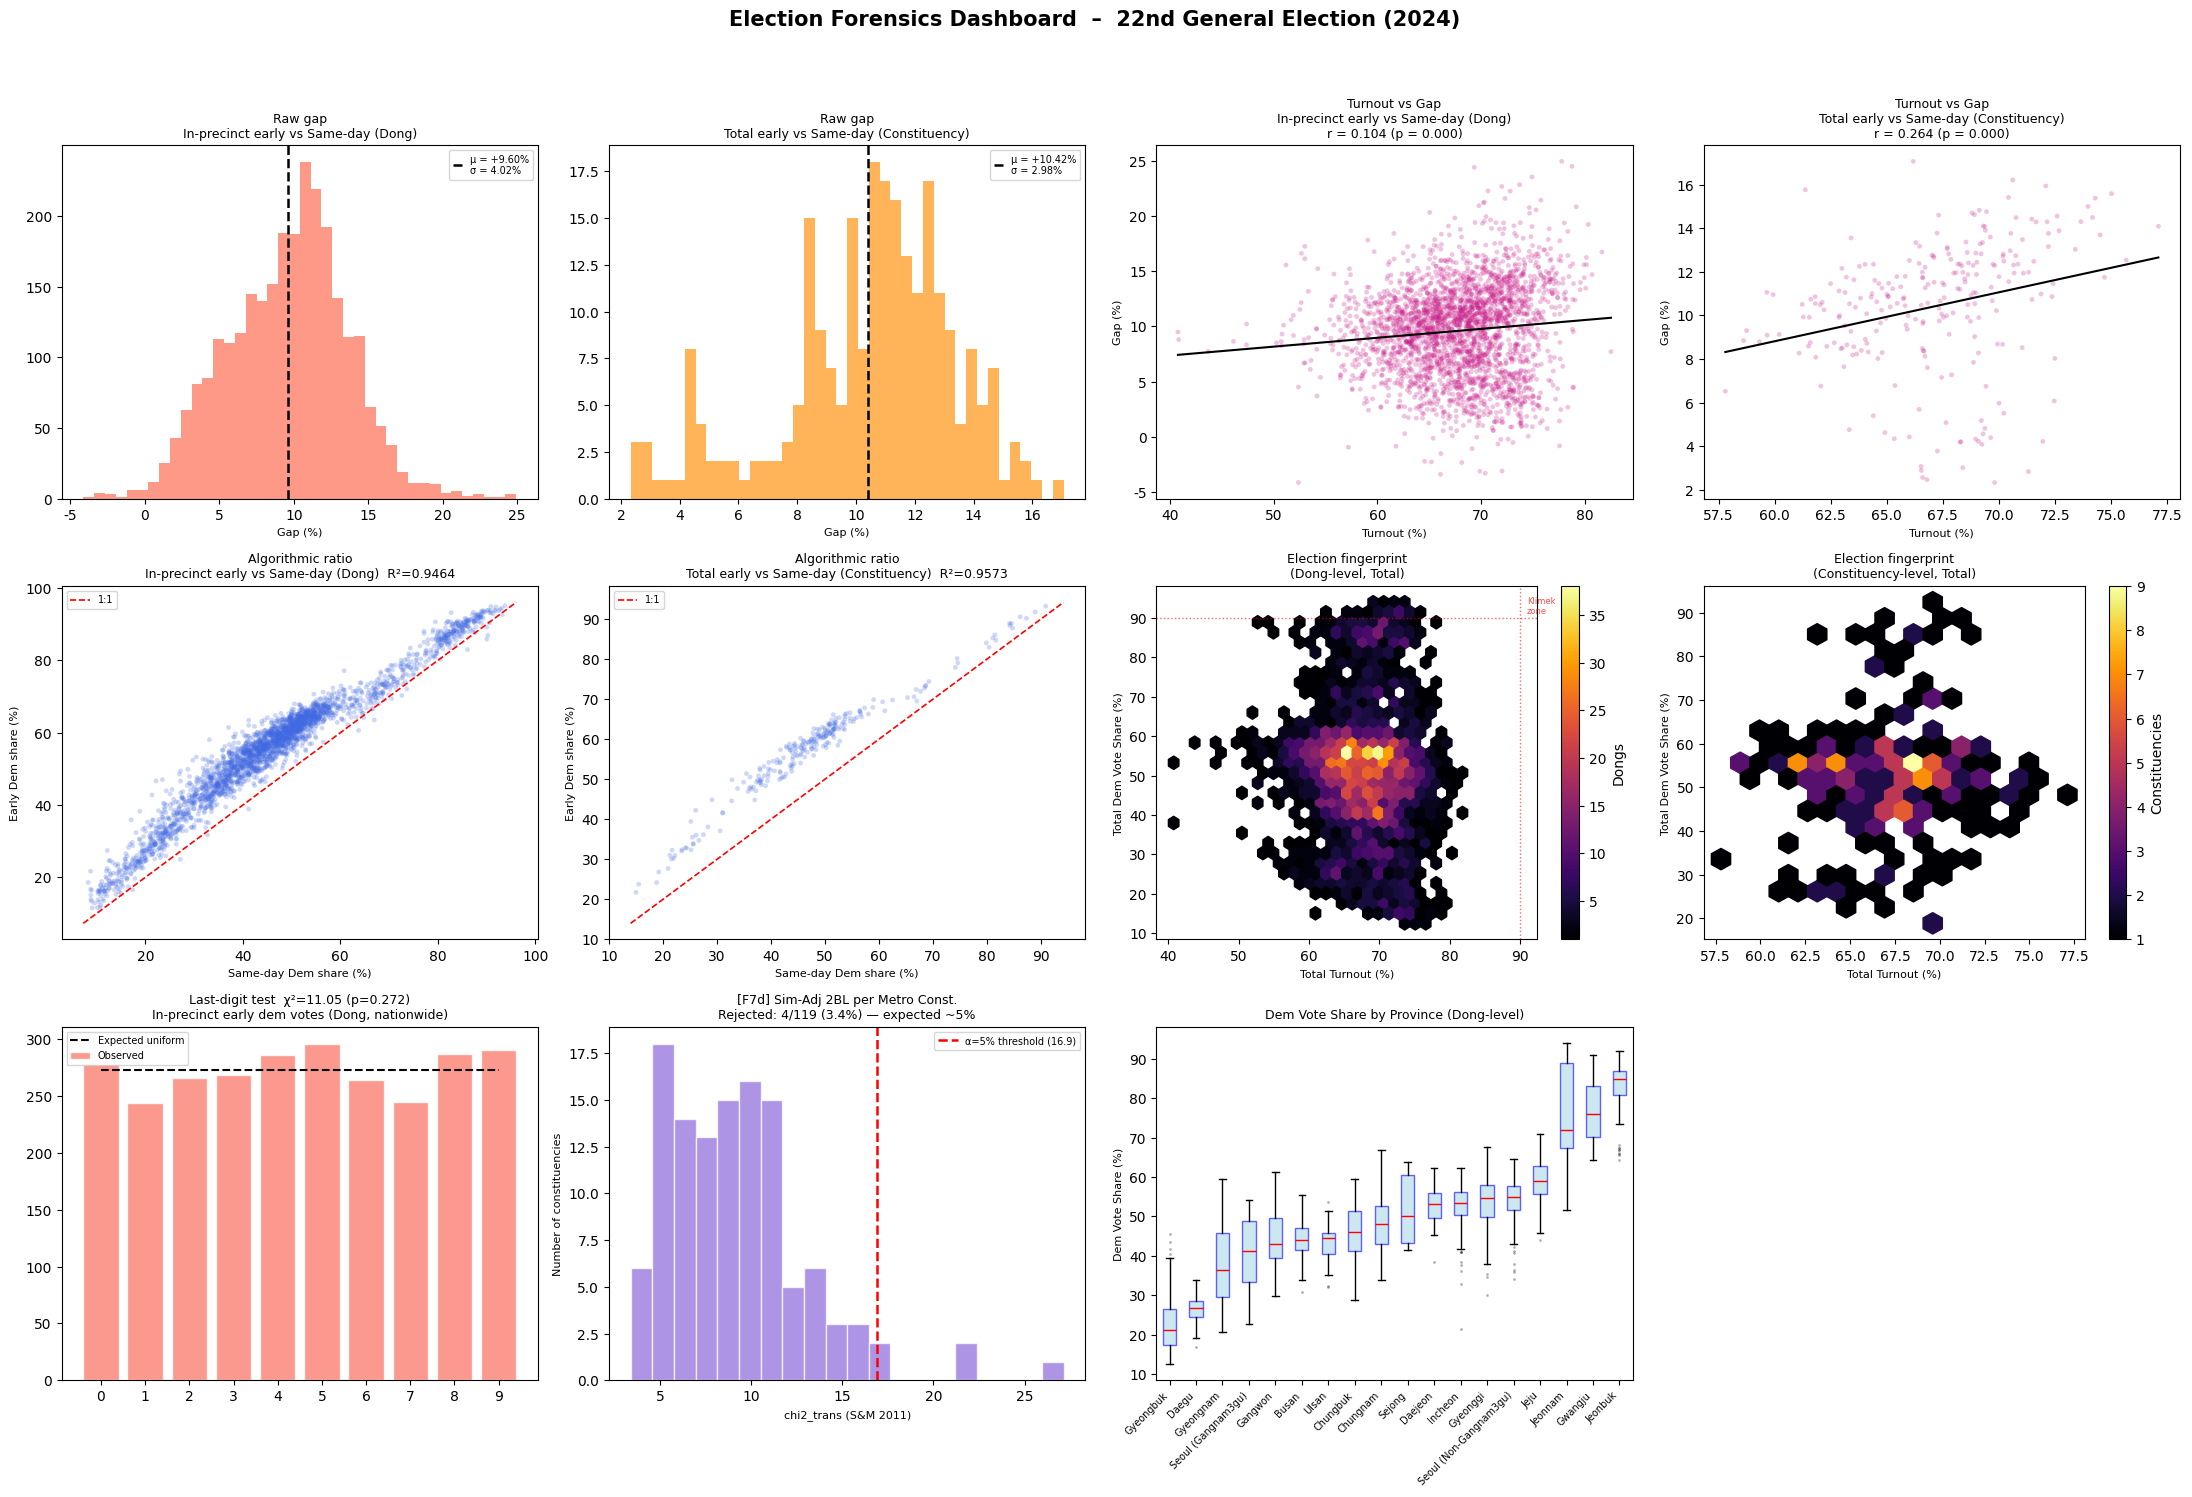

In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.transforms import Bbox
import os
import re
from scipy.stats import chisquare, pearsonr, norm, gaussian_kde, multivariate_t
from sklearn.mixture import GaussianMixture

try:
    import koreanize_matplotlib
except ImportError:
    print("[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib")

# ==========================================
# FONT SETUP
# ==========================================

def setup_font():
    """Configure matplotlib to render text properly."""
    matplotlib.rcParams['axes.unicode_minus'] = False

# ==========================================
# CONFIGURATION
# ==========================================

ELECTION_NUM = 22   # options: 21, 22, 'pres20', 'pres21'
EXCLUDE_HONAM_YEONGNAM = False

ELECTION_CONFIGS = {
    21: {
        'election_type':  'general',
        'result_csv':     '21st_election_result.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'미래통합당|자유한국당',
        'third_pattern':  None,
        'label':          '21st General Election (2020)',
        'year':           2020,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_21st.png',
    },
    22: {
        'election_type':  'general',
        'result_csv':     '22nd_election_result.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'국민의힘',
        'third_pattern':  None,
        'label':          '22nd General Election (2024)',
        'year':           2024,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_22nd.png',
    },
    'pres20': {
        'election_type':         'presidential',
        'result_csv':            '20th_presidential_election_result.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         None,
        'label':                 '20th Presidential Election (2022)',
        'year':                  2022,
        'election_month':        3,
        'dashboard_out':         'mega_forensics_dashboard_pres20.png',
        'fallback_election_num': 21,
    },
    'pres21': {
        'election_type':         'presidential',
        'result_csv':            '21st_presidential_election_result.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         r'이준석|개혁신당',
        'label':                 '21st Presidential Election (2025)',
        'year':                  2025,
        'election_month':        6,
        'dashboard_out':         'mega_forensics_dashboard_pres21.png',
        'fallback_election_num': 22,
    },
}

CFG = ELECTION_CONFIGS[ELECTION_NUM]

SPECIAL_DONG_NAMES_GENERAL = {
    '거소·선상투표', '관외사전투표', '국외부재자투표',
    '국외부재자투표(공관)', '잘못 투입·구분된 투표지',
}
SPECIAL_DONG_NAMES_PRESIDENTIAL = {
    '거소·선상투표', '관외사전투표', '재외투표',
    '잘못 투입·구분된 투표지',
}
GWANNAESA_LABEL = '관내사전투표'
META_CANDIDATES = {'선거인수', '투표수', '무효 투표수', '기권자수'}

PROV_FULL_TO_SHORT = {
    '서울특별시': 'Seoul',  '부산광역시': 'Busan',   '대구광역시': 'Daegu',
    '인천광역시': 'Incheon','광주광역시': 'Gwangju', '대전광역시': 'Daejeon',
    '울산광역시': 'Ulsan',  '세종특별자치시': 'Sejong',
    '경기도': 'Gyeonggi',  '강원도': 'Gangwon',     '강원특별자치도': 'Gangwon',
    '충청북도': 'Chungbuk', '충청남도': 'Chungnam',
    '전라북도': 'Jeonbuk',  '전북특별자치도': 'Jeonbuk', '전라남도': 'Jeonnam',
    '경상북도': 'Gyeongbuk','경상남도': 'Gyeongnam', '제주특별자치도': 'Jeju',
}

PARTISAN_REGION_PROVINCES = {
    'Honam':   {'Jeonnam', 'Jeonbuk', 'Gwangju', '전남', '전북', '광주'},
    'Yeongnam':{'Gyeongbuk', 'Gyeongnam', 'Daegu', 'Busan', 'Ulsan',
                '경북', '경남', '대구', '부산', '울산'},
}

# ==========================================
# SHARED NORMALISATION & IO UTILITIES
# ==========================================

def _read_csv_auto(path: str, **kwargs) -> pd.DataFrame:
    try:
        return pd.read_csv(path, encoding='utf-8', **kwargs)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='cp949', **kwargs)

def normalize_dong_name(name: str) -> str:
    if not isinstance(name, str): return ""
    name = re.sub(r'\(.*?\)', '', name).strip().replace('.', '·')
    name = re.sub(r'제(\d)', r'\1', name)
    name = re.sub(r'·\d+', '', name)
    name = re.sub(r'(\d+)(동|읍|면)$', r'\2', name)
    return re.sub(r'\s+', ' ', name)

def split_admin_tokens(name: str) -> list:
    tokens, buf = [], []
    for ch in name:
        buf.append(ch)
        if ch in '시군구' and len(buf) >= 2:
            tokens.append(''.join(buf))
            buf = []
    if buf: tokens.append(''.join(buf))
    return [t for t in tokens if t]

def normalize_sigungu(name: str) -> list:
    if not isinstance(name, str): return []
    name = re.sub(r'\(.*?\)', '', name).strip()
    if not name: return []
    tokens = split_admin_tokens(name)
    if not tokens:
        stripped = re.sub(r'[시군구갑을병정무]$', '', name).strip()
        return [stripped] if stripped else []
    si_gun_count = sum(1 for t in tokens if t[-1] in '시군' and len(t) >= 2)
    gu_count     = sum(1 for t in tokens if t[-1] == '구'  and len(t) >= 2)
    ordered = tokens if (si_gun_count >= 2 or (si_gun_count == 0 and gu_count >= 2)) else list(reversed(tokens))
    candidates = []
    for t in ordered:
        key = re.sub(r'[시군구]$', '', t).strip()
        if key and key not in candidates: candidates.append(key)
    return candidates


# ==========================================
# 1. ELECTION CSV LOADER
# ==========================================

def load_election_csv(csv_path: str, dem_pattern: str, con_pattern: str,
                      third_pattern: str = None, election_type: str = 'general'):
    print(f"\n--- Loading Election Result Data ({csv_path}, type={election_type}) ---")
    try:
        df = _read_csv_auto(csv_path, low_memory=False)
    except Exception as e:
        print(f"[!] Failed to read election CSV: {e}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    if election_type == 'presidential':
        df = df.rename(columns={'구시군명': '선거구명', '읍면동명': '법정읍면동명'})
        special_dong_names = SPECIAL_DONG_NAMES_PRESIDENTIAL
    else:
        special_dong_names = SPECIAL_DONG_NAMES_GENERAL

    df['득표수']    = pd.to_numeric(df['득표수'], errors='coerce').fillna(0).astype(int)
    df['is_dem']   = df['후보자'].str.contains(dem_pattern,   case=False, na=False)
    df['is_con']   = df['후보자'].str.contains(con_pattern,   case=False, na=False)
    df['is_third'] = df['후보자'].str.contains(third_pattern, case=False, na=False) if third_pattern else False
    df['is_meta']  = df['후보자'].isin(META_CANDIDATES)
    df['is_early'] = df['투표구명'] == GWANNAESA_LABEL

    dong_key  = ['시도명','선거구명','법정읍면동명']
    const_key = ['시도명','선거구명']

    def sgg_cands_from_constituency(name):
        if not isinstance(name, str): return []
        if '_' in name: return normalize_sigungu(name.split('_', 1)[1])
        return normalize_sigungu(re.sub(r'[갑을병정무]$', '', name).strip())

    df_geo   = df[~df['법정읍면동명'].isin(special_dong_names)].copy()
    df_votes = df_geo[~df_geo['is_meta']].copy()

    gn_dem = df_votes[df_votes['is_dem']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot = df_votes[df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    sd_dem = df_votes[df_votes['is_dem']  & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot = df_votes[~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_total')
    gn_th  = df_votes[df_votes['is_third'] & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_third')
    sd_th  = df_votes[df_votes['is_third'] & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_third')

    sum_people_dong = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_people'))
    sum_vote_geo    = (df_geo[df_geo['후보자'] == '투표수']
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_vote_geo'))

    df_dong = gn_dem.copy()
    for frame in (gn_tot, gn_con, gn_th, sd_dem, sd_tot, sd_th,
                  sum_people_dong, sum_vote_geo):
        df_dong = df_dong.merge(frame, on=dong_key, how='outer')
    df_dong = df_dong.fillna(0)

    gn_ppl_dong = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                   .groupby(dong_key)['득표수'].sum().reset_index(name='_gn_ppl'))
    df_dong = df_dong.merge(gn_ppl_dong, on=dong_key, how='left')
    df_dong['sum_people'] = df_dong['sum_people'] + df_dong['_gn_ppl'].fillna(0)
    df_dong.drop(columns=['_gn_ppl'], inplace=True)

    df_dong['sgg_candidates'] = df_dong['선거구명'].apply(sgg_cands_from_constituency)
    df_dong['primary_sgg']    = df_dong['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_dong['dong_norm']      = df_dong['법정읍면동명'].apply(normalize_dong_name)
    df_dong['province_tag']   = df_dong['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_dong['시도명'])
    df_dong['area2_name']     = df_dong['선거구명']
    df_dong['name']           = df_dong['법정읍면동명']

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul = df_dong['province_tag'] == 'Seoul'
    mask_g3 = df_dong['primary_sgg'].isin(['강남', '서초', '송파'])
    df_dong.loc[mask_seoul & mask_g3, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_dong.loc[mask_seoul & ~mask_g3, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    # ── Constituency-level aggregates ──
    gn_dem_c  = df_votes[df_votes['is_dem'] & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot_c  = df_votes[df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con_c  = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    gn_turn_c = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_turnout'))

    # Collect ALL non-precinct absentee voting (Overseas, Shipboard, Missing boxes, Out-of-precinct)
    df_gw   = df[df['법정읍면동명'].isin(special_dong_names)]
    df_gw_v = df_gw[~df_gw['is_meta']]

    go_dem_c  = df_gw_v[df_gw_v['is_dem']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_dem')
    go_tot_c  = df_gw_v.groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_total')
    go_th_c   = df_gw_v[df_gw_v['is_third']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_third')
    go_turn_c = (df_gw[df_gw['후보자'] == '투표수']
                 .groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_turnout'))

    sd_dem_c  = df_votes[df_votes['is_dem'] & ~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot_c  = df_votes[~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_total')
    sd_turn_c = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='same_day_turnout'))

    reg_c = df_dong.groupby(const_key)['sum_people'].sum().reset_index(name='sum_people')
    df_const = reg_c.copy()
    for frame in (gn_dem_c, gn_tot_c, gn_con_c, gn_turn_c,
                  go_dem_c, go_tot_c, go_turn_c, go_th_c,
                  sd_dem_c, sd_tot_c, sd_turn_c):
        df_const = df_const.merge(frame, on=const_key, how='left')
    df_const = df_const.fillna(0)

    df_const['early_total_dem']     = df_const['in_precinct_early_dem']     + df_const['out_precinct_early_dem']
    df_const['early_total_total']   = df_const['in_precinct_early_total']   + df_const['out_precinct_early_total']
    df_const['early_total_turnout'] = df_const['in_precinct_early_turnout'] + df_const['out_precinct_early_turnout']
    df_const['total_turnout']       = df_const['early_total_turnout'] + df_const['same_day_turnout']

    go_ppl_c = (df_gw[df_gw['후보자'] == '선거인수']
                .groupby(const_key)['득표수'].sum().reset_index(name='_go_ppl'))
    df_const = df_const.merge(go_ppl_c, on=const_key, how='left')
    df_const['sum_people'] = df_const['sum_people'] + df_const['_go_ppl'].fillna(0)
    df_const.drop(columns=['_go_ppl'], inplace=True)

    df_const['sgg_candidates'] = df_const['선거구명'].apply(sgg_cands_from_constituency)
    df_const['primary_sgg']    = df_const['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_const['province_tag']   = df_const['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_const['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_c = df_const['province_tag'] == 'Seoul'
    mask_g3_c = df_const['primary_sgg'].isin(['강남', '서초', '송파'])
    df_const.loc[mask_seoul_c & mask_g3_c, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_const.loc[mask_seoul_c & ~mask_g3_c, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    sk = ['시도명','선거구명','법정읍면동명','투표구명']
    st_r = df[df['후보자'] == '선거인수'].groupby(sk)['득표수'].sum().reset_index(name='sum_people')
    st_v = df[df['후보자'] == '투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_vote')
    st_i = df[df['후보자'] == '무효 투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_invalid')
    st_d = df[df['is_dem']].groupby(sk)['득표수'].sum().reset_index(name='dem_votes')
    st_c = df[df['is_con']].groupby(sk)['득표수'].sum().reset_index(name='con_votes')

    df_station = st_r.copy()
    for frame in (st_v, st_i, st_d, st_c):
        df_station = df_station.merge(frame, on=sk, how='outer')
    df_station = df_station.fillna(0)

    df_station['is_early_flag'] = df_station['투표구명'] == GWANNAESA_LABEL
    df_station['province_tag']  = df_station['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_station['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_s = df_station['province_tag'] == 'Seoul'
    mask_g3_s = df_station['선거구명'].apply(lambda x: any(g in str(x) for g in ['강남', '서초', '송파']))
    df_station.loc[mask_seoul_s & mask_g3_s, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_station.loc[mask_seoul_s & ~mask_g3_s, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    df_station['region']        = df_station['province_tag'] + ' ' + df_station['선거구명']
    df_station['invalid_rate']  = df_station['sum_invalid'] / df_station['sum_vote'].replace(0, np.nan)

    return df_dong, df_const, df_station

# ==========================================
# 2. FORENSICS ENGINE
# ==========================================

def categorize_metro(region: str) -> str:
    if not isinstance(region, str): return "Other"
    if 'Incheon' in region or 'Gyeyang' in region or 'Yeonsu' in region: return "Incheon"
    if any(c in region for c in ('Suwon','Goyang','Seongnam','Yongin','Gyeonggi')): return "Gyeonggi"
    if 'Seoul (Gangnam3gu)' in region: return "Seoul (Gangnam3gu)"
    if 'Seoul' in region: return "Seoul (Non-Gangnam3gu)"
    return "Other"

def compute_benford_2bl(vote_series: pd.Series) -> tuple:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2_2bl, p_2bl = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return obs_2bl, exp_2bl, chi2_2bl, p_2bl, n

def compute_benford_2bl_statistic(vote_series: pd.Series) -> float:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    if len(valid) == 0: return np.nan
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2, _ = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return chi2

def simulate_2bl_critical_value(df_constituency: pd.DataFrame,
                                 dem_col:   str = 'in_precinct_early_dem',
                                 con_col:   str = 'in_precinct_early_con',
                                 total_col: str = 'in_precinct_early_total',
                                 n_simulations: int = 500,
                                 df_t:      int = 5) -> dict:
    df_sub = df_constituency[df_constituency[total_col] > 0].copy()
    if len(df_sub) < 5:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    eps = 1e-5
    v_dem   = np.maximum(df_sub[dem_col]   / df_sub[total_col], eps)
    v_con   = np.maximum(df_sub[con_col]   / df_sub[total_col], eps)
    v_other = np.maximum(1.0 - v_dem - v_con, eps)
    denom   = v_dem + v_con + v_other
    v_dem, v_con, v_other = v_dem/denom, v_con/denom, v_other/denom
    y_dem = np.log(v_dem / v_other)
    y_con = np.log(v_con / v_other)
    Y = np.column_stack([y_dem, y_con])
    mu = np.mean(Y, axis=0)
    S  = np.cov(Y, rowvar=False)
    shape_matrix = S * (df_t - 2) / df_t if df_t > 2 else S
    shape_matrix = np.atleast_2d(shape_matrix)
    try:
        rv = multivariate_t(loc=mu, shape=shape_matrix, df=df_t)
    except Exception:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    actual_voters = df_sub[total_col].values
    simulated_chi2_stats = []
    for _ in range(n_simulations):
        Y_sim = rv.rvs(size=len(df_sub))
        if len(df_sub) == 1: Y_sim = Y_sim.reshape(1, -1)
        exp_y_dem = np.exp(Y_sim[:, 0])
        exp_y_con = np.exp(Y_sim[:, 1])
        denom_sim = 1.0 + exp_y_dem + exp_y_con
        v_dem_sim = exp_y_dem / denom_sim
        sim_counts = np.round(v_dem_sim * actual_voters)
        sim_chi2 = compute_benford_2bl_statistic(pd.Series(sim_counts))
        if not np.isnan(sim_chi2): simulated_chi2_stats.append(sim_chi2)
    if not simulated_chi2_stats:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    empirical_chi2 = compute_benford_2bl_statistic(df_sub[dem_col])
    chi2_sim95     = np.percentile(simulated_chi2_stats, 95)
    chi2_trans     = (empirical_chi2 * 16.9 / chi2_sim95) if chi2_sim95 > 0 else np.nan
    return {'empirical_chi2': empirical_chi2, 'chi2_sim95': chi2_sim95, 'chi2_trans': chi2_trans}

def _classify_gmm_cluster(t_center: float, v_center: float,
                           province_tag_series: pd.Series) -> str:
    KLIMEK_TURNOUT_THRESHOLD = 0.90
    KLIMEK_SHARE_THRESHOLD   = 0.90
    joint_extreme = (t_center > KLIMEK_TURNOUT_THRESHOLD and
                     (v_center > KLIMEK_SHARE_THRESHOLD or v_center < (1 - KLIMEK_SHARE_THRESHOLD)))
    if joint_extreme:
        return "Klimek Anomaly — extreme turnout + vote share (fraud signal)"
    if province_tag_series is not None and len(province_tag_series) > 0:
        top_prov = province_tag_series.value_counts().index[0]
        for region_name, region_provs in PARTISAN_REGION_PROVINCES.items():
            if top_prov in region_provs:
                return f"Geographic/Partisan — {region_name} region ({top_prov} dominant)"
    return "Geographic/Partisan — swing or mixed region"


def run_forensics(df_dong_raw: pd.DataFrame, df_const_raw: pd.DataFrame,
                  df_station:  pd.DataFrame) -> dict:
    logs = []
    def log(msg): print(msg); logs.append(msg)

    log(f"\n--- Forensics Suite ---")
    MIN_VOTES = 50

    dm = df_dong_raw.copy()
    dm = dm[(dm['in_precinct_early_total'] > MIN_VOTES) & (dm['same_day_total'] > MIN_VOTES)].copy()
    no_cand = (dm['in_precinct_early_dem'] == 0) & (dm['same_day_dem'] == 0)
    dm = dm[~no_cand].copy()

    # --- PROPORTIONALLY ALLOCATE OUT-OF-PRECINCT VOTES TO DONG LEVEL ---
    const_sums = dm.groupby(['시도명', '선거구명'])[['in_precinct_early_total', 'same_day_total']].transform('sum')
    dm['dong_weight'] = (dm['in_precinct_early_total'] + dm['same_day_total']) / (const_sums['in_precinct_early_total'] + const_sums['same_day_total']).replace(0, np.nan)

    cols_to_merge = ['시도명', '선거구명', 'out_precinct_early_dem', 'out_precinct_early_total', 'out_precinct_early_turnout']
    if 'out_precinct_early_third' in df_const_raw.columns:
        cols_to_merge.append('out_precinct_early_third')

    df_const_sub = df_const_raw[cols_to_merge].drop_duplicates()
    dm = dm.merge(df_const_sub, on=['시도명', '선거구명'], how='left')

    dm['out_precinct_alloc_dem']     = dm['out_precinct_early_dem'].fillna(0) * dm['dong_weight'].fillna(0)
    dm['out_precinct_alloc_tot']     = dm['out_precinct_early_total'].fillna(0) * dm['dong_weight'].fillna(0)
    dm['out_precinct_alloc_turnout'] = dm['out_precinct_early_turnout'].fillna(0) * dm['dong_weight'].fillna(0)

    if 'out_precinct_early_third' in dm.columns:
        dm['out_precinct_alloc_third'] = dm['out_precinct_early_third'].fillna(0) * dm['dong_weight'].fillna(0)

    log("\n  ── Variable Definitions ──")
    log("  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total")
    log("                 The Democratic candidate's vote share among all valid ballots")
    log("                 cast at in-precinct early-voting stations (관내사전투표소).")
    log("  sameday_pct  = same_day_dem ÷ same_day_total")
    log("                 The Democratic share among voters who showed up on election day")
    log("                 (당일투표), the conventional voting mode.")
    log("  gap          = early_pct − sameday_pct")
    log("  vote_share   = (in_precinct_early_dem + same_day_dem + allocated_out_precinct_dem) ÷")
    log("                 (in_precinct_early_total + same_day_total + allocated_out_precinct_total)")
    log("                 Combined Democratic share across all voting modes (Dong level).")
    log("                 Out-of-precinct early votes are proportionally allocated to dongs.")
    log("  turnout      = (sum_vote_geo + allocated_out_precinct_turnout) ÷")
    log("                 (sum_people + allocated_out_precinct_turnout)")
    log("                 Official turnout rate. Out-of-precinct ballots and electors")
    log("                 are proportionally allocated to accurately reflect Dong turnout.")

    dm['early_pct']   = dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
    dm['sameday_pct'] = dm['same_day_dem'] / dm['same_day_total']
    dm['gap']         = dm['early_pct'] - dm['sameday_pct']
    dm['w_gap']       = dm['gap']

    dm['vote_share'] = ((dm['in_precinct_early_dem'] + dm['same_day_dem'] + dm['out_precinct_alloc_dem']) /
                        (dm['in_precinct_early_total'] + dm['same_day_total'] + dm['out_precinct_alloc_tot'])).fillna(0)

    # Corrected Dong-level turnout including absentee ballots and electors
    dm['turnout'] = (dm['sum_vote_geo'] + dm['out_precinct_alloc_turnout']) / \
                    (dm['sum_people'] + dm['out_precinct_alloc_turnout']).replace(0, np.nan)

    # ------------------------------------------------------------------
    # [F1] SECOND-DIGIT BENFORD'S LAW — nationwide naive test
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F1] Second-Digit Benford's Law (2BL) — Nationwide Naive Test")
    log("  NOTE: Uses conventional χ²(9). See [F7d] for simulation-adjusted metro result.")
    log("="*60)
    obs_2bl, exp_2bl, chi2_2bl, p_2bl, n_2bl = compute_benford_2bl(dm['in_precinct_early_dem'])
    log(f"  N (votes >= 10)      : {n_2bl:,}")
    log(f"  Chi-Square Statistic : {chi2_2bl:.4f}")
    log(f"  p-value              : {p_2bl:.4f}  (df=9)")
    log("  Result: " + ("PASS" if p_2bl > 0.05 else "FAIL"))
    log("\n  Observed vs Expected (digits 0–9):")
    for d in range(10):
        log(f"    digit {d}: obs={obs_2bl[d]:5d}  exp={exp_2bl[d]:7.1f}")

    # ------------------------------------------------------------------
    # [F2] LAST-DIGIT UNIFORMITY TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F2] Last-Digit Uniformity Test (Three-Series Comparative)")
    log("="*60)

    def _last_digit_test(series: pd.Series, label: str) -> tuple:
        v  = series.astype(int).astype(str)
        v  = v[v.str.len() >= 2]
        ld = v.str[-1].astype(int)
        n  = len(ld)
        obs = ld.value_counts().reindex(range(10), fill_value=0).sort_index()
        exp = [n / 10.0] * 10
        chi2, p = chisquare(obs.values, f_exp=exp)
        cramer_v = np.sqrt(chi2 / (n * 9)) if n > 0 else np.nan
        log(f"  [{label}]  N={n:,}  χ²={chi2:.2f}  p={p:.4f}  "
            f"Cramér's V={cramer_v:.4f}  {'FAIL ★' if p < 0.05 else 'PASS'}")
        return obs, exp, chi2, p

    obs_ld, exp_ld, chi2_ld, p_ld = _last_digit_test(
        dm['in_precinct_early_dem'], 'in_precinct_early_dem  (early, DEM)')
    obs_ld_con = pd.Series(dtype=int)
    chi2_ld_con, p_ld_con = np.nan, np.nan
    if 'in_precinct_early_con' in dm.columns and dm['in_precinct_early_con'].sum() > 0:
        obs_ld_con, _, chi2_ld_con, p_ld_con = _last_digit_test(
            dm['in_precinct_early_con'], 'in_precinct_early_con  (early, CON)')
    _last_digit_test(dm['same_day_dem'], 'same_day_dem   (sameday, DEM)')

    ld_dem_fails  = p_ld < 0.05
    ld_con_passes = np.isnan(p_ld_con) or p_ld_con >= 0.05
    if ld_dem_fails and ld_con_passes:
        log("  [!] ASYMMETRIC FAILURE: in_precinct_early_dem fails while in_precinct_early_con and")
        log("      same_day_dem pass. This cannot be explained by a counting machine artifact")
        log("      (which would affect all candidates equally). It is candidate-specific.")
    elif ld_dem_fails:
        log("  NOTE: Failure appears in multiple series — likely a structural counting artifact.")

    log(f"\n  Binomial simulation null (using actual in_precinct_early_total & p_dem per dong):")
    gn_tot_col = dm['in_precinct_early_total'].astype(int).values
    p_dem_col  = (dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
                  .replace(0, np.nan)).fillna(0).values
    np.random.seed(42)
    sim_counts = np.array([np.random.binomial(int(N), float(p))
                           for N, p in zip(gn_tot_col, p_dem_col)])
    ld_sim = sim_counts % 10
    obs_sim = np.bincount(ld_sim, minlength=10)
    chi2_sim, p_sim = chisquare(obs_sim, f_exp=[len(ld_sim)/10]*10)
    log(f"  Simulated χ²={chi2_sim:.2f} (p={p_sim:.4f}) vs Actual χ²={chi2_ld:.2f} (p={p_ld:.4f})")
    if p_ld < 0.05 and p_sim >= 0.05:
        log("  The actual deviation exceeds what pure binomial sampling predicts.")

    # ------------------------------------------------------------------
    # [F3] VOTE-SHARE VARIANCE
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F3] Vote-Share Variance (Inter-Neighbourhood Dispersion)")
    log("="*60)
    variances = dm.groupby(['province_tag','primary_sgg'])['vote_share'].std().dropna() * 100
    mean_sd   = variances.mean()
    log(f"  Mean within-city std of dem vote share: {mean_sd:.2f}%")

    # ------------------------------------------------------------------
    # [F4] ALGORITHMIC RATIO CHECK
    # ------------------------------------------------------------------
    corr_a, _ = pearsonr(dm['sameday_pct'], dm['early_pct'])

    # ------------------------------------------------------------------
    # [F5] INVALID VOTE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F5] Invalid Vote Analysis")
    log("="*60)
    valid_st = df_station[df_station['sum_vote'] > 0].copy()
    valid_st['dem_share'] = valid_st['dem_votes'] / valid_st['sum_vote']
    valid_inv = valid_st.dropna(subset=['invalid_rate','dem_share'])
    valid_inv = valid_inv[(valid_inv['invalid_rate'] < 1) & (valid_inv['dem_share'] > 0)]
    if len(valid_inv) >= 10:
        corr_inv, p_inv = pearsonr(valid_inv['invalid_rate'], valid_inv['dem_share'])
        log(f"  N stations        : {len(valid_inv):,}")
        log(f"  Pearson r (invalid rate ↔ dem share): {corr_inv:.4f}  (p={p_inv:.4f})")
        log("  Result: " + (
            "Near-zero — no weaponized invalid ballot signal." if abs(corr_inv) < 0.10
            else f"Non-trivial r={corr_inv:.4f}. Warrants further investigation."))
    else:
        corr_inv, p_inv = np.nan, np.nan
        log("  [!] Insufficient data for invalid vote correlation.")

    # ------------------------------------------------------------------
    # [F6] REGIONAL AGGREGATE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F6] Regional Aggregate Analysis (Metropolitan Two-Party Ratio)")
    log("="*60)
    df_station['metro_zone'] = df_station['region'].apply(categorize_metro)
    valid_tp = df_station[(df_station['dem_votes'] + df_station['con_votes']) > 0].copy()
    valid_tp['two_party_dem'] = valid_tp['dem_votes'] / (valid_tp['dem_votes'] + valid_tp['con_votes'])

    metro_agg = valid_tp.groupby('metro_zone').agg(
        dem_total=('dem_votes','sum'),
        con_total=('con_votes','sum'),
        station_count=('dem_votes','count'),
    ).reset_index()
    metro_agg['dem_ratio'] = metro_agg['dem_total'] / (metro_agg['dem_total'] + metro_agg['con_total'])
    metro_agg['con_ratio'] = 1.0 - metro_agg['dem_ratio']

    for _, row in metro_agg[metro_agg['metro_zone'] != 'Other'].iterrows():
        log(f"    {row['metro_zone']:12s}: {row['dem_ratio']*100:.2f}% vs {row['con_ratio']*100:.2f}%"
            f"  (n={row['station_count']:,} stations)")
    metro_stations = valid_tp[valid_tp['metro_zone'] != 'Other']
    metro_std = metro_stations['two_party_dem'].std() * 100
    log(f"  Micro std of two-party dem share across metro stations: {metro_std:.2f}%")

    # ------------------------------------------------------------------
    # [F7] METRO EARLY-VOTING DIGIT TESTS & 63:37 RATIO HYPOTHESIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F7] Metro Early-Voting Digit Tests & 63:37 Ratio Hypothesis")
    log("  (Seoul / Incheon / Gyeonggi – in-precinct early votes only)")
    log("="*60)

    METRO_PROVINCES = {'Seoul (Non-Gangnam3gu)', 'Seoul (Gangnam3gu)', 'Incheon', 'Gyeonggi'}
    dm_metro = dm[dm['province_tag'].isin(METRO_PROVINCES)].copy()

    obs_2bl_metro  = pd.Series(dtype=int);  exp_2bl_metro  = np.zeros(10)
    chi2_2bl_metro = np.nan;                p_2bl_metro    = np.nan;  n_2bl_metro = 0
    obs_ld_metro   = pd.Series(dtype=int);  exp_ld_metro   = []
    chi2_ld_metro  = np.nan;                p_ld_metro     = np.nan
    metro_early_agg  = pd.DataFrame()
    metro_early_std  = np.nan
    sm_const_results = pd.DataFrame()

    if len(dm_metro) < 10:
        log("  [!] Insufficient metro data.")
    else:
        # F7a – Naive 2BL
        log(f"\n  [F7a] Naive 2BL – Metro in_precinct_early_dem (N={len(dm_metro):,} precincts)")
        log(f"  NOTE: Naive χ²(9) test only. See [F7d] for simulation-adjusted result.")
        obs_2bl_metro, exp_2bl_metro, chi2_2bl_metro, p_2bl_metro, n_2bl_metro = (
            compute_benford_2bl(dm_metro['in_precinct_early_dem']))
        log(f"  N (votes >= 10)      : {n_2bl_metro:,}")
        log(f"  Chi-Square Statistic : {chi2_2bl_metro:.4f}")
        log(f"  p-value              : {p_2bl_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_2bl_metro > 0.05 else "FAIL"))

        votes_metro_sm  = dm_metro['in_precinct_early_dem'][dm_metro['in_precinct_early_dem'] >= 10].values.astype(float)
        votes_nation_sm = dm['in_precinct_early_dem'][dm['in_precinct_early_dem'] >= 10].values.astype(float)
        metro_min_sr    = int(votes_metro_sm.min())  if len(votes_metro_sm)  > 0 else 0
        metro_max_sr    = int(votes_metro_sm.max())  if len(votes_metro_sm)  > 0 else 0
        nation_min_sr   = int(votes_nation_sm.min()) if len(votes_nation_sm) > 0 else 0
        nation_max_sr   = int(votes_nation_sm.max()) if len(votes_nation_sm) > 0 else 0
        metro_orders    = np.log10(metro_max_sr  / metro_min_sr)  if metro_min_sr  > 0 else 0.0
        nation_orders   = np.log10(nation_max_sr / nation_min_sr) if nation_min_sr > 0 else 0.0
        log(f"\n  Scale-Range Comparison (Fewster 2009):")
        log(f"    Nationwide [F1] range : {nation_min_sr:,} – {nation_max_sr:,} ({nation_orders:.2f} orders of magnitude)")
        log(f"    Metro [F7a] range      : {metro_min_sr:,} – {metro_max_sr:,} ({metro_orders:.2f} orders of magnitude)")

        try:
            hist_counts_sm, hist_edges_sm = np.histogram(
                votes_metro_sm, bins=min(50, max(10, len(votes_metro_sm)//10)))
            bin_width_sm = hist_edges_sm[1] - hist_edges_sm[0]
            mode_approx  = float(hist_edges_sm[np.argmax(hist_counts_sm)] + bin_width_sm / 2.0)
            kde_obj      = gaussian_kde(votes_metro_sm)
            kde_x        = np.linspace(votes_metro_sm.min(),
                                       min(float(votes_metro_sm.max()), 2000.0), 1000)
            kde_max      = float(kde_obj(kde_x).max())
        except Exception as e:
            mode_approx, kde_max = np.nan, np.nan
            log(f"  [!] Homogeneity diagnostic error: {e}")

        log(f"\n  Shikano & Mack (2011) Homogeneity Diagnostic:")
        log(f"  NOTE: S&M thresholds calibrated for station-level counts (~50–500 votes).")
        log(f"  This analysis uses Dong-level aggregates (mode ~{mode_approx:.0f} votes).")
        log(f"    Approx. mode of metro vote-count distribution : {mode_approx:.0f} votes")
        log(f"    KDE max density (homogeneity proxy)            : {kde_max:.5f}")
        log(f"    S&M station-level conditions (for reference):")
        log(f"      (1) mode ∈ [80, 190]  → {'YES' if not np.isnan(mode_approx) and 80 <= mode_approx <= 190 else 'NO'}")
        log(f"      (2) KDE max > 0.01    → {'YES' if not np.isnan(kde_max) and kde_max > 0.01 else 'NO'}")
        mode_in_range   = not np.isnan(mode_approx) and (80 <= mode_approx <= 190)
        kde_homogeneous = not np.isnan(kde_max) and (kde_max > 0.01)
        if mode_in_range and kde_homogeneous:
            log(f"  Both S&M station-level conditions met (unexpected at Dong level).")
        else:
            log(f"  Neither S&M station-level condition met (expected at Dong aggregation).")
            log(f"  Simulation-adjusted result [F7d] is the primary forensic indicator.")

        # F7b – Last-digit metro
        log(f"\n  [F7b] Last-Digit – Metro in_precinct_early_dem")
        v_ld_m = dm_metro['in_precinct_early_dem'].astype(int).astype(str)
        v_ld_m = v_ld_m[v_ld_m.str.len() >= 2]
        obs_ld_metro  = v_ld_m.str[-1].astype(int).value_counts().reindex(range(10), fill_value=0).sort_index()
        exp_ld_metro  = [len(v_ld_m) / 10.0] * 10
        chi2_ld_metro, p_ld_metro = chisquare(obs_ld_metro.values, f_exp=exp_ld_metro)
        log(f"  N (votes, len >= 2)  : {len(v_ld_m):,}")
        log(f"  Chi-Square Statistic : {chi2_ld_metro:.4f}")
        log(f"  p-value              : {p_ld_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_ld_metro > 0.05 else "FAIL"))

        # F7c – Early-only two-party ratio
        log(f"\n  [F7c] Early-Only Two-Party Ratio (in-precinct early, 63:37 hypothesis)")
        early_st = df_station[
            df_station['is_early_flag'] &
            (df_station['metro_zone'] != 'Other') &
            ((df_station['dem_votes'] + df_station['con_votes']) > 0)
        ].copy()
        early_st['two_party_dem_early'] = (
            early_st['dem_votes'] / (early_st['dem_votes'] + early_st['con_votes']))
        metro_early_agg = early_st.groupby('metro_zone').agg(
            early_dem_total=('dem_votes','sum'),
            early_con_total=('con_votes','sum'),
            station_count=('dem_votes','count'),
        ).reset_index()
        metro_early_agg['early_dem_ratio'] = (
            metro_early_agg['early_dem_total'] /
            (metro_early_agg['early_dem_total'] + metro_early_agg['early_con_total']))
        metro_early_agg['early_con_ratio'] = 1.0 - metro_early_agg['early_dem_ratio']

        log(f"  Macro early-voting two-party ratios (Dem vs Con):")
        for _, row in metro_early_agg.iterrows():
            log(f"    {row['metro_zone']:22s}: {row['early_dem_ratio']*100:.2f}% vs {row['early_con_ratio']*100:.2f}%"
                f"  (n={row['station_count']:,} early stations)")

        # --- Calculate Total Seoul ---
        seoul_rows = metro_early_agg[metro_early_agg['metro_zone'].str.contains('Seoul', na=False)]
        if not seoul_rows.empty:
            s_dem_tot = seoul_rows['early_dem_total'].sum()
            s_con_tot = seoul_rows['early_con_total'].sum()
            s_n_stat  = seoul_rows['station_count'].sum()
            if s_dem_tot + s_con_tot > 0:
                s_dem_ratio = s_dem_tot / (s_dem_tot + s_con_tot)
                s_con_ratio = 1.0 - s_dem_ratio
                log(f"    {'-'*55}")
                log(f"    {'Seoul (Combined Total)':22s}: {s_dem_ratio*100:.2f}% vs {s_con_ratio*100:.2f}%"
                    f"  (n={s_n_stat:,} early stations)")
        # ----------------------------------

        metro_early_std = early_st['two_party_dem_early'].std() * 100
        log(f"\n  Micro std of early two-party dem share across metro stations: {metro_early_std:.2f}%")
        log(f"  HIGH micro std alongside any macro convergence → LLN, not top-down fixing.")
        log(f"  LOW micro std (<2%) with near-63:37 macro → supports fixed-ratio hypothesis.")

        # F7d – Simulation-adjusted 2BL per metro constituency
        log(f"\n  [F7d] Simulation-Adjusted 2BL Per Metro Constituency (S&M 2011)")
        log(f"  Unit: dongs within each constituency  |  Simulations: 500  |  df_t=5")
        if 'in_precinct_early_con' not in df_dong_raw.columns:
            log("  [!] in_precinct_early_con not found in dong data. Skipping simulation-based test.")
        else:
            metro_dong_raw = df_dong_raw[
                df_dong_raw['province_tag'].isin(METRO_PROVINCES) &
                (df_dong_raw['in_precinct_early_total'] > MIN_VOTES)
            ].copy()
            sm_rows = []
            for (sido, const_name), grp in metro_dong_raw.groupby(['province_tag','선거구명']):
                if len(grp) < 5: continue
                res = simulate_2bl_critical_value(grp, n_simulations=500, df_t=5)
                res['Province']     = sido
                res['Constituency'] = const_name
                res['n_dongs']      = len(grp)
                sm_rows.append(res)
            if sm_rows:
                sm_const_results = pd.DataFrame(sm_rows)
                valid_mask = sm_const_results['chi2_trans'].notna()
                n_valid    = valid_mask.sum()
                n_reject   = (sm_const_results.loc[valid_mask,'chi2_trans'] > 16.9).sum()
                pct_reject = n_reject / n_valid * 100 if n_valid > 0 else 0.0
                log(f"  Metro constituencies analysed    : {len(sm_const_results)}")
                log(f"  With valid simulation results    : {n_valid}")
                log(f"  Exceeding sim-adjusted threshold : {n_reject} ({pct_reject:.1f}%)  (expected ~5%)")
                log("  Result: " + (
                    "PASS — rejection rate within chance expectation." if pct_reject <= 7.5
                    else "FAIL — more rejections than chance predicts. Warrants review."))
                log(f"\n  Top 10 constituencies by chi2_trans:")
                log(f"  {'Province':<22} {'Constituency':<20} {'emp_χ²':>8} {'sim95':>7} {'trans_χ²':>9} {'n_dongs':>7}")
                top_sm = (sm_const_results.dropna(subset=['chi2_trans'])
                          .sort_values('chi2_trans', ascending=False).head(10))
                for _, r in top_sm.iterrows():
                    flag = " ★" if r['chi2_trans'] > 16.9 else ""
                    log(f"  {str(r['Province'])[:22]:<22} {str(r['Constituency']):<20} "
                        f"{r['empirical_chi2']:8.2f} {r['chi2_sim95']:7.2f} "
                        f"{r['chi2_trans']:9.2f}{flag}  (n={int(r['n_dongs'])})")
            else:
                log("  [!] No valid simulation results produced.")

    # ------------------------------------------------------------------
    # [F8] BEBER & SCACCO "0s AND 5s" TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F8] Beber & Scacco '0s and 5s' Test (Human Fabrication Signature)")
    log("="*60)
    v_ld_all    = dm['in_precinct_early_dem'].astype(int).astype(str)
    v_ld_all    = v_ld_all[v_ld_all.str.len() >= 2]
    last_digits = v_ld_all.str[-1].astype(int)
    count_05    = last_digits.isin([0, 5]).sum()
    n_ld        = len(last_digits)
    p_hat_05    = count_05 / n_ld if n_ld > 0 else 0.0
    p_0         = 0.20
    if n_ld > 0:
        se_p      = np.sqrt(p_0 * (1 - p_0) / n_ld)
        z_05      = (p_hat_05 - p_0) / se_p
        p_val_05  = 2 * (1 - norm.cdf(abs(z_05)))
        log(f"  Observed 0s/5s frequency : {p_hat_05*100:.2f}%  (Expected: 20.00%)")
        log(f"  Z-Statistic              : {z_05:.4f}")
        log(f"  p-value                  : {p_val_05:.4e}")
        log("  Result: " + (
            "PASS – No significant human preference for 0s and 5s." if p_val_05 > 0.05
            else "FAIL – Unnatural frequency of 0s and 5s detected."))

    # ------------------------------------------------------------------
    # [F9] BEBER & SCACCO MEAN & VARIANCE OF LAST DIGITS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F9] Beber & Scacco Mean & Variance of Last Digits")
    log("="*60)
    if n_ld > 0:
        mean_ld = last_digits.mean()
        var_ld  = last_digits.var()
        se_mean = np.sqrt(8.25 / n_ld)
        z_mean  = (mean_ld - 4.5) / se_mean
        p_val_mean = 2 * (1 - norm.cdf(abs(z_mean)))
        log(f"  Observed Mean     : {mean_ld:.4f}  (Expected: 4.5)")
        log(f"  Observed Variance : {var_ld:.4f}   (Expected: 8.25)")
        log(f"  Mean Z-Statistic  : {z_mean:.4f}  (p={p_val_mean:.4e})")
        log("  Result: " + (
            "PASS – Last digit mean conforms to uniform distribution." if p_val_mean > 0.05
            else "FAIL – Last digit mean deviates from uniform expectation."))

    # ------------------------------------------------------------------
    # [F10] KLIMEK ET AL. MIXTURE MODELING (Election Fingerprint)
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F10] Klimek et al. Mixture Modeling (Election Fingerprint)")
    log("  NOTE: Fraud signal = HIGH TURNOUT + HIGH VOTE SHARE simultaneously.")
    log("  A cluster extreme only in vote share at normal turnout is geographic.")
    log("="*60)
    fp_data_raw = dm[['turnout','vote_share','province_tag']].dropna()
    fp_data     = fp_data_raw[['turnout','vote_share']].copy()
    if len(fp_data) > 50:
        best_gmm, best_bic, best_n = None, np.inf, 2
        for n_comp in range(2, 7):
            g   = GaussianMixture(n_components=n_comp, random_state=42, n_init=3)
            g.fit(fp_data)
            bic = g.bic(fp_data)
            if bic < best_bic: best_bic, best_gmm, best_n = bic, g, n_comp
        log(f"  BIC-selected n_components: {best_n}  (BIC={best_bic:.1f})")
        labels  = best_gmm.predict(fp_data)
        weights = best_gmm.weights_
        centers = best_gmm.means_
        sorted_indices = np.argsort(weights)[::-1]
        log(f"  Identified Clusters (Turnout %, Dem Vote Share %):")
        klimek_anomaly_found = False
        for i, idx in enumerate(sorted_indices):
            w        = weights[idx] * 100
            t_center = centers[idx][0]
            v_center = centers[idx][1]
            cluster_provs = fp_data_raw.loc[fp_data.index[labels == idx], 'province_tag']
            c_type   = _classify_gmm_cluster(t_center, v_center, cluster_provs)
            if "Anomaly" in c_type: klimek_anomaly_found = True
            log(f"    Cluster {i+1}: Weight={w:.1f}%  "
                f"Turnout={t_center*100:.1f}%  VoteShare={v_center*100:.1f}%")
            log(f"             → {c_type}")
        if klimek_anomaly_found:
            log("  [!] KLIMEK FLAG: At least one cluster meets the fraud criterion.")
        else:
            log("  Result: No cluster meets the Klimek joint fraud criterion.")
            log("          Cluster separation is explained by regional partisanship.")
    else:
        log("  [!] Insufficient data for Klimek GMM modeling.")

    # ------------------------------------------------------------------
    # Constituency-level frame
    # ------------------------------------------------------------------
    cm = df_const_raw.copy()
    cm = cm[(cm['early_total_total'] > MIN_VOTES) & (cm['same_day_total'] > MIN_VOTES)].copy()
    no_cand_c = (cm['early_total_dem'] == 0) & (cm['same_day_dem'] == 0)
    cm = cm[~no_cand_c].copy()

    cm['early_pct']              = cm['early_total_dem']  / cm['early_total_total']
    cm['sameday_pct']            = cm['same_day_dem']     / cm['same_day_total']
    cm['gap']                    = cm['early_pct'] - cm['sameday_pct']
    cm['w_gap']                  = cm['gap']

    # Constituency vote_share natively captures in-precinct + out-precinct in `early_total_dem`
    cm['vote_share']             = ((cm['early_total_dem'] + cm['same_day_dem']) /
                                    (cm['early_total_total'] + cm['same_day_total']))
    cm['turnout']                = cm['total_turnout'] / cm['sum_people'].replace(0, np.nan)

    corr_b, _ = pearsonr(cm['sameday_pct'], cm['early_pct'])

    return {
        'dong': {
            'df': dm,
            'obs_2bl': obs_2bl, 'exp_2bl': exp_2bl, 'chi2_2bl': chi2_2bl, 'p_2bl': p_2bl, 'n_2bl': n_2bl,
            'obs_ld':  obs_ld,  'exp_ld':  exp_ld,  'chi2_ld':  chi2_ld,  'p_ld':  p_ld,
            'variances': variances, 'mean_sd': mean_sd,
            'corr_inv': corr_inv, 'p_inv': p_inv,
            'metro_agg': metro_agg, 'metro_std': metro_std,
            'obs_2bl_metro': obs_2bl_metro, 'exp_2bl_metro': exp_2bl_metro,
            'chi2_2bl_metro': chi2_2bl_metro, 'p_2bl_metro': p_2bl_metro, 'n_2bl_metro': n_2bl_metro,
            'obs_ld_metro': obs_ld_metro, 'exp_ld_metro': exp_ld_metro,
            'chi2_ld_metro': chi2_ld_metro, 'p_ld_metro': p_ld_metro,
            'metro_early_agg': metro_early_agg, 'metro_early_std': metro_early_std,
            'sm_const_results': sm_const_results,
            'r2': corr_a**2,
        },
        'const': {'df': cm, 'r2': corr_b**2},
        'forensics_logs': logs,
    }

# ==========================================
# 3. DASHBOARDS & REPORTS
# ==========================================

def save_all_subplots_from_fig(fig, base_filename, out_dir):
    """Extracts and saves every individual subplot from a composite figure."""
    os.makedirs(out_dir, exist_ok=True)
    # Draw the canvas to compute bounding boxes correctly
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    saved_count = 0
    for i, ax in enumerate(fig.axes):
        # Skip empty axes
        if not ax.axison and not ax.has_data() and not ax.texts and not ax.patches:
            continue

        bbox = ax.get_tightbbox(renderer)
        if bbox is None:
            continue

        extent = bbox.transformed(fig.dpi_scale_trans.inverted())

        # Add padding to ensure titles/ticks are not clipped
        padded_extent = Bbox.from_extents(
            extent.x0 - 0.15,
            extent.y0 - 0.15,
            extent.x1 + 0.15,
            extent.y1 + 0.15
        )

        if padded_extent.width > 0 and padded_extent.height > 0:
            out_name = os.path.join(out_dir, f"{base_filename}_subfig_{saved_count:02d}.png")
            try:
                fig.savefig(out_name, bbox_inches=padded_extent, dpi=200)
                saved_count += 1
            except Exception:
                pass


def _draw_naive_2bl(ax, obs_2bl, exp_2bl, results):
    """Fallback panel: naive nationwide 2BL bar chart."""
    digits = np.arange(10)
    w = 0.4
    chi2_2bl = results['dong']['chi2_2bl']
    p_2bl    = results['dong']['p_2bl']
    ax.bar(digits - w/2, obs_2bl, w, color='mediumpurple', alpha=0.8,
           edgecolor='white', label='Observed')
    ax.bar(digits + w/2, exp_2bl, w, color='slategray',    alpha=0.6,
           edgecolor='white', label='Expected (Benford)')
    ax.set_title(f'2nd-digit Benford (2BL, naive)  χ²={chi2_2bl:.2f} (p={p_2bl:.3f})\n'
                 f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    ax.set_xticks(digits)
    ax.legend(fontsize=7)


def plot_dashboard(results: dict, out_path: str, title: str):
    setup_font()
    print(f"\nGenerating visual dashboard → {out_path}")
    dm       = results['dong']['df']
    cm       = results['const']['df']
    obs_ld   = results['dong']['obs_ld']
    exp_ld   = results['dong']['exp_ld']
    obs_2bl  = results['dong']['obs_2bl']
    exp_2bl  = results['dong']['exp_2bl']
    r2_dong  = results['dong']['r2']
    r2_const = results['const']['r2']
    sm_const_results = results['dong'].get('sm_const_results', pd.DataFrame())

    fig, axes = plt.subplots(3, 4, figsize=(22, 15))
    fig.suptitle(f"Election Forensics Dashboard  –  {title}",
                 fontsize=15, fontweight='bold', y=0.995)

    LEVEL_A = 'In-precinct early vs Same-day (Dong)'
    LEVEL_B = 'Total early vs Same-day (Constituency)'

    def hist_gap(ax, data, label, color):
        data = data.replace([np.inf, -np.inf], np.nan).dropna()
        if len(data) == 0: return
        ax.hist(data * 100, bins=40, color=color, alpha=0.65, edgecolor='none')
        ax.axvline(data.mean() * 100, color='black', lw=1.8, ls='--',
                   label=f'μ = {data.mean()*100:+.2f}%\nσ = {data.std()*100:.2f}%')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Gap (%)', fontsize=8)
        ax.legend(fontsize=7, handlelength=1)

    def scatter_ratio(ax, x, y, r2, label):
        if len(x) == 0 or len(y) == 0: return
        mn = min(x.min(), y.min()) * 100 - 1
        mx = max(x.max(), y.max()) * 100 + 1
        ax.scatter(x * 100, y * 100, alpha=0.25, s=12, color='royalblue', edgecolors='none')
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.2, label='1:1')
        ax.set_title(f'{label}  R²={r2:.4f}', fontsize=9)
        ax.set_xlabel('Same-day Dem share (%)', fontsize=8)
        ax.set_ylabel('Early Dem share (%)', fontsize=8)
        ax.legend(fontsize=7)

    def scatter_turnout_gap(ax, turnout, gap, label):
        valid = pd.DataFrame({'t': turnout, 'g': gap}).replace([np.inf, -np.inf], np.nan).dropna()
        if len(valid) == 0: return
        ax.scatter(valid['t']*100, valid['g']*100, alpha=0.25, s=12, color='mediumvioletred', edgecolors='none')
        if len(valid) > 5:
            z = np.polyfit(valid['t']*100, valid['g']*100, 1)
            p = np.poly1d(z)
            xl = np.linspace(valid['t'].min()*100, valid['t'].max()*100, 100)
            ax.plot(xl, p(xl), 'k-', lw=1.5)
            r, p_val = pearsonr(valid['t'], valid['g'])
            subtitle = f'r = {r:.3f} (p = {p_val:.3f})'
        else:
            subtitle = ''
        ax.set_title(f'{label}\n{subtitle}', fontsize=9)
        ax.set_xlabel('Turnout (%)', fontsize=8)
        ax.set_ylabel('Gap (%)', fontsize=8)

    def boxplot_prov_share(ax, df):
        valid = df.dropna(subset=['province_tag', 'vote_share']).copy()
        if len(valid) == 0:
            ax.axis('off')
            return
        medians = valid.groupby('province_tag')['vote_share'].median().sort_values()
        data = [valid[valid['province_tag'] == p]['vote_share'].values * 100 for p in medians.index]
        ax.boxplot(data, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue', alpha=0.6),
                   medianprops=dict(color='red'),
                   flierprops=dict(marker='o', markerfacecolor='black', markeredgecolor='none', markersize=2, alpha=0.3))
        ax.set_title('Dem Vote Share by Province (Dong-level)', fontsize=9)
        ax.set_xticks(range(1, len(medians) + 1))
        ax.set_xticklabels(medians.index, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Dem Vote Share (%)', fontsize=8)

    # Row 0: Raw gaps and Turnout scatter
    hist_gap(axes[0,0], dm['gap'],  f'Raw gap\n{LEVEL_A}',      'tomato')
    hist_gap(axes[0,1], cm['gap'],  f'Raw gap\n{LEVEL_B}',      'darkorange')
    scatter_turnout_gap(axes[0,2], dm['turnout'], dm['gap'], f'Turnout vs Gap\n{LEVEL_A}')
    scatter_turnout_gap(axes[0,3], cm['turnout'], cm['gap'], f'Turnout vs Gap\n{LEVEL_B}')

    # Row 1: Ratios and Fingerprints
    scatter_ratio(axes[1,0], dm['sameday_pct'], dm['early_pct'], r2_dong,  f'Algorithmic ratio\n{LEVEL_A}')
    scatter_ratio(axes[1,1], cm['sameday_pct'], cm['early_pct'], r2_const, f'Algorithmic ratio\n{LEVEL_B}')

    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = axes[1,2].hexbin(fp['turnout']*100, fp['vote_share']*100,
                           gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=axes[1,2], label='Dongs')
    axes[1,2].set_title(f'Election fingerprint\n(Dong-level, Total)', fontsize=9)
    axes[1,2].set_xlabel('Total Turnout (%)', fontsize=8)
    axes[1,2].set_ylabel('Total Dem Vote Share (%)', fontsize=8)
    axes[1,2].axvline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].axhline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].text(91, 91, 'Klimek\nzone', fontsize=6, color='red', alpha=0.7)

    fpc = cm[(cm['turnout'] > 0) & (cm['turnout'] <= 1.0)]
    hb2 = axes[1,3].hexbin(fpc['turnout']*100, fpc['vote_share']*100,
                            gridsize=18, cmap='inferno', mincnt=1)
    fig.colorbar(hb2, ax=axes[1,3], label='Constituencies')
    axes[1,3].set_title(f'Election fingerprint\n(Constituency-level, Total)', fontsize=9)
    axes[1,3].set_xlabel('Total Turnout (%)', fontsize=8)
    axes[1,3].set_ylabel('Total Dem Vote Share (%)', fontsize=8)

    # Row 2: Forensics checks & Boxplots
    axes[2,0].bar(range(10), obs_ld, color='salmon',   alpha=0.8, edgecolor='white', label='Observed')
    axes[2,0].plot(range(10), exp_ld, 'k--', lw=1.5, label='Expected uniform')
    chi2_ld = results['dong']['chi2_ld']; p_ld = results['dong']['p_ld']
    axes[2,0].set_title(f'Last-digit test  χ²={chi2_ld:.2f} (p={p_ld:.3f})\n'
                        f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    axes[2,0].set_xticks(range(10))
    axes[2,0].legend(fontsize=7)

    ax21 = axes[2,1]
    if not sm_const_results.empty and 'chi2_trans' in sm_const_results.columns:
        trans_vals = sm_const_results['chi2_trans'].dropna()
        if len(trans_vals) > 0:
            ax21.hist(trans_vals, bins=20, color='mediumpurple', alpha=0.75, edgecolor='white')
            ax21.axvline(16.9, color='red', lw=1.8, ls='--', label='α=5% threshold (16.9)')
            n_reject = (trans_vals > 16.9).sum()
            pct_rej  = n_reject / len(trans_vals) * 100
            ax21.set_title(f'[F7d] Sim-Adj 2BL per Metro Const.\n'
                           f'Rejected: {n_reject}/{len(trans_vals)} ({pct_rej:.1f}%) — expected ~5%',
                           fontsize=9)
            ax21.set_xlabel('chi2_trans (S&M 2011)', fontsize=8)
            ax21.set_ylabel('Number of constituencies', fontsize=8)
            ax21.legend(fontsize=7)
        else:
            _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)
    else:
        _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)

    boxplot_prov_share(axes[2,2], dm)
    axes[2,3].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    out_dir = out_path.replace('.png', '_subfigures')
    base_name = os.path.basename(out_path).replace('.png', '')
    save_all_subplots_from_fig(fig, base_name, out_dir)

    plt.savefig(out_path, dpi=200)
    print(f"Saved visual dashboard → '{out_path}'")


def save_individual_plots(results: dict, prefix: str):
    """Saves key diagnostic plots individually for manuscript inclusion."""
    dm = results['dong']['df']
    setup_font()

    fig, ax = plt.subplots(figsize=(6, 4))
    data = dm['gap'].replace([np.inf,-np.inf], np.nan).dropna() * 100
    ax.hist(data, bins=40, color='tomato', alpha=0.65, edgecolor='none')
    ax.axvline(data.mean(), color='black', lw=1.8, ls='--', label=f'μ = {data.mean():+.2f}%')
    ax.set_title('Raw Gap (In-precinct early vs Same-day)')
    ax.set_xlabel('Gap (%)')
    ax.legend()
    fig.savefig(f"{prefix}_fig1_gap_hist.png", dpi=200, bbox_inches='tight')
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6, 4))
    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = ax.hexbin(fp['turnout']*100, fp['vote_share']*100, gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=ax, label='Dongs')
    ax.set_title('Election Fingerprint')
    ax.set_xlabel('Turnout (%)')
    ax.set_ylabel('Dem Vote Share (%)')
    fig.savefig(f"{prefix}_fig2_fingerprint.png", dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved individual plots to {prefix}_fig*.png")


def save_text_report(results: dict, out_path: str, title: str):
    print(f"Saving text report → {out_path}")
    lines = [
        f"{'='*70}",
        f"  ELECTION FORENSICS REPORT: {title}",
        f"{'='*70}", "",
        "[ SECTION 1: FORENSICS SUITE  (F1–F10) ]", "",
    ]
    lines.extend(results['forensics_logs'])
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))
    print(f"Saved text report → '{out_path}'")

# ==========================================
# 4. EXECUTION
# ==========================================

if __name__ == "__main__":
    print(f"\n{'='*60}")
    print(f"  Korean Election Forensics — {CFG['label']}")
    print(f"{'='*60}")

    election_type = CFG.get('election_type', 'general')

    df_dong, df_const, df_station = load_election_csv(
        CFG['result_csv'],
        dem_pattern=CFG['dem_pattern'],
        con_pattern=CFG['con_pattern'],
        third_pattern=CFG.get('third_pattern'),
        election_type=election_type,
    )

    if EXCLUDE_HONAM_YEONGNAM:
        exclude_provs = PARTISAN_REGION_PROVINCES['Honam'] | PARTISAN_REGION_PROVINCES['Yeongnam']
        short_exclude = set()
        for p in exclude_provs:
            short_exclude.add(PROV_FULL_TO_SHORT.get(p, p))
            short_exclude.add(p)
        df_dong    = df_dong[~df_dong['province_tag'].isin(short_exclude)]
        df_const   = df_const[~df_const['province_tag'].isin(short_exclude)]
        df_station = df_station[~df_station['province_tag'].isin(short_exclude)]
        print(f"\n[!] EXCLUDE_HONAM_YEONGNAM=True — Honam/Yeongnam filtered out.")

    if not df_dong.empty and not df_const.empty:
        results = run_forensics(df_dong, df_const, df_station)

        plot_dashboard(results, out_path=CFG['dashboard_out'], title=CFG['label'])

        save_individual_plots(results,
                              prefix=CFG['label'].replace(" ", "_").lower()[:10])

        text_report_out = CFG['dashboard_out'].replace('.png', '_report.txt')
        save_text_report(results, out_path=text_report_out, title=CFG['label'])

    else:
        print("[!] Election data could not be loaded. Aborting.")

[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib

  Korean Election Forensics — 21st Presidential Election (2025)

--- Loading Election Result Data (21st_presidential_election_result.csv, type=presidential) ---

--- Forensics Suite ---

  ── Variable Definitions ──
  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total
                 The Democratic candidate's vote share among all valid ballots
                 cast at in-precinct early-voting stations (관내사전투표소).
  sameday_pct  = same_day_dem ÷ same_day_total
                 The Democratic share among voters who showed up on election day
                 (당일투표), the conventional voting mode.
  gap          = early_pct − sameday_pct
  vote_share   = (in_precinct_early_dem + same_day_dem + allocated_out_precinct_dem) ÷
                 (in_precinct_early_total + same_day_total + allocated_out_precinct_total)
                 Combined Democratic share across all voting modes (Dong level).
            

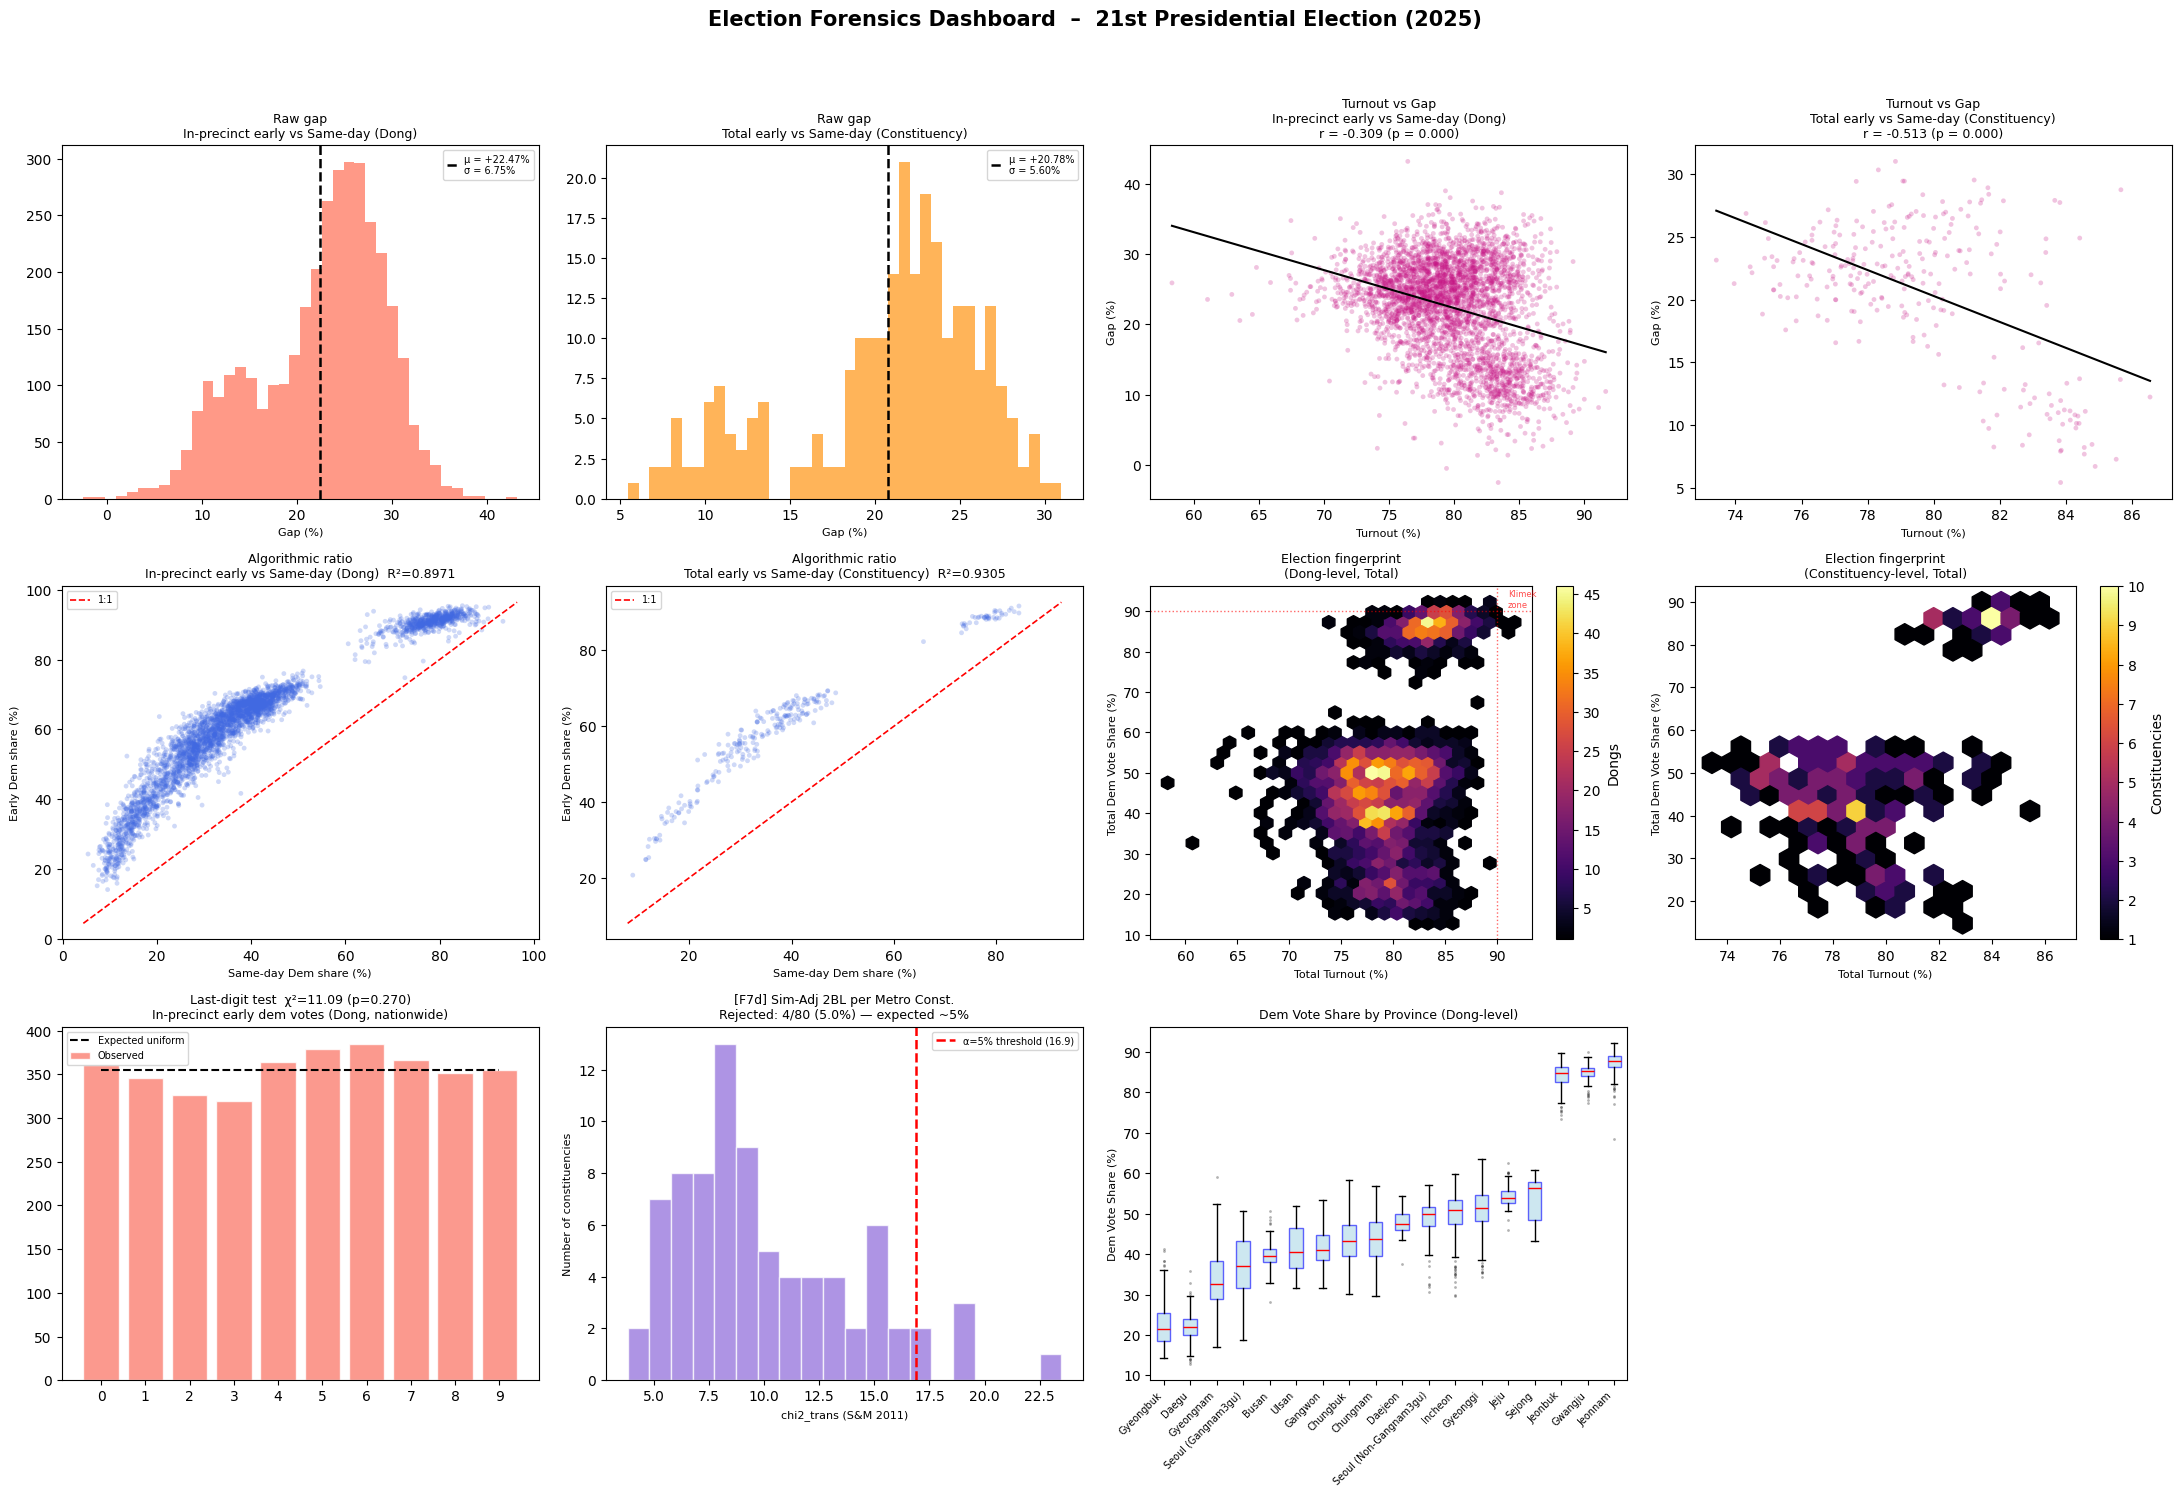

In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.transforms import Bbox
import os
import re
from scipy.stats import chisquare, pearsonr, norm, gaussian_kde, multivariate_t
from sklearn.mixture import GaussianMixture

try:
    import koreanize_matplotlib
except ImportError:
    print("[!] koreanize_matplotlib not found. Run: pip install koreanize-matplotlib")

# ==========================================
# FONT SETUP
# ==========================================

def setup_font():
    """Configure matplotlib to render text properly."""
    matplotlib.rcParams['axes.unicode_minus'] = False

# ==========================================
# CONFIGURATION
# ==========================================

ELECTION_NUM = 'pres21'   # options: 21, 22, 'pres20', 'pres21'
EXCLUDE_HONAM_YEONGNAM = False

ELECTION_CONFIGS = {
    21: {
        'election_type':  'general',
        'result_csv':     '21st_election_result.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'미래통합당|자유한국당',
        'third_pattern':  None,
        'label':          '21st General Election (2020)',
        'year':           2020,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_21st.png',
    },
    22: {
        'election_type':  'general',
        'result_csv':     '22nd_election_result.csv',
        'dem_pattern':    r'더불어민주당',
        'con_pattern':    r'국민의힘',
        'third_pattern':  None,
        'label':          '22nd General Election (2024)',
        'year':           2024,
        'election_month': 4,
        'dashboard_out':  'mega_forensics_dashboard_22nd.png',
    },
    'pres20': {
        'election_type':         'presidential',
        'result_csv':            '20th_presidential_election_result.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         None,
        'label':                 '20th Presidential Election (2022)',
        'year':                  2022,
        'election_month':        3,
        'dashboard_out':         'mega_forensics_dashboard_pres20.png',
        'fallback_election_num': 21,
    },
    'pres21': {
        'election_type':         'presidential',
        'result_csv':            '21st_presidential_election_result.csv',
        'dem_pattern':           r'더불어민주당',
        'con_pattern':           r'국민의힘',
        'third_pattern':         r'이준석|개혁신당',
        'label':                 '21st Presidential Election (2025)',
        'year':                  2025,
        'election_month':        6,
        'dashboard_out':         'mega_forensics_dashboard_pres21.png',
        'fallback_election_num': 22,
    },
}

CFG = ELECTION_CONFIGS[ELECTION_NUM]

SPECIAL_DONG_NAMES_GENERAL = {
    '거소·선상투표', '관외사전투표', '국외부재자투표',
    '국외부재자투표(공관)', '잘못 투입·구분된 투표지',
}
SPECIAL_DONG_NAMES_PRESIDENTIAL = {
    '거소·선상투표', '관외사전투표', '재외투표',
    '잘못 투입·구분된 투표지',
}
GWANNAESA_LABEL = '관내사전투표'
META_CANDIDATES = {'선거인수', '투표수', '무효 투표수', '기권자수'}

PROV_FULL_TO_SHORT = {
    '서울특별시': 'Seoul',  '부산광역시': 'Busan',   '대구광역시': 'Daegu',
    '인천광역시': 'Incheon','광주광역시': 'Gwangju', '대전광역시': 'Daejeon',
    '울산광역시': 'Ulsan',  '세종특별자치시': 'Sejong',
    '경기도': 'Gyeonggi',  '강원도': 'Gangwon',     '강원특별자치도': 'Gangwon',
    '충청북도': 'Chungbuk', '충청남도': 'Chungnam',
    '전라북도': 'Jeonbuk',  '전북특별자치도': 'Jeonbuk', '전라남도': 'Jeonnam',
    '경상북도': 'Gyeongbuk','경상남도': 'Gyeongnam', '제주특별자치도': 'Jeju',
}

PARTISAN_REGION_PROVINCES = {
    'Honam':   {'Jeonnam', 'Jeonbuk', 'Gwangju', '전남', '전북', '광주'},
    'Yeongnam':{'Gyeongbuk', 'Gyeongnam', 'Daegu', 'Busan', 'Ulsan',
                '경북', '경남', '대구', '부산', '울산'},
}

# ==========================================
# SHARED NORMALISATION & IO UTILITIES
# ==========================================

def _read_csv_auto(path: str, **kwargs) -> pd.DataFrame:
    try:
        return pd.read_csv(path, encoding='utf-8', **kwargs)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='cp949', **kwargs)

def normalize_dong_name(name: str) -> str:
    if not isinstance(name, str): return ""
    name = re.sub(r'\(.*?\)', '', name).strip().replace('.', '·')
    name = re.sub(r'제(\d)', r'\1', name)
    name = re.sub(r'·\d+', '', name)
    name = re.sub(r'(\d+)(동|읍|면)$', r'\2', name)
    return re.sub(r'\s+', ' ', name)

def split_admin_tokens(name: str) -> list:
    tokens, buf = [], []
    for ch in name:
        buf.append(ch)
        if ch in '시군구' and len(buf) >= 2:
            tokens.append(''.join(buf))
            buf = []
    if buf: tokens.append(''.join(buf))
    return [t for t in tokens if t]

def normalize_sigungu(name: str) -> list:
    if not isinstance(name, str): return []
    name = re.sub(r'\(.*?\)', '', name).strip()
    if not name: return []
    tokens = split_admin_tokens(name)
    if not tokens:
        stripped = re.sub(r'[시군구갑을병정무]$', '', name).strip()
        return [stripped] if stripped else []
    si_gun_count = sum(1 for t in tokens if t[-1] in '시군' and len(t) >= 2)
    gu_count     = sum(1 for t in tokens if t[-1] == '구'  and len(t) >= 2)
    ordered = tokens if (si_gun_count >= 2 or (si_gun_count == 0 and gu_count >= 2)) else list(reversed(tokens))
    candidates = []
    for t in ordered:
        key = re.sub(r'[시군구]$', '', t).strip()
        if key and key not in candidates: candidates.append(key)
    return candidates


# ==========================================
# 1. ELECTION CSV LOADER
# ==========================================

def load_election_csv(csv_path: str, dem_pattern: str, con_pattern: str,
                      third_pattern: str = None, election_type: str = 'general'):
    print(f"\n--- Loading Election Result Data ({csv_path}, type={election_type}) ---")
    try:
        df = _read_csv_auto(csv_path, low_memory=False)
    except Exception as e:
        print(f"[!] Failed to read election CSV: {e}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    if election_type == 'presidential':
        df = df.rename(columns={'구시군명': '선거구명', '읍면동명': '법정읍면동명'})
        special_dong_names = SPECIAL_DONG_NAMES_PRESIDENTIAL
    else:
        special_dong_names = SPECIAL_DONG_NAMES_GENERAL

    df['득표수']    = pd.to_numeric(df['득표수'], errors='coerce').fillna(0).astype(int)
    df['is_dem']   = df['후보자'].str.contains(dem_pattern,   case=False, na=False)
    df['is_con']   = df['후보자'].str.contains(con_pattern,   case=False, na=False)
    df['is_third'] = df['후보자'].str.contains(third_pattern, case=False, na=False) if third_pattern else False
    df['is_meta']  = df['후보자'].isin(META_CANDIDATES)
    df['is_early'] = df['투표구명'] == GWANNAESA_LABEL

    dong_key  = ['시도명','선거구명','법정읍면동명']
    const_key = ['시도명','선거구명']

    def sgg_cands_from_constituency(name):
        if not isinstance(name, str): return []
        if '_' in name: return normalize_sigungu(name.split('_', 1)[1])
        return normalize_sigungu(re.sub(r'[갑을병정무]$', '', name).strip())

    df_geo   = df[~df['법정읍면동명'].isin(special_dong_names)].copy()
    df_votes = df_geo[~df_geo['is_meta']].copy()

    gn_dem = df_votes[df_votes['is_dem']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot = df_votes[df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    sd_dem = df_votes[df_votes['is_dem']  & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot = df_votes[~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_total')
    gn_th  = df_votes[df_votes['is_third'] & df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='in_precinct_early_third')
    sd_th  = df_votes[df_votes['is_third'] & ~df_votes['is_early']].groupby(dong_key)['득표수'].sum().reset_index(name='same_day_third')

    sum_people_dong = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_people'))
    sum_vote_geo    = (df_geo[df_geo['후보자'] == '투표수']
                       .groupby(dong_key)['득표수'].sum().reset_index(name='sum_vote_geo'))

    df_dong = gn_dem.copy()
    for frame in (gn_tot, gn_con, gn_th, sd_dem, sd_tot, sd_th,
                  sum_people_dong, sum_vote_geo):
        df_dong = df_dong.merge(frame, on=dong_key, how='outer')
    df_dong = df_dong.fillna(0)

    gn_ppl_dong = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '선거인수')]
                   .groupby(dong_key)['득표수'].sum().reset_index(name='_gn_ppl'))
    df_dong = df_dong.merge(gn_ppl_dong, on=dong_key, how='left')
    df_dong['sum_people'] = df_dong['sum_people'] + df_dong['_gn_ppl'].fillna(0)
    df_dong.drop(columns=['_gn_ppl'], inplace=True)

    df_dong['sgg_candidates'] = df_dong['선거구명'].apply(sgg_cands_from_constituency)
    df_dong['primary_sgg']    = df_dong['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_dong['dong_norm']      = df_dong['법정읍면동명'].apply(normalize_dong_name)
    df_dong['province_tag']   = df_dong['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_dong['시도명'])
    df_dong['area2_name']     = df_dong['선거구명']
    df_dong['name']           = df_dong['법정읍면동명']

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul = df_dong['province_tag'] == 'Seoul'
    mask_g3 = df_dong['primary_sgg'].isin(['강남', '서초', '송파'])
    df_dong.loc[mask_seoul & mask_g3, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_dong.loc[mask_seoul & ~mask_g3, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    # ── Constituency-level aggregates ──
    gn_dem_c  = df_votes[df_votes['is_dem'] & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_dem')
    gn_tot_c  = df_votes[df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_total')
    gn_con_c  = df_votes[df_votes['is_con']  & df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_con')
    gn_turn_c = (df_geo[df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='in_precinct_early_turnout'))

    # Collect ALL non-precinct absentee voting (Overseas, Shipboard, Missing boxes, Out-of-precinct)
    df_gw   = df[df['법정읍면동명'].isin(special_dong_names)]
    df_gw_v = df_gw[~df_gw['is_meta']]

    go_dem_c  = df_gw_v[df_gw_v['is_dem']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_dem')
    go_tot_c  = df_gw_v.groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_total')
    go_th_c   = df_gw_v[df_gw_v['is_third']].groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_third')
    go_turn_c = (df_gw[df_gw['후보자'] == '투표수']
                 .groupby(const_key)['득표수'].sum().reset_index(name='out_precinct_early_turnout'))

    sd_dem_c  = df_votes[df_votes['is_dem'] & ~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_dem')
    sd_tot_c  = df_votes[~df_votes['is_early']].groupby(const_key)['득표수'].sum().reset_index(name='same_day_total')
    sd_turn_c = (df_geo[~df_geo['is_early'] & (df_geo['후보자'] == '투표수')]
                 .groupby(const_key)['득표수'].sum().reset_index(name='same_day_turnout'))

    reg_c = df_dong.groupby(const_key)['sum_people'].sum().reset_index(name='sum_people')
    df_const = reg_c.copy()
    for frame in (gn_dem_c, gn_tot_c, gn_con_c, gn_turn_c,
                  go_dem_c, go_tot_c, go_turn_c, go_th_c,
                  sd_dem_c, sd_tot_c, sd_turn_c):
        df_const = df_const.merge(frame, on=const_key, how='left')
    df_const = df_const.fillna(0)

    df_const['early_total_dem']     = df_const['in_precinct_early_dem']     + df_const['out_precinct_early_dem']
    df_const['early_total_total']   = df_const['in_precinct_early_total']   + df_const['out_precinct_early_total']
    df_const['early_total_turnout'] = df_const['in_precinct_early_turnout'] + df_const['out_precinct_early_turnout']
    df_const['total_turnout']       = df_const['early_total_turnout'] + df_const['same_day_turnout']

    go_ppl_c = (df_gw[df_gw['후보자'] == '선거인수']
                .groupby(const_key)['득표수'].sum().reset_index(name='_go_ppl'))
    df_const = df_const.merge(go_ppl_c, on=const_key, how='left')
    df_const['sum_people'] = df_const['sum_people'] + df_const['_go_ppl'].fillna(0)
    df_const.drop(columns=['_go_ppl'], inplace=True)

    df_const['sgg_candidates'] = df_const['선거구명'].apply(sgg_cands_from_constituency)
    df_const['primary_sgg']    = df_const['sgg_candidates'].apply(lambda x: x[0] if x else "")
    df_const['province_tag']   = df_const['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_const['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_c = df_const['province_tag'] == 'Seoul'
    mask_g3_c = df_const['primary_sgg'].isin(['강남', '서초', '송파'])
    df_const.loc[mask_seoul_c & mask_g3_c, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_const.loc[mask_seoul_c & ~mask_g3_c, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    sk = ['시도명','선거구명','법정읍면동명','투표구명']
    st_r = df[df['후보자'] == '선거인수'].groupby(sk)['득표수'].sum().reset_index(name='sum_people')
    st_v = df[df['후보자'] == '투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_vote')
    st_i = df[df['후보자'] == '무효 투표수'].groupby(sk)['득표수'].sum().reset_index(name='sum_invalid')
    st_d = df[df['is_dem']].groupby(sk)['득표수'].sum().reset_index(name='dem_votes')
    st_c = df[df['is_con']].groupby(sk)['득표수'].sum().reset_index(name='con_votes')

    df_station = st_r.copy()
    for frame in (st_v, st_i, st_d, st_c):
        df_station = df_station.merge(frame, on=sk, how='outer')
    df_station = df_station.fillna(0)

    df_station['is_early_flag'] = df_station['투표구명'] == GWANNAESA_LABEL
    df_station['province_tag']  = df_station['시도명'].map(PROV_FULL_TO_SHORT).fillna(df_station['시도명'])

    # --- Split Seoul into Gangnam3gu / Non-Gangnam3gu ---
    mask_seoul_s = df_station['province_tag'] == 'Seoul'
    mask_g3_s = df_station['선거구명'].apply(lambda x: any(g in str(x) for g in ['강남', '서초', '송파']))
    df_station.loc[mask_seoul_s & mask_g3_s, 'province_tag'] = 'Seoul (Gangnam3gu)'
    df_station.loc[mask_seoul_s & ~mask_g3_s, 'province_tag'] = 'Seoul (Non-Gangnam3gu)'

    df_station['region']        = df_station['province_tag'] + ' ' + df_station['선거구명']
    df_station['invalid_rate']  = df_station['sum_invalid'] / df_station['sum_vote'].replace(0, np.nan)

    return df_dong, df_const, df_station

# ==========================================
# 2. FORENSICS ENGINE
# ==========================================

def categorize_metro(region: str) -> str:
    if not isinstance(region, str): return "Other"
    if 'Incheon' in region or 'Gyeyang' in region or 'Yeonsu' in region: return "Incheon"
    if any(c in region for c in ('Suwon','Goyang','Seongnam','Yongin','Gyeonggi')): return "Gyeonggi"
    if 'Seoul (Gangnam3gu)' in region: return "Seoul (Gangnam3gu)"
    if 'Seoul' in region: return "Seoul (Non-Gangnam3gu)"
    return "Other"

def compute_benford_2bl(vote_series: pd.Series) -> tuple:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2_2bl, p_2bl = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return obs_2bl, exp_2bl, chi2_2bl, p_2bl, n

def compute_benford_2bl_statistic(vote_series: pd.Series) -> float:
    valid = vote_series[vote_series >= 10].astype(int).astype(str)
    if len(valid) == 0: return np.nan
    second_digits = valid.str[1].astype(int)
    n = len(second_digits)
    obs_2bl = second_digits.value_counts().reindex(range(10), fill_value=0).sort_index()
    benford_probs = np.array(
        [sum(math.log10(1.0 + 1.0 / (10*k + d)) for k in range(1, 10)) for d in range(10)])
    exp_2bl = benford_probs * n
    chi2, _ = chisquare(obs_2bl.values, f_exp=exp_2bl)
    return chi2

def simulate_2bl_critical_value(df_constituency: pd.DataFrame,
                                 dem_col:   str = 'in_precinct_early_dem',
                                 con_col:   str = 'in_precinct_early_con',
                                 total_col: str = 'in_precinct_early_total',
                                 n_simulations: int = 500,
                                 df_t:      int = 5) -> dict:
    df_sub = df_constituency[df_constituency[total_col] > 0].copy()
    if len(df_sub) < 5:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    eps = 1e-5
    v_dem   = np.maximum(df_sub[dem_col]   / df_sub[total_col], eps)
    v_con   = np.maximum(df_sub[con_col]   / df_sub[total_col], eps)
    v_other = np.maximum(1.0 - v_dem - v_con, eps)
    denom   = v_dem + v_con + v_other
    v_dem, v_con, v_other = v_dem/denom, v_con/denom, v_other/denom
    y_dem = np.log(v_dem / v_other)
    y_con = np.log(v_con / v_other)
    Y = np.column_stack([y_dem, y_con])
    mu = np.mean(Y, axis=0)
    S  = np.cov(Y, rowvar=False)
    shape_matrix = S * (df_t - 2) / df_t if df_t > 2 else S
    shape_matrix = np.atleast_2d(shape_matrix)
    try:
        rv = multivariate_t(loc=mu, shape=shape_matrix, df=df_t)
    except Exception:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    actual_voters = df_sub[total_col].values
    simulated_chi2_stats = []
    for _ in range(n_simulations):
        Y_sim = rv.rvs(size=len(df_sub))
        if len(df_sub) == 1: Y_sim = Y_sim.reshape(1, -1)
        exp_y_dem = np.exp(Y_sim[:, 0])
        exp_y_con = np.exp(Y_sim[:, 1])
        denom_sim = 1.0 + exp_y_dem + exp_y_con
        v_dem_sim = exp_y_dem / denom_sim
        sim_counts = np.round(v_dem_sim * actual_voters)
        sim_chi2 = compute_benford_2bl_statistic(pd.Series(sim_counts))
        if not np.isnan(sim_chi2): simulated_chi2_stats.append(sim_chi2)
    if not simulated_chi2_stats:
        return {'empirical_chi2': np.nan, 'chi2_sim95': np.nan, 'chi2_trans': np.nan}
    empirical_chi2 = compute_benford_2bl_statistic(df_sub[dem_col])
    chi2_sim95     = np.percentile(simulated_chi2_stats, 95)
    chi2_trans     = (empirical_chi2 * 16.9 / chi2_sim95) if chi2_sim95 > 0 else np.nan
    return {'empirical_chi2': empirical_chi2, 'chi2_sim95': chi2_sim95, 'chi2_trans': chi2_trans}

def _classify_gmm_cluster(t_center: float, v_center: float,
                           province_tag_series: pd.Series) -> str:
    KLIMEK_TURNOUT_THRESHOLD = 0.90
    KLIMEK_SHARE_THRESHOLD   = 0.90
    joint_extreme = (t_center > KLIMEK_TURNOUT_THRESHOLD and
                     (v_center > KLIMEK_SHARE_THRESHOLD or v_center < (1 - KLIMEK_SHARE_THRESHOLD)))
    if joint_extreme:
        return "Klimek Anomaly — extreme turnout + vote share (fraud signal)"
    if province_tag_series is not None and len(province_tag_series) > 0:
        top_prov = province_tag_series.value_counts().index[0]
        for region_name, region_provs in PARTISAN_REGION_PROVINCES.items():
            if top_prov in region_provs:
                return f"Geographic/Partisan — {region_name} region ({top_prov} dominant)"
    return "Geographic/Partisan — swing or mixed region"


def run_forensics(df_dong_raw: pd.DataFrame, df_const_raw: pd.DataFrame,
                  df_station:  pd.DataFrame) -> dict:
    logs = []
    def log(msg): print(msg); logs.append(msg)

    log(f"\n--- Forensics Suite ---")
    MIN_VOTES = 50

    dm = df_dong_raw.copy()
    dm = dm[(dm['in_precinct_early_total'] > MIN_VOTES) & (dm['same_day_total'] > MIN_VOTES)].copy()
    no_cand = (dm['in_precinct_early_dem'] == 0) & (dm['same_day_dem'] == 0)
    dm = dm[~no_cand].copy()

    # --- PROPORTIONALLY ALLOCATE OUT-OF-PRECINCT VOTES TO DONG LEVEL ---
    const_sums = dm.groupby(['시도명', '선거구명'])[['in_precinct_early_total', 'same_day_total']].transform('sum')
    dm['dong_weight'] = (dm['in_precinct_early_total'] + dm['same_day_total']) / (const_sums['in_precinct_early_total'] + const_sums['same_day_total']).replace(0, np.nan)

    cols_to_merge = ['시도명', '선거구명', 'out_precinct_early_dem', 'out_precinct_early_total', 'out_precinct_early_turnout']
    if 'out_precinct_early_third' in df_const_raw.columns:
        cols_to_merge.append('out_precinct_early_third')

    df_const_sub = df_const_raw[cols_to_merge].drop_duplicates()
    dm = dm.merge(df_const_sub, on=['시도명', '선거구명'], how='left')

    dm['out_precinct_alloc_dem']     = dm['out_precinct_early_dem'].fillna(0) * dm['dong_weight'].fillna(0)
    dm['out_precinct_alloc_tot']     = dm['out_precinct_early_total'].fillna(0) * dm['dong_weight'].fillna(0)
    dm['out_precinct_alloc_turnout'] = dm['out_precinct_early_turnout'].fillna(0) * dm['dong_weight'].fillna(0)

    if 'out_precinct_early_third' in dm.columns:
        dm['out_precinct_alloc_third'] = dm['out_precinct_early_third'].fillna(0) * dm['dong_weight'].fillna(0)

    log("\n  ── Variable Definitions ──")
    log("  early_pct    = in_precinct_early_dem ÷ in_precinct_early_total")
    log("                 The Democratic candidate's vote share among all valid ballots")
    log("                 cast at in-precinct early-voting stations (관내사전투표소).")
    log("  sameday_pct  = same_day_dem ÷ same_day_total")
    log("                 The Democratic share among voters who showed up on election day")
    log("                 (당일투표), the conventional voting mode.")
    log("  gap          = early_pct − sameday_pct")
    log("  vote_share   = (in_precinct_early_dem + same_day_dem + allocated_out_precinct_dem) ÷")
    log("                 (in_precinct_early_total + same_day_total + allocated_out_precinct_total)")
    log("                 Combined Democratic share across all voting modes (Dong level).")
    log("                 Out-of-precinct early votes are proportionally allocated to dongs.")
    log("  turnout      = (sum_vote_geo + allocated_out_precinct_turnout) ÷")
    log("                 (sum_people + allocated_out_precinct_turnout)")
    log("                 Official turnout rate. Out-of-precinct ballots and electors")
    log("                 are proportionally allocated to accurately reflect Dong turnout.")

    dm['early_pct']   = dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
    dm['sameday_pct'] = dm['same_day_dem'] / dm['same_day_total']
    dm['gap']         = dm['early_pct'] - dm['sameday_pct']
    dm['w_gap']       = dm['gap']

    dm['vote_share'] = ((dm['in_precinct_early_dem'] + dm['same_day_dem'] + dm['out_precinct_alloc_dem']) /
                        (dm['in_precinct_early_total'] + dm['same_day_total'] + dm['out_precinct_alloc_tot'])).fillna(0)

    # Corrected Dong-level turnout including absentee ballots and electors
    dm['turnout'] = (dm['sum_vote_geo'] + dm['out_precinct_alloc_turnout']) / \
                    (dm['sum_people'] + dm['out_precinct_alloc_turnout']).replace(0, np.nan)

    # ------------------------------------------------------------------
    # [F1] SECOND-DIGIT BENFORD'S LAW — nationwide naive test
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F1] Second-Digit Benford's Law (2BL) — Nationwide Naive Test")
    log("  NOTE: Uses conventional χ²(9). See [F7d] for simulation-adjusted metro result.")
    log("="*60)
    obs_2bl, exp_2bl, chi2_2bl, p_2bl, n_2bl = compute_benford_2bl(dm['in_precinct_early_dem'])
    log(f"  N (votes >= 10)      : {n_2bl:,}")
    log(f"  Chi-Square Statistic : {chi2_2bl:.4f}")
    log(f"  p-value              : {p_2bl:.4f}  (df=9)")
    log("  Result: " + ("PASS" if p_2bl > 0.05 else "FAIL"))
    log("\n  Observed vs Expected (digits 0–9):")
    for d in range(10):
        log(f"    digit {d}: obs={obs_2bl[d]:5d}  exp={exp_2bl[d]:7.1f}")

    # ------------------------------------------------------------------
    # [F2] LAST-DIGIT UNIFORMITY TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F2] Last-Digit Uniformity Test (Three-Series Comparative)")
    log("="*60)

    def _last_digit_test(series: pd.Series, label: str) -> tuple:
        v  = series.astype(int).astype(str)
        v  = v[v.str.len() >= 2]
        ld = v.str[-1].astype(int)
        n  = len(ld)
        obs = ld.value_counts().reindex(range(10), fill_value=0).sort_index()
        exp = [n / 10.0] * 10
        chi2, p = chisquare(obs.values, f_exp=exp)
        cramer_v = np.sqrt(chi2 / (n * 9)) if n > 0 else np.nan
        log(f"  [{label}]  N={n:,}  χ²={chi2:.2f}  p={p:.4f}  "
            f"Cramér's V={cramer_v:.4f}  {'FAIL ★' if p < 0.05 else 'PASS'}")
        return obs, exp, chi2, p

    obs_ld, exp_ld, chi2_ld, p_ld = _last_digit_test(
        dm['in_precinct_early_dem'], 'in_precinct_early_dem  (early, DEM)')
    obs_ld_con = pd.Series(dtype=int)
    chi2_ld_con, p_ld_con = np.nan, np.nan
    if 'in_precinct_early_con' in dm.columns and dm['in_precinct_early_con'].sum() > 0:
        obs_ld_con, _, chi2_ld_con, p_ld_con = _last_digit_test(
            dm['in_precinct_early_con'], 'in_precinct_early_con  (early, CON)')
    _last_digit_test(dm['same_day_dem'], 'same_day_dem   (sameday, DEM)')

    ld_dem_fails  = p_ld < 0.05
    ld_con_passes = np.isnan(p_ld_con) or p_ld_con >= 0.05
    if ld_dem_fails and ld_con_passes:
        log("  [!] ASYMMETRIC FAILURE: in_precinct_early_dem fails while in_precinct_early_con and")
        log("      same_day_dem pass. This cannot be explained by a counting machine artifact")
        log("      (which would affect all candidates equally). It is candidate-specific.")
    elif ld_dem_fails:
        log("  NOTE: Failure appears in multiple series — likely a structural counting artifact.")

    log(f"\n  Binomial simulation null (using actual in_precinct_early_total & p_dem per dong):")
    gn_tot_col = dm['in_precinct_early_total'].astype(int).values
    p_dem_col  = (dm['in_precinct_early_dem'] / dm['in_precinct_early_total']
                  .replace(0, np.nan)).fillna(0).values
    np.random.seed(42)
    sim_counts = np.array([np.random.binomial(int(N), float(p))
                           for N, p in zip(gn_tot_col, p_dem_col)])
    ld_sim = sim_counts % 10
    obs_sim = np.bincount(ld_sim, minlength=10)
    chi2_sim, p_sim = chisquare(obs_sim, f_exp=[len(ld_sim)/10]*10)
    log(f"  Simulated χ²={chi2_sim:.2f} (p={p_sim:.4f}) vs Actual χ²={chi2_ld:.2f} (p={p_ld:.4f})")
    if p_ld < 0.05 and p_sim >= 0.05:
        log("  The actual deviation exceeds what pure binomial sampling predicts.")

    # ------------------------------------------------------------------
    # [F3] VOTE-SHARE VARIANCE
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F3] Vote-Share Variance (Inter-Neighbourhood Dispersion)")
    log("="*60)
    variances = dm.groupby(['province_tag','primary_sgg'])['vote_share'].std().dropna() * 100
    mean_sd   = variances.mean()
    log(f"  Mean within-city std of dem vote share: {mean_sd:.2f}%")

    # ------------------------------------------------------------------
    # [F4] ALGORITHMIC RATIO CHECK
    # ------------------------------------------------------------------
    corr_a, _ = pearsonr(dm['sameday_pct'], dm['early_pct'])

    # ------------------------------------------------------------------
    # [F5] INVALID VOTE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F5] Invalid Vote Analysis")
    log("="*60)
    valid_st = df_station[df_station['sum_vote'] > 0].copy()
    valid_st['dem_share'] = valid_st['dem_votes'] / valid_st['sum_vote']
    valid_inv = valid_st.dropna(subset=['invalid_rate','dem_share'])
    valid_inv = valid_inv[(valid_inv['invalid_rate'] < 1) & (valid_inv['dem_share'] > 0)]
    if len(valid_inv) >= 10:
        corr_inv, p_inv = pearsonr(valid_inv['invalid_rate'], valid_inv['dem_share'])
        log(f"  N stations        : {len(valid_inv):,}")
        log(f"  Pearson r (invalid rate ↔ dem share): {corr_inv:.4f}  (p={p_inv:.4f})")
        log("  Result: " + (
            "Near-zero — no weaponized invalid ballot signal." if abs(corr_inv) < 0.10
            else f"Non-trivial r={corr_inv:.4f}. Warrants further investigation."))
    else:
        corr_inv, p_inv = np.nan, np.nan
        log("  [!] Insufficient data for invalid vote correlation.")

    # ------------------------------------------------------------------
    # [F6] REGIONAL AGGREGATE ANALYSIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F6] Regional Aggregate Analysis (Metropolitan Two-Party Ratio)")
    log("="*60)
    df_station['metro_zone'] = df_station['region'].apply(categorize_metro)
    valid_tp = df_station[(df_station['dem_votes'] + df_station['con_votes']) > 0].copy()
    valid_tp['two_party_dem'] = valid_tp['dem_votes'] / (valid_tp['dem_votes'] + valid_tp['con_votes'])

    metro_agg = valid_tp.groupby('metro_zone').agg(
        dem_total=('dem_votes','sum'),
        con_total=('con_votes','sum'),
        station_count=('dem_votes','count'),
    ).reset_index()
    metro_agg['dem_ratio'] = metro_agg['dem_total'] / (metro_agg['dem_total'] + metro_agg['con_total'])
    metro_agg['con_ratio'] = 1.0 - metro_agg['dem_ratio']

    for _, row in metro_agg[metro_agg['metro_zone'] != 'Other'].iterrows():
        log(f"    {row['metro_zone']:12s}: {row['dem_ratio']*100:.2f}% vs {row['con_ratio']*100:.2f}%"
            f"  (n={row['station_count']:,} stations)")
    metro_stations = valid_tp[valid_tp['metro_zone'] != 'Other']
    metro_std = metro_stations['two_party_dem'].std() * 100
    log(f"  Micro std of two-party dem share across metro stations: {metro_std:.2f}%")

    # ------------------------------------------------------------------
    # [F7] METRO EARLY-VOTING DIGIT TESTS & 63:37 RATIO HYPOTHESIS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F7] Metro Early-Voting Digit Tests & 63:37 Ratio Hypothesis")
    log("  (Seoul / Incheon / Gyeonggi – in-precinct early votes only)")
    log("="*60)

    METRO_PROVINCES = {'Seoul (Non-Gangnam3gu)', 'Seoul (Gangnam3gu)', 'Incheon', 'Gyeonggi'}
    dm_metro = dm[dm['province_tag'].isin(METRO_PROVINCES)].copy()

    obs_2bl_metro  = pd.Series(dtype=int);  exp_2bl_metro  = np.zeros(10)
    chi2_2bl_metro = np.nan;                p_2bl_metro    = np.nan;  n_2bl_metro = 0
    obs_ld_metro   = pd.Series(dtype=int);  exp_ld_metro   = []
    chi2_ld_metro  = np.nan;                p_ld_metro     = np.nan
    metro_early_agg  = pd.DataFrame()
    metro_early_std  = np.nan
    sm_const_results = pd.DataFrame()

    if len(dm_metro) < 10:
        log("  [!] Insufficient metro data.")
    else:
        # F7a – Naive 2BL
        log(f"\n  [F7a] Naive 2BL – Metro in_precinct_early_dem (N={len(dm_metro):,} precincts)")
        log(f"  NOTE: Naive χ²(9) test only. See [F7d] for simulation-adjusted result.")
        obs_2bl_metro, exp_2bl_metro, chi2_2bl_metro, p_2bl_metro, n_2bl_metro = (
            compute_benford_2bl(dm_metro['in_precinct_early_dem']))
        log(f"  N (votes >= 10)      : {n_2bl_metro:,}")
        log(f"  Chi-Square Statistic : {chi2_2bl_metro:.4f}")
        log(f"  p-value              : {p_2bl_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_2bl_metro > 0.05 else "FAIL"))

        votes_metro_sm  = dm_metro['in_precinct_early_dem'][dm_metro['in_precinct_early_dem'] >= 10].values.astype(float)
        votes_nation_sm = dm['in_precinct_early_dem'][dm['in_precinct_early_dem'] >= 10].values.astype(float)
        metro_min_sr    = int(votes_metro_sm.min())  if len(votes_metro_sm)  > 0 else 0
        metro_max_sr    = int(votes_metro_sm.max())  if len(votes_metro_sm)  > 0 else 0
        nation_min_sr   = int(votes_nation_sm.min()) if len(votes_nation_sm) > 0 else 0
        nation_max_sr   = int(votes_nation_sm.max()) if len(votes_nation_sm) > 0 else 0
        metro_orders    = np.log10(metro_max_sr  / metro_min_sr)  if metro_min_sr  > 0 else 0.0
        nation_orders   = np.log10(nation_max_sr / nation_min_sr) if nation_min_sr > 0 else 0.0
        log(f"\n  Scale-Range Comparison (Fewster 2009):")
        log(f"    Nationwide [F1] range : {nation_min_sr:,} – {nation_max_sr:,} ({nation_orders:.2f} orders of magnitude)")
        log(f"    Metro [F7a] range      : {metro_min_sr:,} – {metro_max_sr:,} ({metro_orders:.2f} orders of magnitude)")

        try:
            hist_counts_sm, hist_edges_sm = np.histogram(
                votes_metro_sm, bins=min(50, max(10, len(votes_metro_sm)//10)))
            bin_width_sm = hist_edges_sm[1] - hist_edges_sm[0]
            mode_approx  = float(hist_edges_sm[np.argmax(hist_counts_sm)] + bin_width_sm / 2.0)
            kde_obj      = gaussian_kde(votes_metro_sm)
            kde_x        = np.linspace(votes_metro_sm.min(),
                                       min(float(votes_metro_sm.max()), 2000.0), 1000)
            kde_max      = float(kde_obj(kde_x).max())
        except Exception as e:
            mode_approx, kde_max = np.nan, np.nan
            log(f"  [!] Homogeneity diagnostic error: {e}")

        log(f"\n  Shikano & Mack (2011) Homogeneity Diagnostic:")
        log(f"  NOTE: S&M thresholds calibrated for station-level counts (~50–500 votes).")
        log(f"  This analysis uses Dong-level aggregates (mode ~{mode_approx:.0f} votes).")
        log(f"    Approx. mode of metro vote-count distribution : {mode_approx:.0f} votes")
        log(f"    KDE max density (homogeneity proxy)            : {kde_max:.5f}")
        log(f"    S&M station-level conditions (for reference):")
        log(f"      (1) mode ∈ [80, 190]  → {'YES' if not np.isnan(mode_approx) and 80 <= mode_approx <= 190 else 'NO'}")
        log(f"      (2) KDE max > 0.01    → {'YES' if not np.isnan(kde_max) and kde_max > 0.01 else 'NO'}")
        mode_in_range   = not np.isnan(mode_approx) and (80 <= mode_approx <= 190)
        kde_homogeneous = not np.isnan(kde_max) and (kde_max > 0.01)
        if mode_in_range and kde_homogeneous:
            log(f"  Both S&M station-level conditions met (unexpected at Dong level).")
        else:
            log(f"  Neither S&M station-level condition met (expected at Dong aggregation).")
            log(f"  Simulation-adjusted result [F7d] is the primary forensic indicator.")

        # F7b – Last-digit metro
        log(f"\n  [F7b] Last-Digit – Metro in_precinct_early_dem")
        v_ld_m = dm_metro['in_precinct_early_dem'].astype(int).astype(str)
        v_ld_m = v_ld_m[v_ld_m.str.len() >= 2]
        obs_ld_metro  = v_ld_m.str[-1].astype(int).value_counts().reindex(range(10), fill_value=0).sort_index()
        exp_ld_metro  = [len(v_ld_m) / 10.0] * 10
        chi2_ld_metro, p_ld_metro = chisquare(obs_ld_metro.values, f_exp=exp_ld_metro)
        log(f"  N (votes, len >= 2)  : {len(v_ld_m):,}")
        log(f"  Chi-Square Statistic : {chi2_ld_metro:.4f}")
        log(f"  p-value              : {p_ld_metro:.4f}  (df=9)")
        log("  Result: " + ("PASS" if p_ld_metro > 0.05 else "FAIL"))

        # F7c – Early-only two-party ratio
        log(f"\n  [F7c] Early-Only Two-Party Ratio (in-precinct early, 63:37 hypothesis)")
        early_st = df_station[
            df_station['is_early_flag'] &
            (df_station['metro_zone'] != 'Other') &
            ((df_station['dem_votes'] + df_station['con_votes']) > 0)
        ].copy()
        early_st['two_party_dem_early'] = (
            early_st['dem_votes'] / (early_st['dem_votes'] + early_st['con_votes']))
        metro_early_agg = early_st.groupby('metro_zone').agg(
            early_dem_total=('dem_votes','sum'),
            early_con_total=('con_votes','sum'),
            station_count=('dem_votes','count'),
        ).reset_index()
        metro_early_agg['early_dem_ratio'] = (
            metro_early_agg['early_dem_total'] /
            (metro_early_agg['early_dem_total'] + metro_early_agg['early_con_total']))
        metro_early_agg['early_con_ratio'] = 1.0 - metro_early_agg['early_dem_ratio']

        log(f"  Macro early-voting two-party ratios (Dem vs Con):")
        for _, row in metro_early_agg.iterrows():
            log(f"    {row['metro_zone']:22s}: {row['early_dem_ratio']*100:.2f}% vs {row['early_con_ratio']*100:.2f}%"
                f"  (n={row['station_count']:,} early stations)")

        # --- Calculate Total Seoul ---
        seoul_rows = metro_early_agg[metro_early_agg['metro_zone'].str.contains('Seoul', na=False)]
        if not seoul_rows.empty:
            s_dem_tot = seoul_rows['early_dem_total'].sum()
            s_con_tot = seoul_rows['early_con_total'].sum()
            s_n_stat  = seoul_rows['station_count'].sum()
            if s_dem_tot + s_con_tot > 0:
                s_dem_ratio = s_dem_tot / (s_dem_tot + s_con_tot)
                s_con_ratio = 1.0 - s_dem_ratio
                log(f"    {'-'*55}")
                log(f"    {'Seoul (Combined Total)':22s}: {s_dem_ratio*100:.2f}% vs {s_con_ratio*100:.2f}%"
                    f"  (n={s_n_stat:,} early stations)")
        # ----------------------------------

        metro_early_std = early_st['two_party_dem_early'].std() * 100
        log(f"\n  Micro std of early two-party dem share across metro stations: {metro_early_std:.2f}%")
        log(f"  HIGH micro std alongside any macro convergence → LLN, not top-down fixing.")
        log(f"  LOW micro std (<2%) with near-63:37 macro → supports fixed-ratio hypothesis.")

        # F7d – Simulation-adjusted 2BL per metro constituency
        log(f"\n  [F7d] Simulation-Adjusted 2BL Per Metro Constituency (S&M 2011)")
        log(f"  Unit: dongs within each constituency  |  Simulations: 500  |  df_t=5")
        if 'in_precinct_early_con' not in df_dong_raw.columns:
            log("  [!] in_precinct_early_con not found in dong data. Skipping simulation-based test.")
        else:
            metro_dong_raw = df_dong_raw[
                df_dong_raw['province_tag'].isin(METRO_PROVINCES) &
                (df_dong_raw['in_precinct_early_total'] > MIN_VOTES)
            ].copy()
            sm_rows = []
            for (sido, const_name), grp in metro_dong_raw.groupby(['province_tag','선거구명']):
                if len(grp) < 5: continue
                res = simulate_2bl_critical_value(grp, n_simulations=500, df_t=5)
                res['Province']     = sido
                res['Constituency'] = const_name
                res['n_dongs']      = len(grp)
                sm_rows.append(res)
            if sm_rows:
                sm_const_results = pd.DataFrame(sm_rows)
                valid_mask = sm_const_results['chi2_trans'].notna()
                n_valid    = valid_mask.sum()
                n_reject   = (sm_const_results.loc[valid_mask,'chi2_trans'] > 16.9).sum()
                pct_reject = n_reject / n_valid * 100 if n_valid > 0 else 0.0
                log(f"  Metro constituencies analysed    : {len(sm_const_results)}")
                log(f"  With valid simulation results    : {n_valid}")
                log(f"  Exceeding sim-adjusted threshold : {n_reject} ({pct_reject:.1f}%)  (expected ~5%)")
                log("  Result: " + (
                    "PASS — rejection rate within chance expectation." if pct_reject <= 7.5
                    else "FAIL — more rejections than chance predicts. Warrants review."))
                log(f"\n  Top 10 constituencies by chi2_trans:")
                log(f"  {'Province':<22} {'Constituency':<20} {'emp_χ²':>8} {'sim95':>7} {'trans_χ²':>9} {'n_dongs':>7}")
                top_sm = (sm_const_results.dropna(subset=['chi2_trans'])
                          .sort_values('chi2_trans', ascending=False).head(10))
                for _, r in top_sm.iterrows():
                    flag = " ★" if r['chi2_trans'] > 16.9 else ""
                    log(f"  {str(r['Province'])[:22]:<22} {str(r['Constituency']):<20} "
                        f"{r['empirical_chi2']:8.2f} {r['chi2_sim95']:7.2f} "
                        f"{r['chi2_trans']:9.2f}{flag}  (n={int(r['n_dongs'])})")
            else:
                log("  [!] No valid simulation results produced.")

    # ------------------------------------------------------------------
    # [F8] BEBER & SCACCO "0s AND 5s" TEST
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F8] Beber & Scacco '0s and 5s' Test (Human Fabrication Signature)")
    log("="*60)
    v_ld_all    = dm['in_precinct_early_dem'].astype(int).astype(str)
    v_ld_all    = v_ld_all[v_ld_all.str.len() >= 2]
    last_digits = v_ld_all.str[-1].astype(int)
    count_05    = last_digits.isin([0, 5]).sum()
    n_ld        = len(last_digits)
    p_hat_05    = count_05 / n_ld if n_ld > 0 else 0.0
    p_0         = 0.20
    if n_ld > 0:
        se_p      = np.sqrt(p_0 * (1 - p_0) / n_ld)
        z_05      = (p_hat_05 - p_0) / se_p
        p_val_05  = 2 * (1 - norm.cdf(abs(z_05)))
        log(f"  Observed 0s/5s frequency : {p_hat_05*100:.2f}%  (Expected: 20.00%)")
        log(f"  Z-Statistic              : {z_05:.4f}")
        log(f"  p-value                  : {p_val_05:.4e}")
        log("  Result: " + (
            "PASS – No significant human preference for 0s and 5s." if p_val_05 > 0.05
            else "FAIL – Unnatural frequency of 0s and 5s detected."))

    # ------------------------------------------------------------------
    # [F9] BEBER & SCACCO MEAN & VARIANCE OF LAST DIGITS
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F9] Beber & Scacco Mean & Variance of Last Digits")
    log("="*60)
    if n_ld > 0:
        mean_ld = last_digits.mean()
        var_ld  = last_digits.var()
        se_mean = np.sqrt(8.25 / n_ld)
        z_mean  = (mean_ld - 4.5) / se_mean
        p_val_mean = 2 * (1 - norm.cdf(abs(z_mean)))
        log(f"  Observed Mean     : {mean_ld:.4f}  (Expected: 4.5)")
        log(f"  Observed Variance : {var_ld:.4f}   (Expected: 8.25)")
        log(f"  Mean Z-Statistic  : {z_mean:.4f}  (p={p_val_mean:.4e})")
        log("  Result: " + (
            "PASS – Last digit mean conforms to uniform distribution." if p_val_mean > 0.05
            else "FAIL – Last digit mean deviates from uniform expectation."))

    # ------------------------------------------------------------------
    # [F10] KLIMEK ET AL. MIXTURE MODELING (Election Fingerprint)
    # ------------------------------------------------------------------
    log("\n" + "="*60)
    log("  [F10] Klimek et al. Mixture Modeling (Election Fingerprint)")
    log("  NOTE: Fraud signal = HIGH TURNOUT + HIGH VOTE SHARE simultaneously.")
    log("  A cluster extreme only in vote share at normal turnout is geographic.")
    log("="*60)
    fp_data_raw = dm[['turnout','vote_share','province_tag']].dropna()
    fp_data     = fp_data_raw[['turnout','vote_share']].copy()
    if len(fp_data) > 50:
        best_gmm, best_bic, best_n = None, np.inf, 2
        for n_comp in range(2, 7):
            g   = GaussianMixture(n_components=n_comp, random_state=42, n_init=3)
            g.fit(fp_data)
            bic = g.bic(fp_data)
            if bic < best_bic: best_bic, best_gmm, best_n = bic, g, n_comp
        log(f"  BIC-selected n_components: {best_n}  (BIC={best_bic:.1f})")
        labels  = best_gmm.predict(fp_data)
        weights = best_gmm.weights_
        centers = best_gmm.means_
        sorted_indices = np.argsort(weights)[::-1]
        log(f"  Identified Clusters (Turnout %, Dem Vote Share %):")
        klimek_anomaly_found = False
        for i, idx in enumerate(sorted_indices):
            w        = weights[idx] * 100
            t_center = centers[idx][0]
            v_center = centers[idx][1]
            cluster_provs = fp_data_raw.loc[fp_data.index[labels == idx], 'province_tag']
            c_type   = _classify_gmm_cluster(t_center, v_center, cluster_provs)
            if "Anomaly" in c_type: klimek_anomaly_found = True
            log(f"    Cluster {i+1}: Weight={w:.1f}%  "
                f"Turnout={t_center*100:.1f}%  VoteShare={v_center*100:.1f}%")
            log(f"             → {c_type}")
        if klimek_anomaly_found:
            log("  [!] KLIMEK FLAG: At least one cluster meets the fraud criterion.")
        else:
            log("  Result: No cluster meets the Klimek joint fraud criterion.")
            log("          Cluster separation is explained by regional partisanship.")
    else:
        log("  [!] Insufficient data for Klimek GMM modeling.")

    # ------------------------------------------------------------------
    # Constituency-level frame
    # ------------------------------------------------------------------
    cm = df_const_raw.copy()
    cm = cm[(cm['early_total_total'] > MIN_VOTES) & (cm['same_day_total'] > MIN_VOTES)].copy()
    no_cand_c = (cm['early_total_dem'] == 0) & (cm['same_day_dem'] == 0)
    cm = cm[~no_cand_c].copy()

    cm['early_pct']              = cm['early_total_dem']  / cm['early_total_total']
    cm['sameday_pct']            = cm['same_day_dem']     / cm['same_day_total']
    cm['gap']                    = cm['early_pct'] - cm['sameday_pct']
    cm['w_gap']                  = cm['gap']

    # Constituency vote_share natively captures in-precinct + out-precinct in `early_total_dem`
    cm['vote_share']             = ((cm['early_total_dem'] + cm['same_day_dem']) /
                                    (cm['early_total_total'] + cm['same_day_total']))
    cm['turnout']                = cm['total_turnout'] / cm['sum_people'].replace(0, np.nan)

    corr_b, _ = pearsonr(cm['sameday_pct'], cm['early_pct'])

    return {
        'dong': {
            'df': dm,
            'obs_2bl': obs_2bl, 'exp_2bl': exp_2bl, 'chi2_2bl': chi2_2bl, 'p_2bl': p_2bl, 'n_2bl': n_2bl,
            'obs_ld':  obs_ld,  'exp_ld':  exp_ld,  'chi2_ld':  chi2_ld,  'p_ld':  p_ld,
            'variances': variances, 'mean_sd': mean_sd,
            'corr_inv': corr_inv, 'p_inv': p_inv,
            'metro_agg': metro_agg, 'metro_std': metro_std,
            'obs_2bl_metro': obs_2bl_metro, 'exp_2bl_metro': exp_2bl_metro,
            'chi2_2bl_metro': chi2_2bl_metro, 'p_2bl_metro': p_2bl_metro, 'n_2bl_metro': n_2bl_metro,
            'obs_ld_metro': obs_ld_metro, 'exp_ld_metro': exp_ld_metro,
            'chi2_ld_metro': chi2_ld_metro, 'p_ld_metro': p_ld_metro,
            'metro_early_agg': metro_early_agg, 'metro_early_std': metro_early_std,
            'sm_const_results': sm_const_results,
            'r2': corr_a**2,
        },
        'const': {'df': cm, 'r2': corr_b**2},
        'forensics_logs': logs,
    }

# ==========================================
# 3. DASHBOARDS & REPORTS
# ==========================================

def save_all_subplots_from_fig(fig, base_filename, out_dir):
    """Extracts and saves every individual subplot from a composite figure."""
    os.makedirs(out_dir, exist_ok=True)
    # Draw the canvas to compute bounding boxes correctly
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    saved_count = 0
    for i, ax in enumerate(fig.axes):
        # Skip empty axes
        if not ax.axison and not ax.has_data() and not ax.texts and not ax.patches:
            continue

        bbox = ax.get_tightbbox(renderer)
        if bbox is None:
            continue

        extent = bbox.transformed(fig.dpi_scale_trans.inverted())

        # Add padding to ensure titles/ticks are not clipped
        padded_extent = Bbox.from_extents(
            extent.x0 - 0.15,
            extent.y0 - 0.15,
            extent.x1 + 0.15,
            extent.y1 + 0.15
        )

        if padded_extent.width > 0 and padded_extent.height > 0:
            out_name = os.path.join(out_dir, f"{base_filename}_subfig_{saved_count:02d}.png")
            try:
                fig.savefig(out_name, bbox_inches=padded_extent, dpi=200)
                saved_count += 1
            except Exception:
                pass


def _draw_naive_2bl(ax, obs_2bl, exp_2bl, results):
    """Fallback panel: naive nationwide 2BL bar chart."""
    digits = np.arange(10)
    w = 0.4
    chi2_2bl = results['dong']['chi2_2bl']
    p_2bl    = results['dong']['p_2bl']
    ax.bar(digits - w/2, obs_2bl, w, color='mediumpurple', alpha=0.8,
           edgecolor='white', label='Observed')
    ax.bar(digits + w/2, exp_2bl, w, color='slategray',    alpha=0.6,
           edgecolor='white', label='Expected (Benford)')
    ax.set_title(f'2nd-digit Benford (2BL, naive)  χ²={chi2_2bl:.2f} (p={p_2bl:.3f})\n'
                 f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    ax.set_xticks(digits)
    ax.legend(fontsize=7)


def plot_dashboard(results: dict, out_path: str, title: str):
    setup_font()
    print(f"\nGenerating visual dashboard → {out_path}")
    dm       = results['dong']['df']
    cm       = results['const']['df']
    obs_ld   = results['dong']['obs_ld']
    exp_ld   = results['dong']['exp_ld']
    obs_2bl  = results['dong']['obs_2bl']
    exp_2bl  = results['dong']['exp_2bl']
    r2_dong  = results['dong']['r2']
    r2_const = results['const']['r2']
    sm_const_results = results['dong'].get('sm_const_results', pd.DataFrame())

    fig, axes = plt.subplots(3, 4, figsize=(22, 15))
    fig.suptitle(f"Election Forensics Dashboard  –  {title}",
                 fontsize=15, fontweight='bold', y=0.995)

    LEVEL_A = 'In-precinct early vs Same-day (Dong)'
    LEVEL_B = 'Total early vs Same-day (Constituency)'

    def hist_gap(ax, data, label, color):
        data = data.replace([np.inf, -np.inf], np.nan).dropna()
        if len(data) == 0: return
        ax.hist(data * 100, bins=40, color=color, alpha=0.65, edgecolor='none')
        ax.axvline(data.mean() * 100, color='black', lw=1.8, ls='--',
                   label=f'μ = {data.mean()*100:+.2f}%\nσ = {data.std()*100:.2f}%')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Gap (%)', fontsize=8)
        ax.legend(fontsize=7, handlelength=1)

    def scatter_ratio(ax, x, y, r2, label):
        if len(x) == 0 or len(y) == 0: return
        mn = min(x.min(), y.min()) * 100 - 1
        mx = max(x.max(), y.max()) * 100 + 1
        ax.scatter(x * 100, y * 100, alpha=0.25, s=12, color='royalblue', edgecolors='none')
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.2, label='1:1')
        ax.set_title(f'{label}  R²={r2:.4f}', fontsize=9)
        ax.set_xlabel('Same-day Dem share (%)', fontsize=8)
        ax.set_ylabel('Early Dem share (%)', fontsize=8)
        ax.legend(fontsize=7)

    def scatter_turnout_gap(ax, turnout, gap, label):
        valid = pd.DataFrame({'t': turnout, 'g': gap}).replace([np.inf, -np.inf], np.nan).dropna()
        if len(valid) == 0: return
        ax.scatter(valid['t']*100, valid['g']*100, alpha=0.25, s=12, color='mediumvioletred', edgecolors='none')
        if len(valid) > 5:
            z = np.polyfit(valid['t']*100, valid['g']*100, 1)
            p = np.poly1d(z)
            xl = np.linspace(valid['t'].min()*100, valid['t'].max()*100, 100)
            ax.plot(xl, p(xl), 'k-', lw=1.5)
            r, p_val = pearsonr(valid['t'], valid['g'])
            subtitle = f'r = {r:.3f} (p = {p_val:.3f})'
        else:
            subtitle = ''
        ax.set_title(f'{label}\n{subtitle}', fontsize=9)
        ax.set_xlabel('Turnout (%)', fontsize=8)
        ax.set_ylabel('Gap (%)', fontsize=8)

    def boxplot_prov_share(ax, df):
        valid = df.dropna(subset=['province_tag', 'vote_share']).copy()
        if len(valid) == 0:
            ax.axis('off')
            return
        medians = valid.groupby('province_tag')['vote_share'].median().sort_values()
        data = [valid[valid['province_tag'] == p]['vote_share'].values * 100 for p in medians.index]
        ax.boxplot(data, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='blue', alpha=0.6),
                   medianprops=dict(color='red'),
                   flierprops=dict(marker='o', markerfacecolor='black', markeredgecolor='none', markersize=2, alpha=0.3))
        ax.set_title('Dem Vote Share by Province (Dong-level)', fontsize=9)
        ax.set_xticks(range(1, len(medians) + 1))
        ax.set_xticklabels(medians.index, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Dem Vote Share (%)', fontsize=8)

    # Row 0: Raw gaps and Turnout scatter
    hist_gap(axes[0,0], dm['gap'],  f'Raw gap\n{LEVEL_A}',      'tomato')
    hist_gap(axes[0,1], cm['gap'],  f'Raw gap\n{LEVEL_B}',      'darkorange')
    scatter_turnout_gap(axes[0,2], dm['turnout'], dm['gap'], f'Turnout vs Gap\n{LEVEL_A}')
    scatter_turnout_gap(axes[0,3], cm['turnout'], cm['gap'], f'Turnout vs Gap\n{LEVEL_B}')

    # Row 1: Ratios and Fingerprints
    scatter_ratio(axes[1,0], dm['sameday_pct'], dm['early_pct'], r2_dong,  f'Algorithmic ratio\n{LEVEL_A}')
    scatter_ratio(axes[1,1], cm['sameday_pct'], cm['early_pct'], r2_const, f'Algorithmic ratio\n{LEVEL_B}')

    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = axes[1,2].hexbin(fp['turnout']*100, fp['vote_share']*100,
                           gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=axes[1,2], label='Dongs')
    axes[1,2].set_title(f'Election fingerprint\n(Dong-level, Total)', fontsize=9)
    axes[1,2].set_xlabel('Total Turnout (%)', fontsize=8)
    axes[1,2].set_ylabel('Total Dem Vote Share (%)', fontsize=8)
    axes[1,2].axvline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].axhline(90, color='red', lw=1, ls=':', alpha=0.6)
    axes[1,2].text(91, 91, 'Klimek\nzone', fontsize=6, color='red', alpha=0.7)

    fpc = cm[(cm['turnout'] > 0) & (cm['turnout'] <= 1.0)]
    hb2 = axes[1,3].hexbin(fpc['turnout']*100, fpc['vote_share']*100,
                            gridsize=18, cmap='inferno', mincnt=1)
    fig.colorbar(hb2, ax=axes[1,3], label='Constituencies')
    axes[1,3].set_title(f'Election fingerprint\n(Constituency-level, Total)', fontsize=9)
    axes[1,3].set_xlabel('Total Turnout (%)', fontsize=8)
    axes[1,3].set_ylabel('Total Dem Vote Share (%)', fontsize=8)

    # Row 2: Forensics checks & Boxplots
    axes[2,0].bar(range(10), obs_ld, color='salmon',   alpha=0.8, edgecolor='white', label='Observed')
    axes[2,0].plot(range(10), exp_ld, 'k--', lw=1.5, label='Expected uniform')
    chi2_ld = results['dong']['chi2_ld']; p_ld = results['dong']['p_ld']
    axes[2,0].set_title(f'Last-digit test  χ²={chi2_ld:.2f} (p={p_ld:.3f})\n'
                        f'In-precinct early dem votes (Dong, nationwide)', fontsize=9)
    axes[2,0].set_xticks(range(10))
    axes[2,0].legend(fontsize=7)

    ax21 = axes[2,1]
    if not sm_const_results.empty and 'chi2_trans' in sm_const_results.columns:
        trans_vals = sm_const_results['chi2_trans'].dropna()
        if len(trans_vals) > 0:
            ax21.hist(trans_vals, bins=20, color='mediumpurple', alpha=0.75, edgecolor='white')
            ax21.axvline(16.9, color='red', lw=1.8, ls='--', label='α=5% threshold (16.9)')
            n_reject = (trans_vals > 16.9).sum()
            pct_rej  = n_reject / len(trans_vals) * 100
            ax21.set_title(f'[F7d] Sim-Adj 2BL per Metro Const.\n'
                           f'Rejected: {n_reject}/{len(trans_vals)} ({pct_rej:.1f}%) — expected ~5%',
                           fontsize=9)
            ax21.set_xlabel('chi2_trans (S&M 2011)', fontsize=8)
            ax21.set_ylabel('Number of constituencies', fontsize=8)
            ax21.legend(fontsize=7)
        else:
            _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)
    else:
        _draw_naive_2bl(ax21, obs_2bl, exp_2bl, results)

    boxplot_prov_share(axes[2,2], dm)
    axes[2,3].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.97])

    out_dir = out_path.replace('.png', '_subfigures')
    base_name = os.path.basename(out_path).replace('.png', '')
    save_all_subplots_from_fig(fig, base_name, out_dir)

    plt.savefig(out_path, dpi=200)
    print(f"Saved visual dashboard → '{out_path}'")


def save_individual_plots(results: dict, prefix: str):
    """Saves key diagnostic plots individually for manuscript inclusion."""
    dm = results['dong']['df']
    setup_font()

    fig, ax = plt.subplots(figsize=(6, 4))
    data = dm['gap'].replace([np.inf,-np.inf], np.nan).dropna() * 100
    ax.hist(data, bins=40, color='tomato', alpha=0.65, edgecolor='none')
    ax.axvline(data.mean(), color='black', lw=1.8, ls='--', label=f'μ = {data.mean():+.2f}%')
    ax.set_title('Raw Gap (In-precinct early vs Same-day)')
    ax.set_xlabel('Gap (%)')
    ax.legend()
    fig.savefig(f"{prefix}_fig1_gap_hist.png", dpi=200, bbox_inches='tight')
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6, 4))
    fp = dm[(dm['turnout'] > 0) & (dm['turnout'] <= 1.0)]
    hb = ax.hexbin(fp['turnout']*100, fp['vote_share']*100, gridsize=28, cmap='inferno', mincnt=1)
    fig.colorbar(hb, ax=ax, label='Dongs')
    ax.set_title('Election Fingerprint')
    ax.set_xlabel('Turnout (%)')
    ax.set_ylabel('Dem Vote Share (%)')
    fig.savefig(f"{prefix}_fig2_fingerprint.png", dpi=200, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved individual plots to {prefix}_fig*.png")


def save_text_report(results: dict, out_path: str, title: str):
    print(f"Saving text report → {out_path}")
    lines = [
        f"{'='*70}",
        f"  ELECTION FORENSICS REPORT: {title}",
        f"{'='*70}", "",
        "[ SECTION 1: FORENSICS SUITE  (F1–F10) ]", "",
    ]
    lines.extend(results['forensics_logs'])
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))
    print(f"Saved text report → '{out_path}'")

# ==========================================
# 4. EXECUTION
# ==========================================

if __name__ == "__main__":
    print(f"\n{'='*60}")
    print(f"  Korean Election Forensics — {CFG['label']}")
    print(f"{'='*60}")

    election_type = CFG.get('election_type', 'general')

    df_dong, df_const, df_station = load_election_csv(
        CFG['result_csv'],
        dem_pattern=CFG['dem_pattern'],
        con_pattern=CFG['con_pattern'],
        third_pattern=CFG.get('third_pattern'),
        election_type=election_type,
    )

    if EXCLUDE_HONAM_YEONGNAM:
        exclude_provs = PARTISAN_REGION_PROVINCES['Honam'] | PARTISAN_REGION_PROVINCES['Yeongnam']
        short_exclude = set()
        for p in exclude_provs:
            short_exclude.add(PROV_FULL_TO_SHORT.get(p, p))
            short_exclude.add(p)
        df_dong    = df_dong[~df_dong['province_tag'].isin(short_exclude)]
        df_const   = df_const[~df_const['province_tag'].isin(short_exclude)]
        df_station = df_station[~df_station['province_tag'].isin(short_exclude)]
        print(f"\n[!] EXCLUDE_HONAM_YEONGNAM=True — Honam/Yeongnam filtered out.")

    if not df_dong.empty and not df_const.empty:
        results = run_forensics(df_dong, df_const, df_station)

        plot_dashboard(results, out_path=CFG['dashboard_out'], title=CFG['label'])

        save_individual_plots(results,
                              prefix=CFG['label'].replace(" ", "_").lower()[:10])

        text_report_out = CFG['dashboard_out'].replace('.png', '_report.txt')
        save_text_report(results, out_path=text_report_out, title=CFG['label'])

    else:
        print("[!] Election data could not be loaded. Aborting.")